# **TO-BE Process Simulation — 3LM Governance, Risk & Compliance**
---

> *This TO-BE simulation demonstrates how a Three Lines Model-aligned governance design can enable collaborative, privacy-preserving access to analytically useful data through synthetic data. The model reduces information silos, minimises routine IT handoffs, and improves cross-line visibility while preserving governance roles, privacy boundaries, and audit integrity.*

---

## **Notebook Overview**

This notebook mirrors ***the AS-IS simulation structure exactly: the same monitoring logic, escalation logic, functional flow, and evaluation metrics are retained.*** The only structural change is the ***data access architecture***. Instead of operating on restricted real-data views, the TO-BE process operates on a ***shared synthetic analytical layer*** generated through the SDG pipeline.

This design allows the comparison to remain methodologically consistent while isolating the governance effect of synthetic-data-enabled access.

**Run order:**
```
1. AS-IS_Simulation -> customers_sampled.csv + transactions_sampled.csv
2. Synthetic Generation -> synthetic_customers.csv + synthetic_transactions.csv
3. TOBE_Simulation -> this notebook
```

---

## **Table of Contents**

```
TOBE_Simulation_reviewed_31032026.ipynb
─────────────────────────────────────────────────────────────────────

SECTION 0   — Overview & Architecture (Cell 0)
              [BELUM ADA] — tidak ada section 0

SECTION 1   — Load Synthetic Data & EDA (Cells 1–24)
  1.1  Synthetic Customers
  1.2  Synthetic Transactions  
  1.3  EDA
    1.3.1  Customer EDA
    1.3.2  Transaction EDA

SECTION 2   — Dataset Mapping: TO-BE Cross-Line Availability (Cells 25–26)

SECTION 3   — 1st Line of Defence (Cells 27–89)
  S3-1.1  IT Department — Raw Data Custodian (Cell 28)
  S3-1.2  DataOps — SDG Monitoring Pipeline (Cells 29–54)
    1.2.1  Input
    1.2.2  Data Process
      1.2.2.1  Date reconstruction
      1.2.2.2  Daily aggregation
      1.2.2.3  Enrichment demographics
      1.2.2.4  Sort + coefficient variation
      1.2.2.5  Expanding baselines (min_periods=5)
      1.2.2.6  Ratio velocity & value
      1.2.2.7  Severity labels (deviation_group)
      1.2.2.8  Velocity vs Value crossTab
      1.2.2.9  Auto red flag
    1.2.3  Output: syn_customer_day (Golden Source)
  S3-1.3  Business Operations (Cells 55–89)
    1.3.1  Input
    1.3.2  Data Processing
      1.3.2.1  Suspiciousness Labeling (map_suspiciousness)
      1.3.2.2  Disposition (assign_disposition)
      1.3.2.3  Case History / Log
      1.3.2.4  Case Log Creation → tobe_ops_case_log, tobe_ops_log
      1.3.2.5  Case Registry → tobe_customer_day_case_registry
      1.3.2.6  Monitoring-to-Case Traceability + Dashboard
      1.3.2.7  Conditional Drill-Down (Self-Serve, No IT)
      1.3.2.8  Business Ops Review Metrics
    1.3.3  Output
      1.3.3.1  Documentation Audit Trail (transactions_case_linked)
      1.3.3.2  Output Dataset Summary

SECTION 4   — 2nd Line of Defence (Cells 90–135)
  S4-1.1  Risk Management (Cells 92–108)
    1.1.1  Input
    1.1.2  Risk Dashboard
      1.1.2.1  Sanity Check
      1.1.2.2  Monthly Escalation Trend
      1.1.2.3  Demographic Cross-Reference ← TO-BE exclusive
    1.1.3  Output: tobe_risk_dashboard
  S4-1.2  Compliance (Cells 109–135)
    1.2.1  Input
    1.2.2  Compliance Review Log
    1.2.3  Procedural Validation
      1.2.3.1  Disposition Integrity
      1.2.3.2  Escalation Consistency
      1.2.3.3  Rule Adherence
      1.2.3.4  SOP Deviation Flag
      1.2.3.5  Documentation Present Flag
      1.2.3.6  Compliance Status
      1.2.3.7  Review Timestamp + Compliance Matrix
    1.2.4  Output: tobe_compliance_log
    1.2.5  Compliance Dashboard

SECTION 5   — 3rd Line of Defence (Cells 136–175)
  S5-1.1  Internal Audit (Cells 137–175)
    1.1.1  Input + Audit Sampling
    1.1.2  Auditor Checking
      1.1.2.1  Traceability Verification
      1.1.2.2  Compliance Merge
      1.1.2.3  Audit Issue Flag
      1.1.2.4  Evidence Missing Flag
      1.1.2.5  Escalation Integrity
      1.1.2.6  Transaction Reconstruction (Self-Serve)
      1.1.2.7  Control Effectiveness Rating
      1.1.2.8  Documentation Sufficiency
    1.1.3  Output
      1.1.3.1  Audit Summary
      1.1.3.2  Audit Observations/Findings
      1.1.3.3  Audit Workpaper + KPI Matrix

SECTION 6   — Evaluation Matrices & Summary (Cells 176–194)
  6.1  Granularity & Abstraction Matrix
  6.2  Escalation & Workload Matrix
  6.3  Structural Bottleneck Matrix
  6.4  AS-IS vs TO-BE Comparison (Cells 186–190)
  6.5  Final Table Mapping & Share Level
  6.6  TO-BE Baseline Metrics
  6.7  Limitations

SECTION 7  — Save All Outputs (Cells 196–198)


```

---

## **TO-BE Architecture Logic — The Golden Source Model**

****In the AS-IS model***, each line receives only ***a partial or role-restricted*** view of the underlying data, creating repeated handoffs, delayed drill-down, and dependence on IT-mediated access. However, ***In the TO-BE model***, these bottlenecks are replaced by a shared synthetic analytical layer linked through `pseudo_customer_key`.*

This shared layer does not replace the legal system of record. Real operational data remains the formal evidentiary source. However, for day-to-day monitoring, investigation, oversight, and assurance analysis, all three lines can work from the same privacy-preserving analytical baseline.


```mermaid
flowchart TD
    %% CENTRAL DATA HUB (THE ENGINE)
    subgraph DataEngine [Data Operations - 1st Line]
        A[(Raw Transaction Data)] --> B[Synthetic Data Engine]
        C[(Customer Demographics)] --> B
        B --> D["<b>Enriched Synthetic Dataset</b><br/>'Shared Synthetic Analytical Layer - Golden Source'"]
        B --> E[Access Control & Role Governance]
        E --> D
    end

    %% COLLABORATIVE ANALYTICS LAYER (THE THREE LINES)
    subgraph ThreeLines [Collaborative GRC Layer - 3LM Model]
        direction LR
        L1["<b>Business Ops</b><br/>Investigation & Triage"]
        L2["<b>Risk & Compliance</b><br/>Oversight & Monitoring"]
        L3["<b>Internal Audit</b><br/>Continuous Assurance"]
    end

    %% THE ACCESS
    D ==>|Direct Access| L1
    D ==>|Direct Access| L2
    D ==>|Direct Access| L3

    %% EXCEPTION PATH (Disederhanakan supaya tidak error)
    L1 -.->|Legal Request| B
    L2 -.->|Legal Request| B
    L3 -.->|Legal Request| B
    
    B -.->|Fetch Real PII Data| A

    %% OUTPUT
    L1 --> Board[[Board / Audit Committee]]
    L2 --> Board
    L3 --> Board

    %% Styling
    style DataEngine fill:#e3f2fd,stroke:#1565c2,stroke-width:2px
    style D fill:#fff9c4,stroke:#fbc02d,stroke-width:3px
    style ThreeLines fill:#f1f8e9,stroke:#33691e,stroke-width:2px
    style L3 fill:#fce4ec,stroke:#880e4f
```


| Term          | Description                                     |
| ------------- | ---------------------------------------------- |
| Golden Source | **Synthetic Analytical Layer (Golden Source)** |
| Real data     | **Legal / Source of Record Data**              |
| Access        | **Self-serve analytical access**               |
| IT role       | **Exception-based (evidence only)**            |



---

## **Core Difference: AS-IS vs TO-BE**

*Same governance roles, less data friction.*

Business Operations, Risk, Compliance, and Internal Audit retain different responsibilities, but no longer depend on fragmented extracts or repeated analytical data requests to perform routine review, monitoring, and assurance tasks. Despite the similarity in governance roles, and less data friction, both approach has some differences in practice that showned below:

| Dimension           | AS-IS (3LoD)                                      | TO-BE (3LM-aligned)                                                    |
| ------------------- | ------------------------------------------------- | ---------------------------------------------------------------------- |
| Data basis          | Real operational data with role-restricted access | Shared synthetic analytical data                                       |
| Access pattern      | Sequential, request-based, siloed                 | Parallel, self-serve, privacy-preserving                               |
| Drill-down          | IT-mediated analytical reconstruction             | Self-serve analytical tracing via `pseudo_customer_key`                |
| IT involvement      | Repeated routine analytical requests              | No routine analytical requests; legal evidence remains exception-based |
| PII exposure        | Repeated during drill-down and reconstruction     | Restricted to formal evidentiary escalation only                       |
| Cross-line analysis | Limited or not feasible                           | Enabled on a shared analytical layer                                   |
| Ratio preservation  | Depends on upstream extraction and reconstruction | Deterministically recalculated from synthetic base data                |

---

## **Monitoring Threshold Design (identical to AS-IS)**

| Metric | Normal | Elevated | Significant | Triggers auto_red_flag |
|---|---|---|---|---|
| **`ratio_velocity`** | ≤ 1.5 | 1.5 – 2.0 | > 2.0 | <span style="background-color:#d5f5d5; padding:4px 8px; border-radius:4px;"> **Yes** </span>|
| **`ratio_value`** | ≤ 1.5 | 1.5 – 2.0 | > 2.0 | <span style="background-color:#d5f5d5; padding:4px 8px; border-radius:4px;"> **Yes** </span> |

---
<div style="background-color: #f0f7ff; border-left: 6px solid #0056b3; padding: 20px; border-radius: 10px; font-family: 'Segoe UI', Roboto, Helvetica, Arial, sans-serif; box-shadow: 0 2px 4px rgba(0,0,0,0.08);">
    <div style="display: flex; align-items: center; margin-bottom: 12px;">
        <span style="font-size: 1.5em; margin-right: 12px; line-height: 1;">💡</span>
        <strong style="color: #004085; font-size: 1.1em; letter-spacing: 0.3px;">METHODOLOGY & COMPLIANCE BASIS</strong>
    </div>
    <div style="color: #2c3e50; line-height: 1.6; font-size: 0.95em;">
        <p style="margin: 0 0 15px 0;">
            Identical thresholds are maintained across both environments to ensure an 
            <b style="color: #0056b3;">"apples-to-apples"</b> comparison between 
            <i>AS-IS</i> and <i>TO-BE</i> performance metrics.
        </p>
        <div style="background: #ffffff; padding: 12px; border-radius: 6px; border: 1px dashed #b8daff; margin-top: 10px;">
            <p style="margin: 0 0 8px 0; font-size: 0.9em;">
                <b style="color: #004085;">Threshold basis:</b> FATF Recommendation 20 (suspicious transaction monitoring) and EBA AML Guidelines — 2x baseline deviation as standard escalation threshold.
            </p>
            <p style="margin: 0; font-size: 0.9em; font-style: italic; color: #495057;">
                Thresholds are <b>identical</b> between AS-IS and TO-BE — ensuring apples-to-apples comparison.
            </p>
        </div>
    </div>
</div>



---
# **SECTION 1 — Load Synthetic Data and Exploratory Data Analysis (EDA)**

*Exploratory Data Analysis for the dataset have been done in the AS-IS process.*

In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import phik
from phik.report import plot_correlation_matrix
import warnings

warnings.filterwarnings("ignore")

---
## **1.1 — Synthetic Customers**

## **Data Dictionary for Synthetic Customers Table**

| Field           | Description                                                              |
| --------------- |------------------------------------------------------------------------ |
| tenure_years | Derivation of Date the customer was registered / activated in the bank                 |
| age         | Derivation of Birth date for private customers; legal registration date for corporates |
| pseudo_customer_key | Primary key for the synthetic customer record |       |
| gender_cd       | M / F / U (unknown or undisclosed)               |
| group_head_flg  | **Codes:** 1 = parent company (group head), 0 = child / subsidiary  |
| lang_pref       | Interface / communication language code (e.g., EN, ET, LV, LT, RU, DE) |
| postal_code     | ZIP / Postal code of the customer’s address                            |
| segment         | High-level segment: Corporate / SME / Private                         |
| type_cd         | **Codes:** C = Corporate, H = Private (household / retail)    |


In [2]:
# Load synthetic data — output of Synthetic_v3.ipynb
# SDG pipeline was trained on:
#   customers_sampled.csv    (100 customers, same as AS-IS)
#   transactions_sampled.csv (16,797 transactions, same as AS-IS)
# This ensures dimensionality consistency: AS-IS and TO-BE use same base population

syn_customers = pd.read_csv(r"data/synthetic_customers.csv")

## **Customer Base Profile**

---

### **Basic Data Information Customers**

In [3]:
print(f'\n\033[1m ~~~~~ SYNTHETIC CUSTOMER DATA SANITY CHECK ~~~~~ \033[0m\n')

# Dimensions & Info
print('Dimension consistency check (should match AS-IS sampled data):')
print(f'  Expected customers    : ~100 rows')
print(f'  Actual customers      : {len(syn_customers):,}')
print(f'synthetic_customers    : {syn_customers.shape}')
print(f'Columns: {syn_customers.columns.tolist()}')

print("\n\033[1m----- DATA INFO & TYPES -----\033[0m")
syn_customers.info()
print()

# Missing Values
print(f"\033[1m----- MISSING VALUES -----\033[0m\n{syn_customers.isnull().sum()}\n")

# Duplicates
print(f"\033[1m----- DUPLICATE CLIENT_ID -----\033[0m\n{syn_customers.duplicated(subset=['pseudo_customer_key']).sum()}\n")

# Statistical Summary
print("\033[1m----- STATISTICAL DESCRIPTION -----\033[0m")
display(syn_customers.describe(include='all').T)

# Display dataset
print("\n\033[1m----- SYNTHETIC CUSTOMER DATASET -----\n\033[0m")
display(syn_customers.head())




 ~~~~~ SYNTHETIC CUSTOMER DATA SANITY CHECK ~~~~~ 

Dimension consistency check (should match AS-IS sampled data):
  Expected customers    : ~100 rows
  Actual customers      : 100
synthetic_customers    : (100, 9)
Columns: ['pseudo_customer_key', 'type_cd', 'segment', 'group_head_flg', 'gender_cd', 'lang_pref', 'age', 'tenure_years', 'postal_code']

----- DATA INFO & TYPES -----
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   pseudo_customer_key  100 non-null    object
 1   type_cd              100 non-null    object
 2   segment              100 non-null    object
 3   group_head_flg       100 non-null    object
 4   gender_cd            100 non-null    object
 5   lang_pref            100 non-null    object
 6   age                  100 non-null    int64 
 7   tenure_years         100 non-null    int64 
 8   postal_code       

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
pseudo_customer_key,100,100,SYN_C_000001,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
type_cd,100,1,H,100,NaN,NaN,NaN,NaN,NaN,NaN,NaN
segment,100,1,Private,100,NaN,NaN,NaN,NaN,NaN,NaN,NaN
group_head_flg,100,1,Parent,100,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender_cd,100,2,F,55,NaN,NaN,NaN,NaN,NaN,NaN,NaN
lang_pref,100,3,EE,69,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,100.0,NaN,NaN,NaN,43.75,16.88486,19.0,32.5,43.0,53.0,82.0
tenure_years,100.0,NaN,NaN,NaN,5.46,4.003584,1.0,2.0,4.5,8.0,15.0
postal_code,100.0,NaN,NaN,NaN,47790.34,29918.087344,10066.0,12681.0,51981.0,75593.0,92681.0



----- SYNTHETIC CUSTOMER DATASET -----



,pseudo_customer_key,type_cd,segment,group_head_flg,gender_cd,lang_pref,age,tenure_years,postal_code
0,SYN_C_000001,H,Private,Parent,M,EE,82,1,12537
1,SYN_C_000002,H,Private,Parent,F,EE,38,8,76647
2,SYN_C_000003,H,Private,Parent,F,EE,59,4,12729
3,SYN_C_000004,H,Private,Parent,F,EE,36,8,12357
4,SYN_C_000005,H,Private,Parent,F,EE,38,1,11305


## **1.2 — Synthetic Transactions**

## **Data Dictionary for Synthetic Transactions Table**

| Field             | Description                                                        |
| ----------------- | ------------------------------------------------------------------ |
| pseudo_customer_key | Foreign key to `customers.pseudo_customer_key`                   |
| txn_id            | Unique transaction / journal identifier (synthetic)                |
| channel           | Origin channel: online, mobile, card, branch, atm                  |
| d_c               | **Codes:** D = debit (money leaves); C = credit (money enters)     |
| trx_ccy           | Original transaction currency                                      |
| amount_eur        | Transaction amount converted to EUR                                |
| amount_orig       | Amount in the original transaction currency                        |
| mcc               | 4-digit merchant category code (ISO 18245); card transactions only |
| merchant_country  | Country of the merchant (card transactions only)                   |
| txn_year         | Derived booking date of the transaction (bank ledger date)          |
| txn_month         | Derived booking date of the transaction (bank ledger date)         |
| day_in_month      | Derived booking date of the transaction (bank ledger date)         |
| weekday_num       | Derived booking date of the transaction (bank ledger date)         |
| quarter           | Derived booking date of the transaction (bank ledger date)         |
| is_month_end      | Derived booking date of the transaction (bank ledger date)         |
| txn_hour          | Derived Time component for the booking entry                       |


In [4]:
# Load synthetic transactions

syn_transactions = pd.read_csv(r"data/synthetic_transactions.csv")

## **Transaction Base Profile**

---

### **Basic Data Information Transaction**

In [5]:
print(f'\n\033[1m ~~~~~ SYNTHETIC TRANSACTION DATA SANITY CHECK ~~~~~ \033[0m\n')

# Dimensions & Info
print('Dimension consistency check (should match AS-IS sampled data):')
print(f'  Expected transactions    : ~16,797 rows')
print(f'  Actual transactions      : {len(syn_transactions):,}')
print(f'synthetic_transactions    : {syn_transactions.shape}')
print(f'Columns: {syn_transactions.columns.tolist()}')

print("\n\033[1m--- DATA INFO & TYPES ---\n\033[0m")
syn_transactions.info()
print()

# Missing Values
print(f"\033[1m----- MISSING VALUES -----\033[0m\n{syn_transactions.isnull().sum()}\n")
# Duplicates
print(f"\033[1m----- DUPLICATE CLIENT_ID -----\033[0m\n{syn_transactions.duplicated(subset=['pseudo_customer_key']).sum()}\n")
# Statistical Summary
print("\033[1m----- STATISTICAL DESCRIPTION -----\033[0m")
display(syn_transactions.describe(include='all').T)
# Display dataset
print("\n\033[1m----- SYNTHETIC TRANSACTION DATASET -----\n\033[0m")
display(syn_transactions.head())




 ~~~~~ SYNTHETIC TRANSACTION DATA SANITY CHECK ~~~~~ 

Dimension consistency check (should match AS-IS sampled data):
  Expected transactions    : ~16,797 rows
  Actual transactions      : 16,797
synthetic_transactions    : (16797, 16)
Columns: ['txn_id', 'pseudo_customer_key', 'channel', 'd_c', 'trx_ccy', 'amount_eur', 'amount_orig', 'mcc', 'merchant_country', 'txn_year', 'txn_month', 'day_in_month', 'weekday_num', 'quarter', 'is_month_end', 'txn_hour']

--- DATA INFO & TYPES ---

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16797 entries, 0 to 16796
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   txn_id               16797 non-null  object 
 1   pseudo_customer_key  16797 non-null  object 
 2   channel              16797 non-null  object 
 3   d_c                  16797 non-null  object 
 4   trx_ccy              16797 non-null  object 
 5   amount_eur           16797 non-null  float64
 6 

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
txn_id,16797,16797,SYN_TXN_00000000,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
pseudo_customer_key,16797,100,SYN_C_000071,676,NaN,NaN,NaN,NaN,NaN,NaN,NaN
channel,16797,5,card,9797,NaN,NaN,NaN,NaN,NaN,NaN,NaN
d_c,16797,2,D,14869,NaN,NaN,NaN,NaN,NaN,NaN,NaN
trx_ccy,16797,9,EUR,16444,NaN,NaN,NaN,NaN,NaN,NaN,NaN
amount_eur,16797.0,NaN,NaN,NaN,157.252244,446.048384,2.36,19.38,39.47,88.25,6712.88
amount_orig,16797.0,NaN,NaN,NaN,166.44252,471.618218,2.36,19.67,40.35,92.72,9010.25
mcc,9792.0,NaN,NaN,NaN,5501.774816,1090.728833,0.0,5411.0,5651.0,5815.0,7999.0
merchant_country,16797,17,EE,15203,NaN,NaN,NaN,NaN,NaN,NaN,NaN
txn_year,16797.0,NaN,NaN,NaN,2024.0,0.0,2024.0,2024.0,2024.0,2024.0,2024.0



----- SYNTHETIC TRANSACTION DATASET -----



,txn_id,pseudo_customer_key,channel,d_c,trx_ccy,amount_eur,amount_orig,mcc,merchant_country,txn_year,txn_month,day_in_month,weekday_num,quarter,is_month_end,txn_hour
0,SYN_TXN_00000000,SYN_C_000001,card,D,EUR,2.36,2.36,7999.0,CH,2024,12,1,3,3,0,23
1,SYN_TXN_00000001,SYN_C_000001,card,D,EUR,10.22,10.58,5814.0,EE,2024,5,18,0,2,0,14
2,SYN_TXN_00000002,SYN_C_000001,online,C,EUR,392.60,367.53,NaN,EE,2024,6,23,3,2,0,18
3,SYN_TXN_00000003,SYN_C_000001,mobile,C,EUR,21.94,21.51,NaN,EE,2024,7,18,1,3,0,12
4,SYN_TXN_00000004,SYN_C_000001,online,C,EUR,2502.67,3252.47,NaN,EE,2024,8,21,3,3,0,23


## **1.3 — Synthetic Explanatory Data Analysis (EDA)**
---

### **1.3.1 — Customer Synthetic: Explanatory Data Analysis (EDA)**

### **Association/Correlation Matrix in Customers Table**

Gathering Correlation Method:

- Pearson for numeric
- Cramér’s V for categorical
- Correlation ratio for mixed

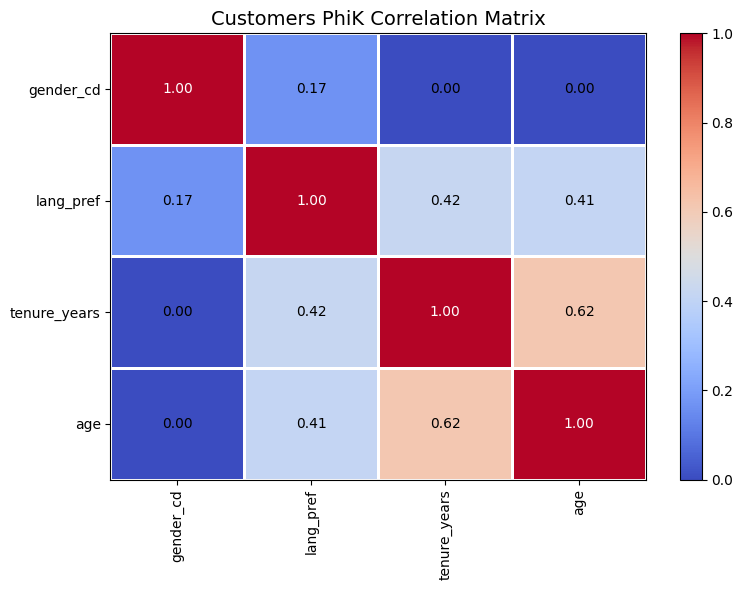

                   age  tenure_years  lang_pref  gender_cd
age           1.000000      0.615764   0.412115   0.000000
tenure_years  0.615764      1.000000   0.421777   0.000000
lang_pref     0.412115      0.421777   1.000000   0.165127
gender_cd     0.000000      0.000000   0.165127   1.000000


In [6]:
# choose columns for phik
relevant_cols = [
    "age",
    "tenure_years",
    "lang_pref",
    "gender_cd"
]

df_subset = syn_customers[relevant_cols].copy()

# fix dtypes for categorical columns
df_subset["lang_pref"] = df_subset["lang_pref"].astype("object")
df_subset["gender_cd"] = df_subset["gender_cd"].astype("object")

# optional: drop rows with missing values
df_subset = df_subset.dropna()

# compute phik correlation
phik_corr = df_subset.phik_matrix(
    interval_cols=["age", "tenure_years"],
    njobs=1
)

plot_correlation_matrix(
    phik_corr.values,
    x_labels=phik_corr.columns,
    y_labels=phik_corr.index,
    figsize=(8, 6),
    color_map="coolwarm",
    vmin=0,
    vmax=1,
    title="Customers PhiK Correlation Matrix"
)

plt.show()

print(phik_corr)


### **Check Customers Distribution**

*The dataset represents a structurally homogeneous customer segment, where variation is primarily driven by demographic and lifecycle attributes rather than organisational or product complexity.*

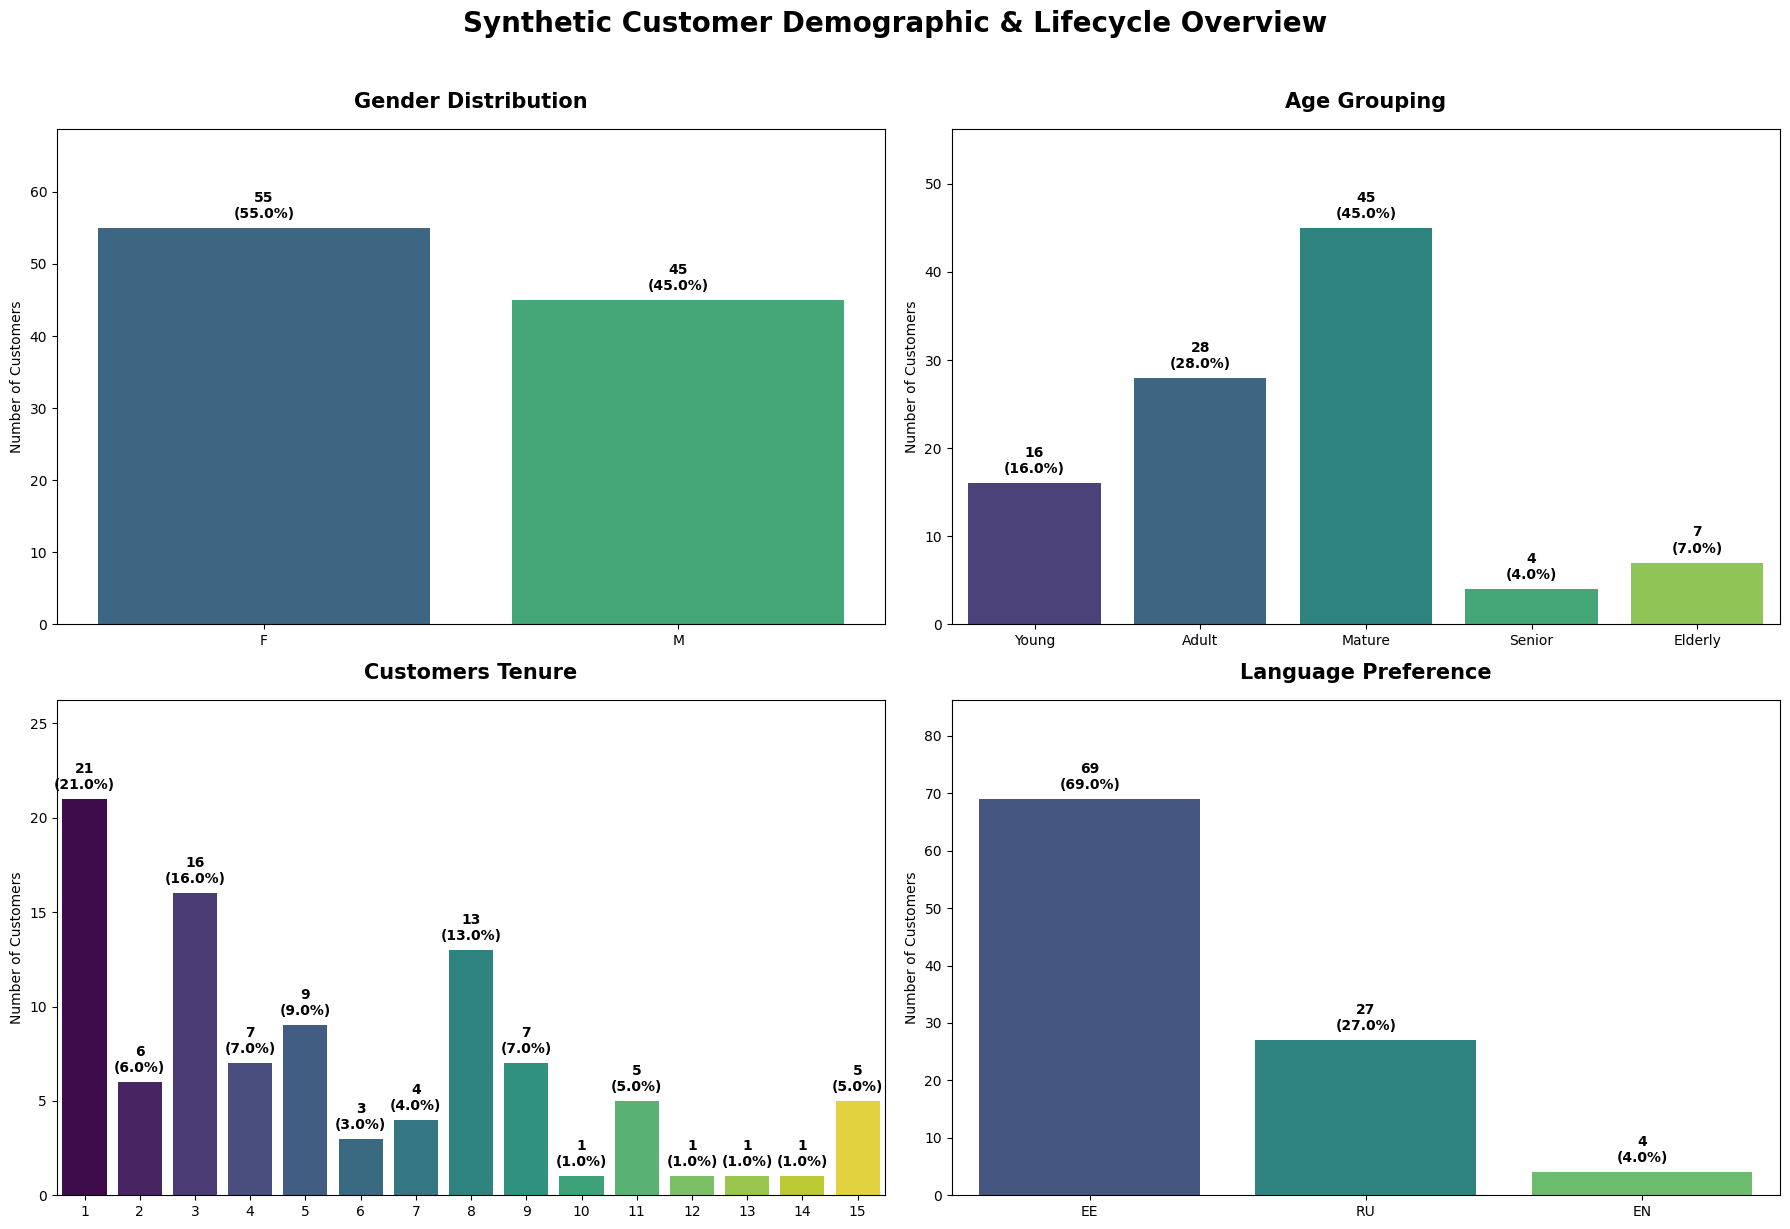

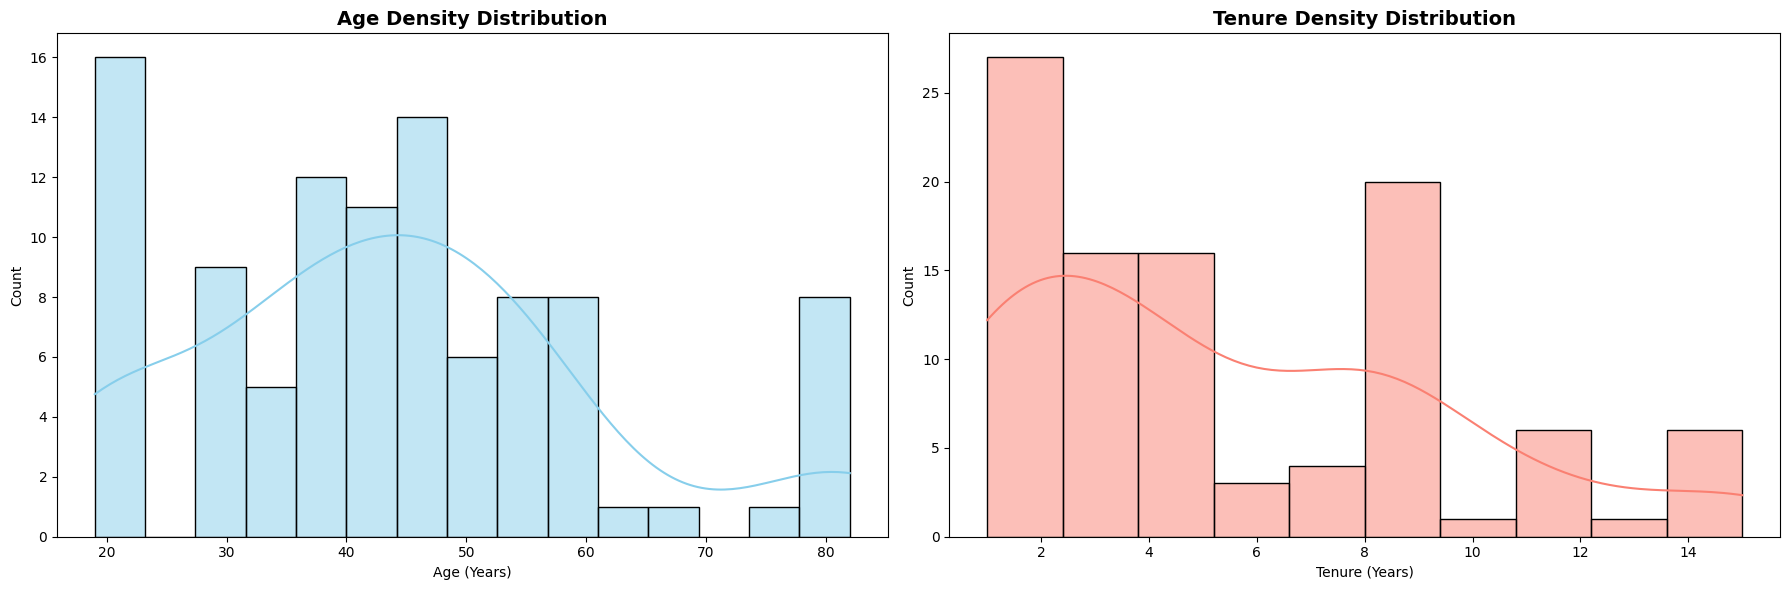

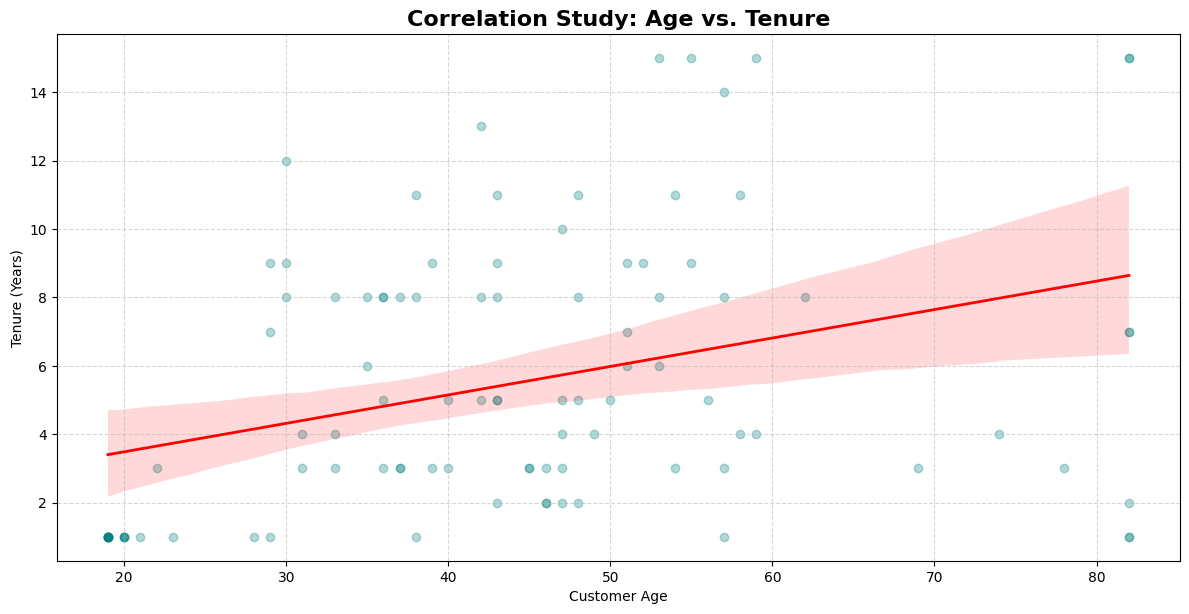

In [7]:
syn_customers_plot = syn_customers.copy()

#grouping age

syn_customers_plot["age_group"] = pd.cut(
    syn_customers_plot["age"],
    bins=[0, 25, 40, 60, 80, 120],
    labels=["Young", "Adult", "Mature", "Senior", "Elderly"]
)

# 1. Customers Distribution (Categorical Data)
# Define columns and their corresponding titles for the dashboard
cols_to_plot = ["gender_cd", "age_group", "tenure_years", "lang_pref"]
titles = ["Gender Distribution", "Age Grouping", "Customers Tenure", "Language Preference"]

# Initialize subplots: 2 rows and 2 columns
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
axes = axes.flatten() # Flatten 2D array to 1D for easier iteration

for i, col in enumerate(cols_to_plot):
    # Calculate frequency and percentage distribution
    counts = syn_customers_plot[col].value_counts(dropna=False).reset_index()
    counts.columns = ["Label", "Count"]
    total = counts["Count"].sum()
    counts = counts.sort_values(by="Count", ascending=False)
    
    # Generate bar plot
    sns.barplot(x="Label", y="Count", data=counts, ax=axes[i], hue="Label", palette="viridis", legend=False)
    
    # Add data labels (Count & Percentage) on top of bars
    for p in axes[i].patches:
        h = p.get_height()
        perc = f"{(100 * h / total):.1f}%"
        axes[i].annotate(f"{int(h):,}\n({perc})", 
                         (p.get_x() + p.get_width() / 2, h),
                         ha="center", va="bottom", 
                         fontsize=10, fontweight="bold", 
                         xytext=(0, 5), textcoords="offset points")
    
    # Subplot styling and labeling
    axes[i].set_title(titles[i], fontsize=15, fontweight='bold', pad=15)
    axes[i].set_ylim(0, counts["Count"].max() * 1.25) # Buffer for annotations
    axes[i].set_xlabel("")
    axes[i].set_ylabel("Number of Customers")

plt.suptitle("Synthetic Customer Demographic & Lifecycle Overview", fontsize=20, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# 2. Customers Distribution (Numerical Data)
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Age distribution with Kernel Density Estimate (KDE)
sns.histplot(syn_customers_plot["age"], bins=15, kde=True, ax=axes[0], color="skyblue")
axes[0].set_title("Age Density Distribution", fontsize=14, fontweight='bold')
axes[0].set_xlabel("Age (Years)")

# Tenure distribution showing skewness
sns.histplot(syn_customers_plot["tenure_years"], bins=10, kde=True, ax=axes[1], color="salmon")
axes[1].set_title("Tenure Density Distribution", fontsize=14, fontweight='bold')
axes[1].set_xlabel("Tenure (Years)")

plt.tight_layout()
plt.show()

# --- 3. CORRELATION ANALYSIS ---
plt.figure(figsize=(12, 6))
# Using regplot to visualize relationship and trendline between Age and Tenure
sns.regplot(x="age", y="tenure_years", data=syn_customers_plot, 
            scatter_kws={"alpha":0.3, "color": "teal"}, 
            line_kws={"color":"red", "lw": 2})

plt.tight_layout()
plt.title("Correlation Study: Age vs. Tenure", fontsize=16, fontweight='bold')
plt.xlabel("Customer Age")
plt.ylabel("Tenure (Years)")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()


### **Plot Intepretation: Customer Demographic & Lifecycle Profile Mature Segment Dominance**

1. **The customer base:** Primarily composed of the "Mature" (45%) and "Adult" (28%) groups. The highest density sits within the 35–50 years old bracket. This indicates a stable, middle-aged demographic with predictable financial behavior.
2. **Tenure Skewness:** The Tenure Distribution is heavily right-skewed. While there is a strong influx of new customers (1–4 years), there is a sharp drop-off in long-term retention. This suggests successful recent acquisition but highlights a need for better long-term loyalty strategies.
3. **Age-Tenure Correlation:** There is a moderate positive correlation. While older customers generally stay longer, the wide dispersion of data points indicates that age is not the sole driver of customer stickiness.

### **1.3.2 — Transaction Synthetic: Explanatory Data Analysis (EDA)**

### **Association/Correlation Matrix in Customers Table**

Gathering Correlation Method:

- Pearson for numeric
- Cramér’s V for categorical
- Correlation ratio for mixed

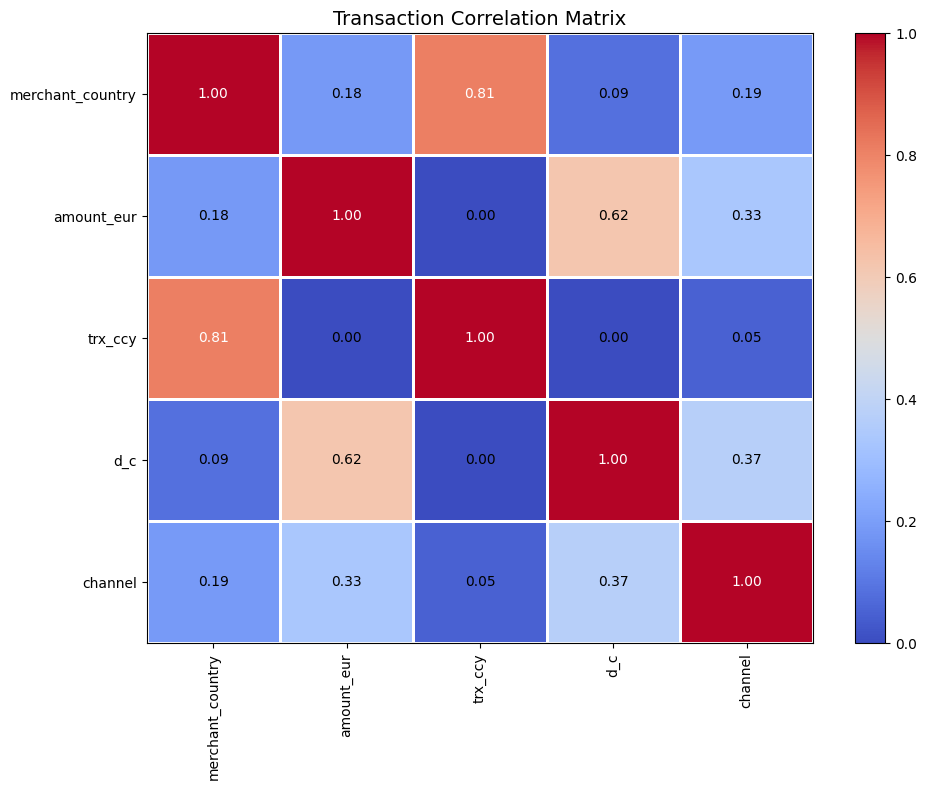

                   channel       d_c   trx_ccy  amount_eur  merchant_country
channel           1.000000  0.372715  0.048187    0.333096          0.188821
d_c               0.372715  1.000000  0.000000    0.617833          0.085735
trx_ccy           0.048187  0.000000  1.000000    0.000000          0.810409
amount_eur        0.333096  0.617833  0.000000    1.000000          0.184714
merchant_country  0.188821  0.085735  0.810409    0.184714          1.000000


In [8]:
# choose columns for phik
relevant_cols = [
    "channel", 
    "d_c", 
    "trx_ccy", 
    "amount_eur",
    "merchant_country"
]

df_subset = syn_transactions[relevant_cols].sample(
    n=min(20000, len(syn_transactions)),
    random_state=42
).copy()

# force categorical/string columns to plain object
cat_cols = ["channel", "d_c", "trx_ccy", "merchant_country"]
for col in cat_cols:
    df_subset[col] = df_subset[col].astype("object")

# optional: drop rows with missing values
df_subset = df_subset.dropna()

# make sure numeric column is numeric
df_subset["amount_eur"] = pd.to_numeric(df_subset["amount_eur"], errors="coerce")

# define interval columns manually
interval_cols = ["amount_eur"]

# disable multiprocessing with njobs=1
phik_corr = df_subset.phik_matrix(interval_cols=interval_cols, njobs=1)


plot_correlation_matrix(
    phik_corr.values,
    x_labels=phik_corr.columns,
    y_labels=phik_corr.index,
    figsize=(10, 8),
    vmin=0,
    vmax=1,
    color_map="coolwarm",
    title="Transaction Correlation Matrix"
)

plt.show()

print(phik_corr)


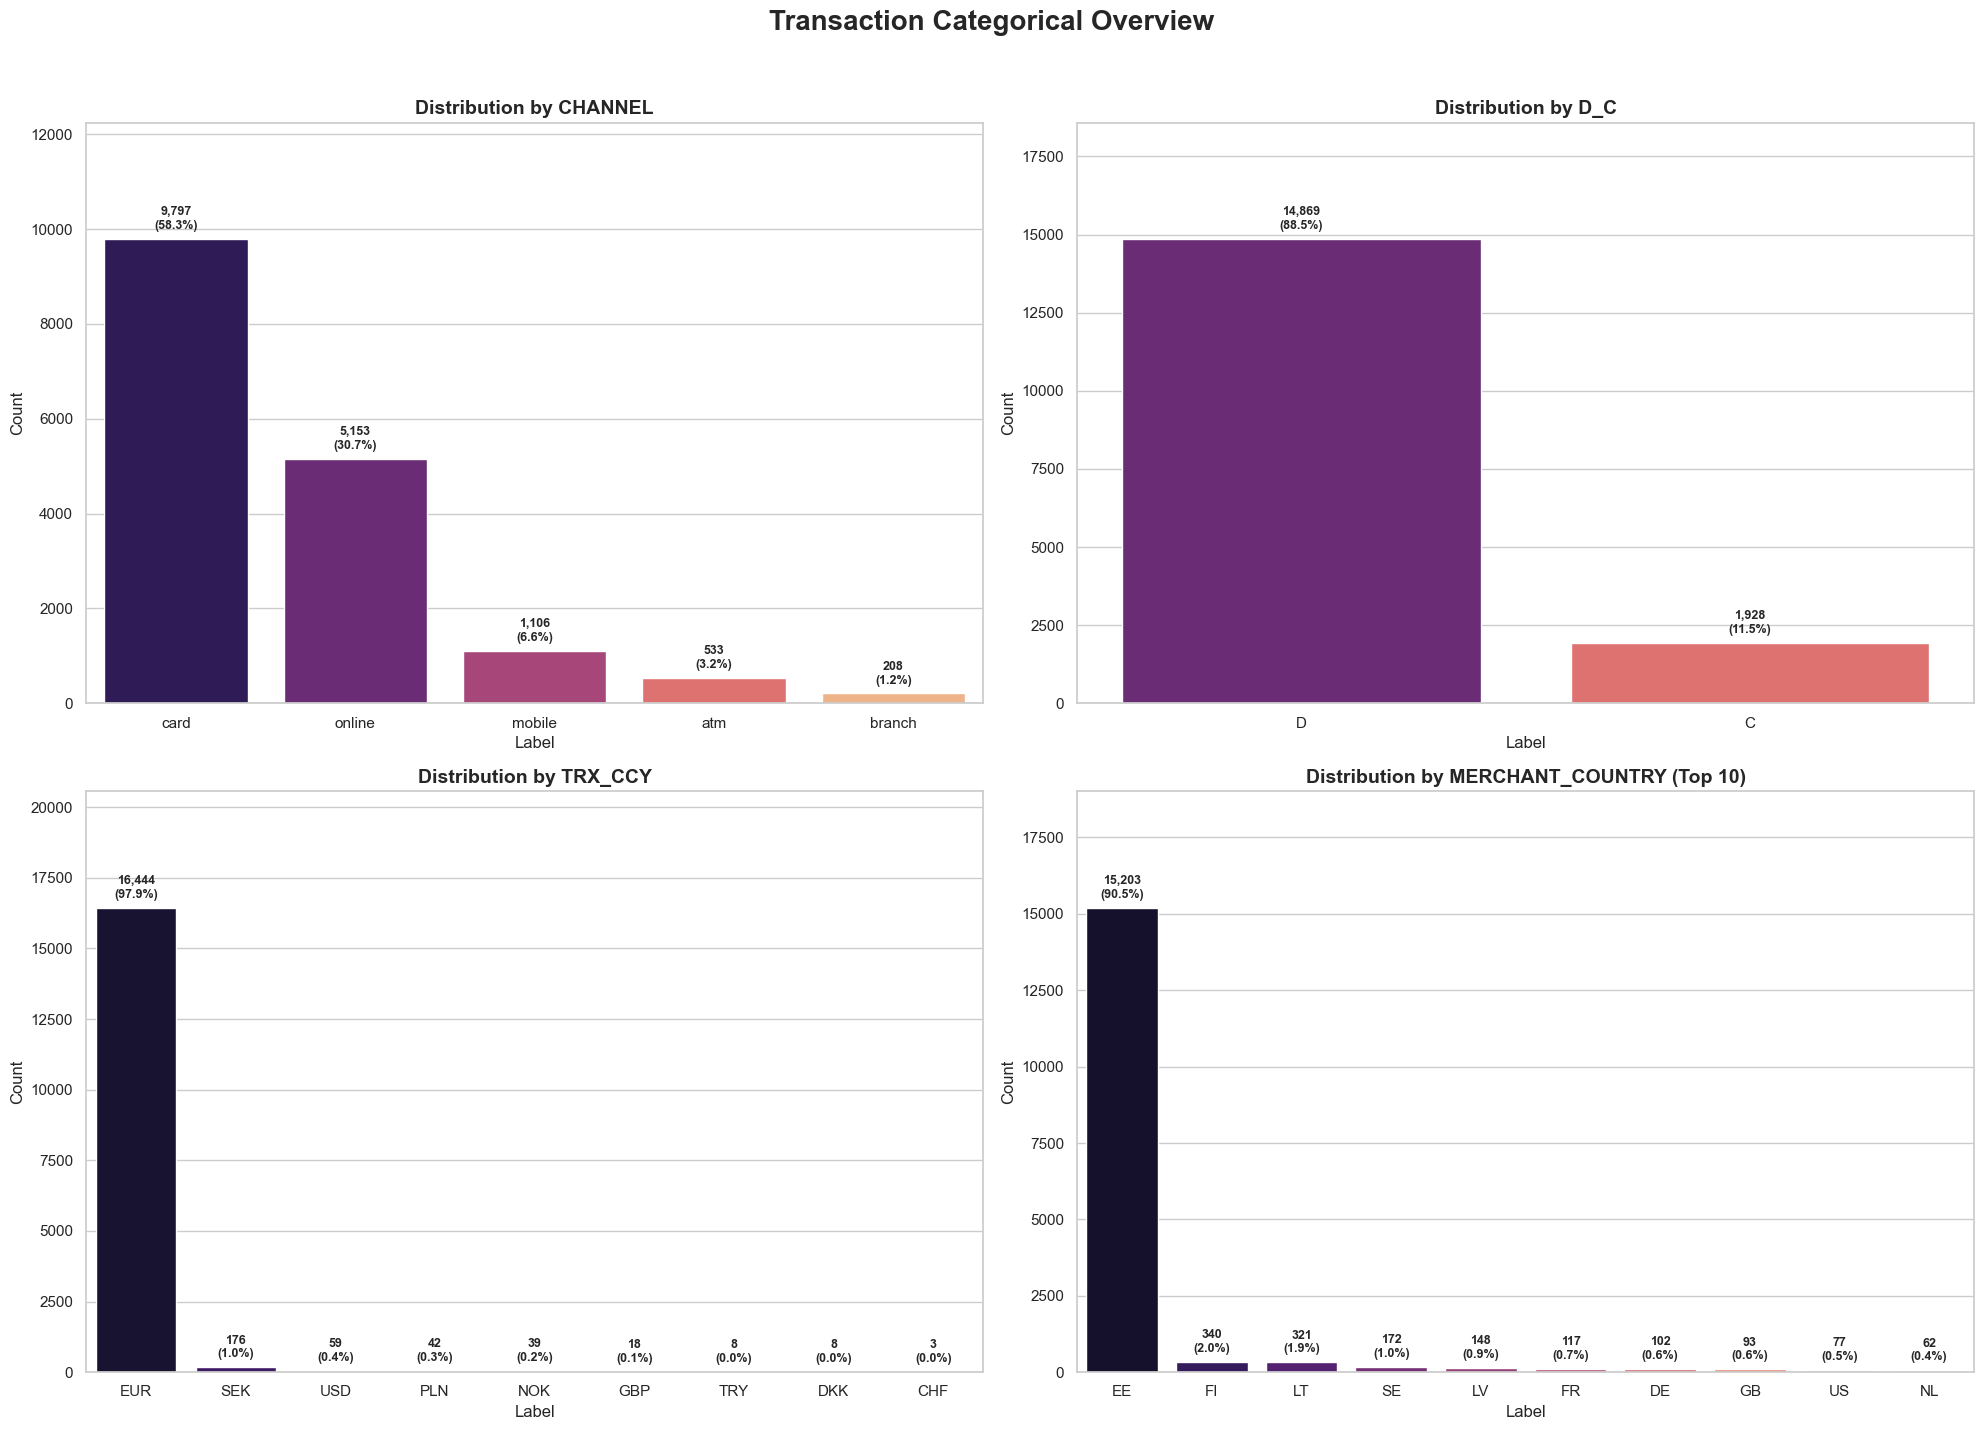

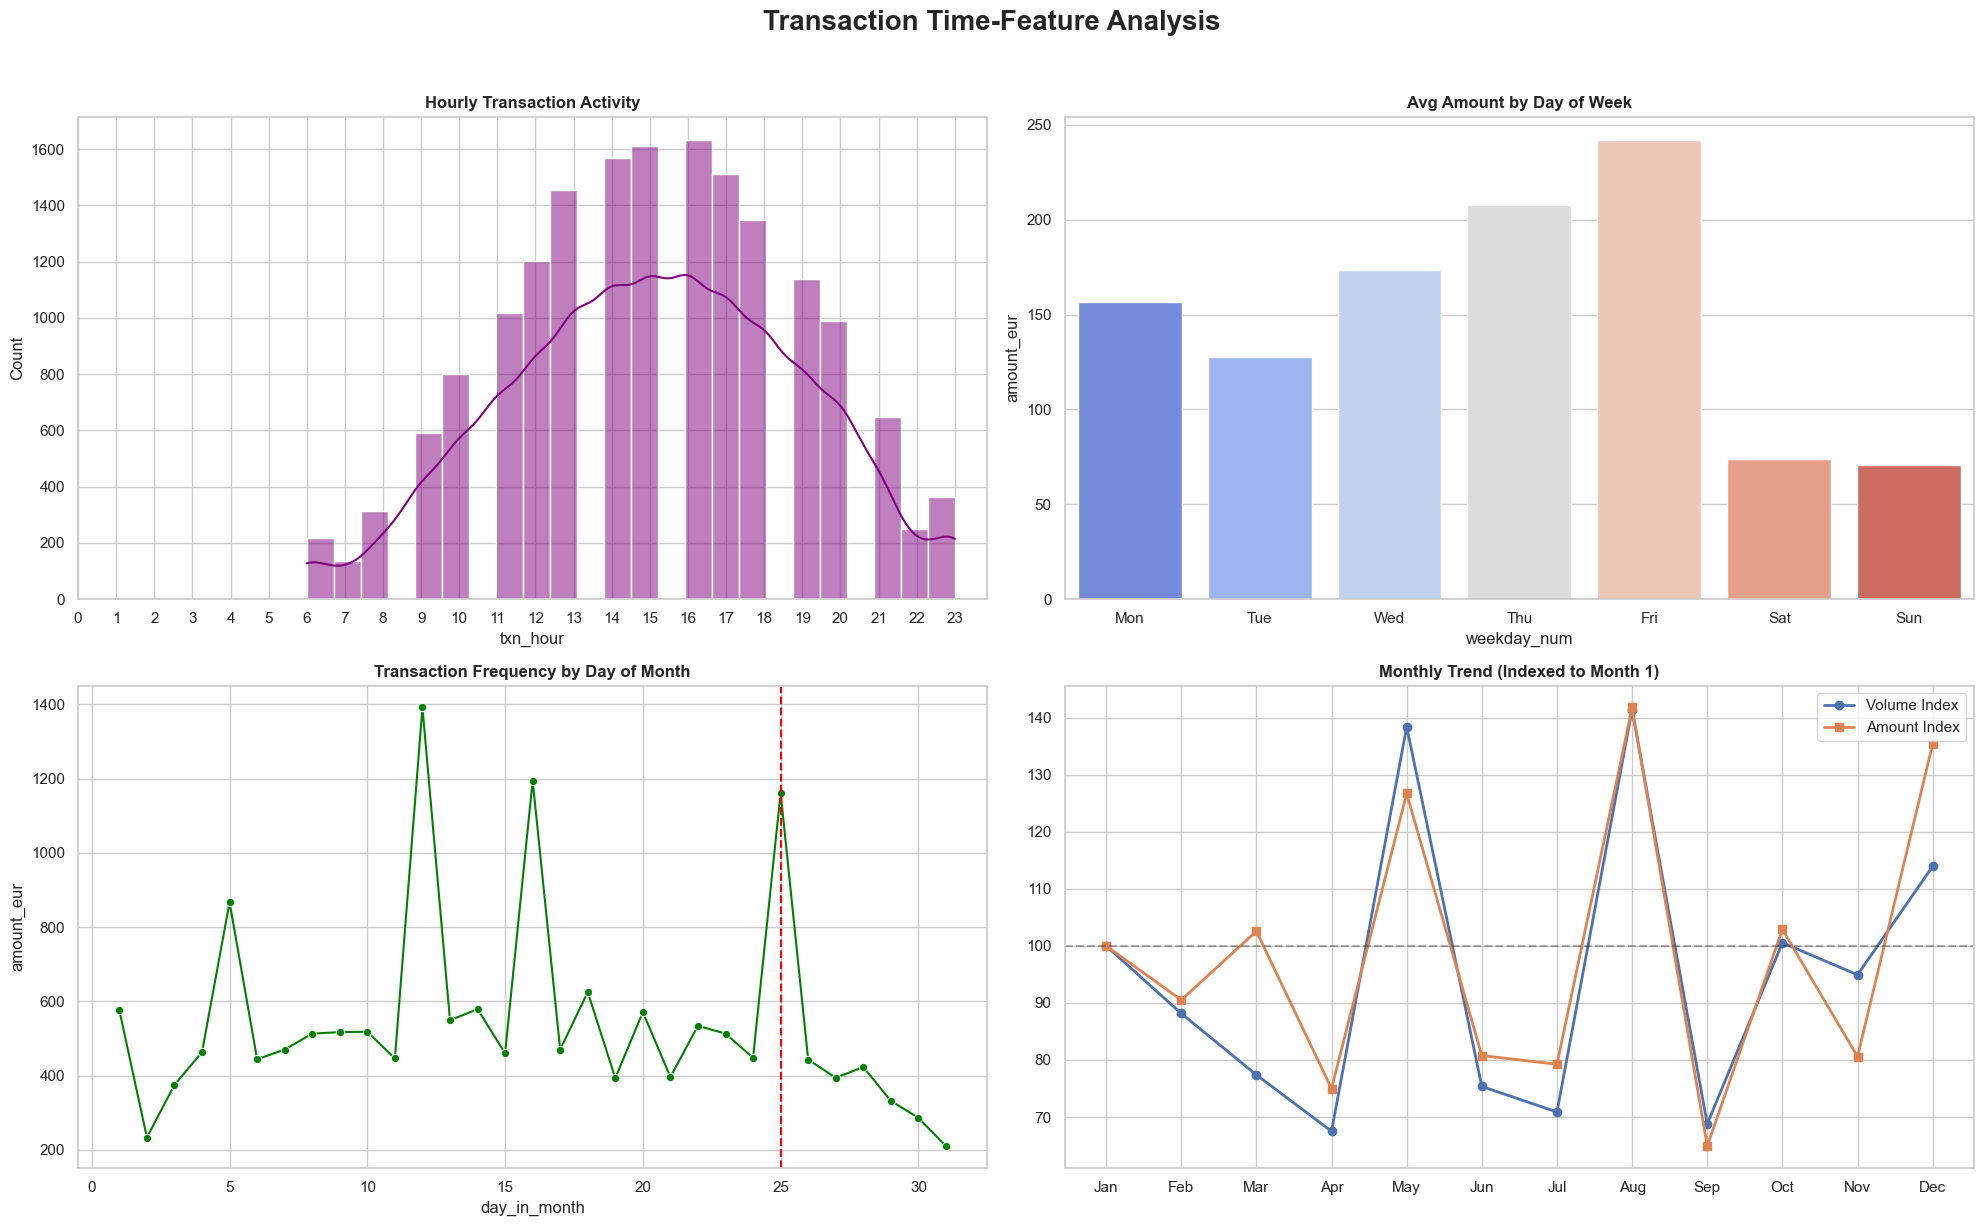

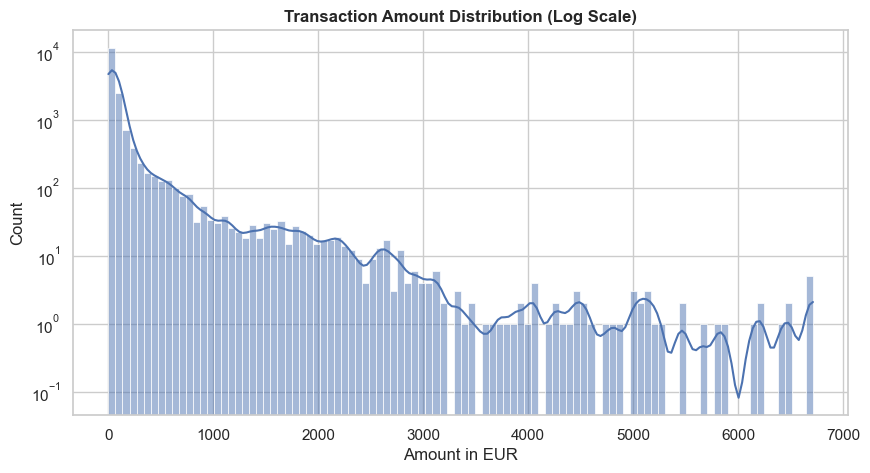

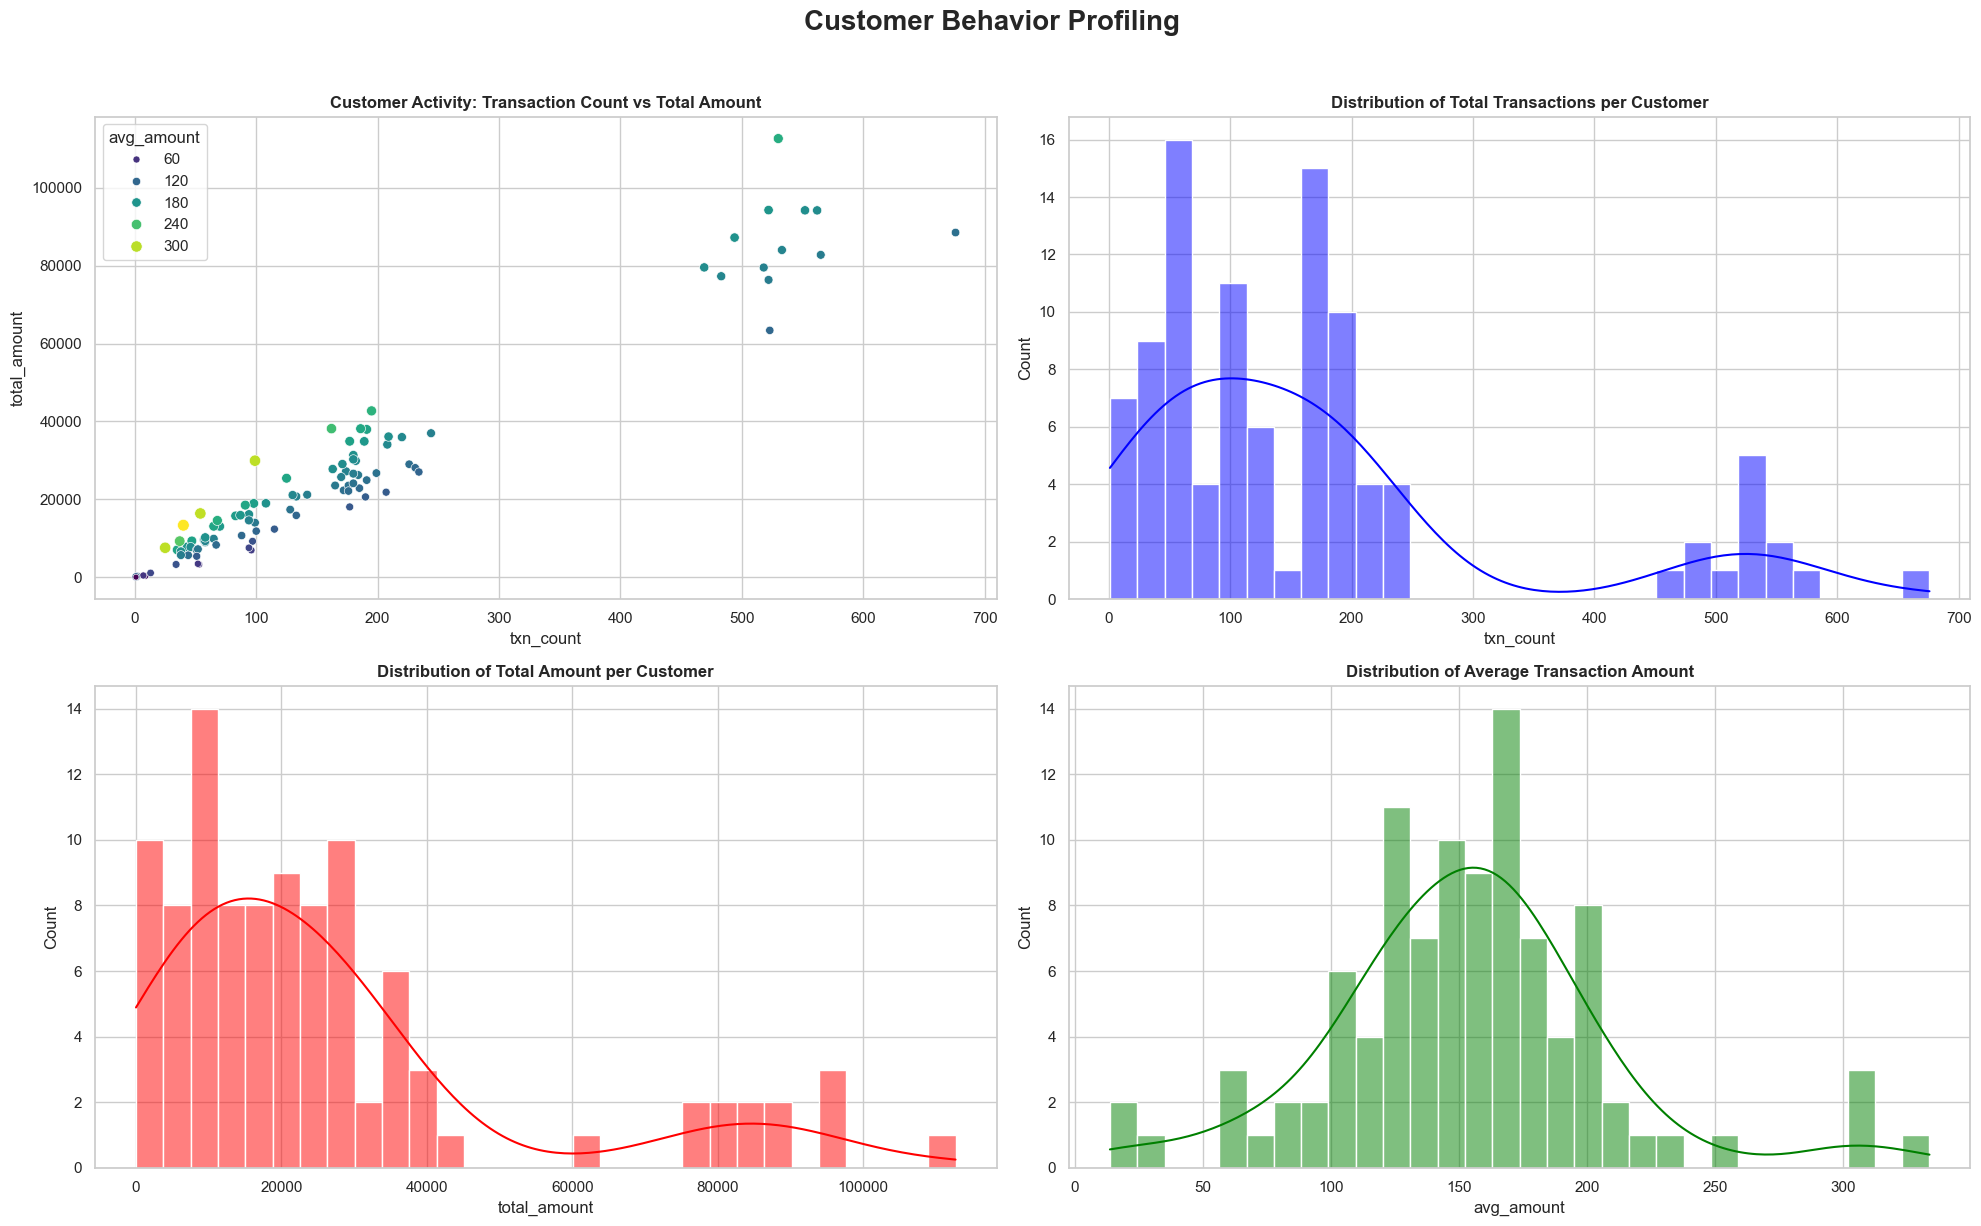

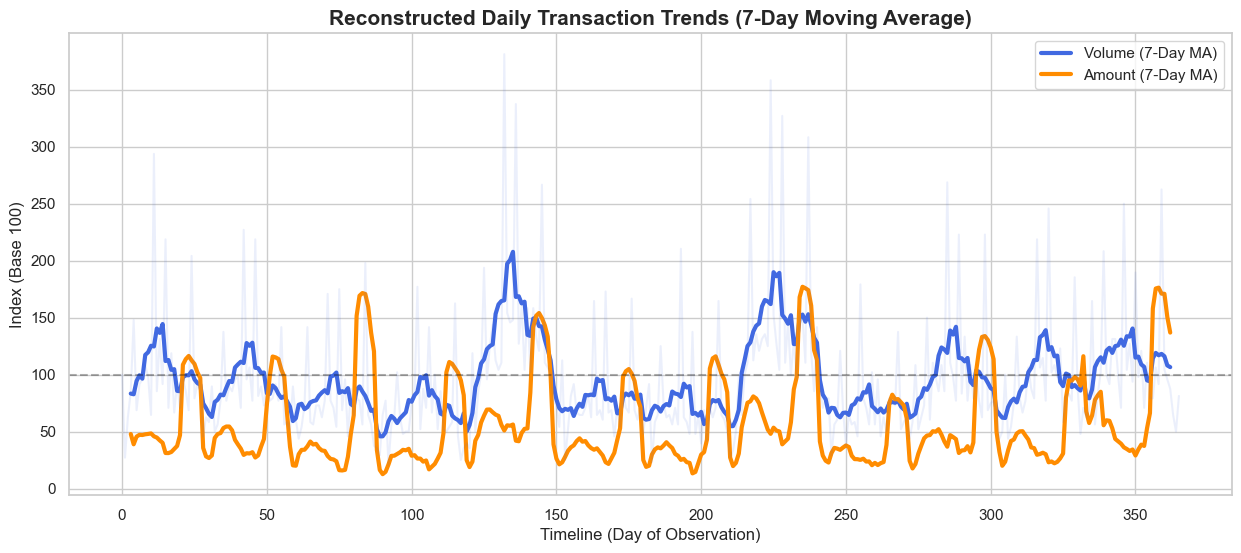

In [9]:

# Set global style
sns.set_theme(style="whitegrid")
syn_transactions_plot = syn_transactions.copy()

# 1. PRE-CALCULATION FOR TRENDS
# Aggregate by month since we don't have daily 'date'
monthly_txn = (
    syn_transactions_plot
    .groupby("txn_month", as_index=False)
    .agg(
        total_amount=("amount_eur", "sum"),
        transaction_count=("amount_eur", "count")
    )
)

# Calculate Base-100 Index (Month 1 = 100)
monthly_txn["txn_count_idx"] = (monthly_txn["transaction_count"] / monthly_txn["transaction_count"].iloc[0]) * 100
monthly_txn["total_amount_idx"] = (monthly_txn["total_amount"] / monthly_txn["total_amount"].iloc[0]) * 100

# 2. CATEGORICAL DISTRIBUTION DASHBOARD
cat_cols = ["channel", "d_c", "trx_ccy", "merchant_country"]
fig, axes = plt.subplots(2, 2, figsize=(20, 14))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    counts = syn_transactions_plot[col].value_counts(dropna=False).reset_index()
    counts.columns = ["Label", "Count"]
    total = counts["Count"].sum()
    
    if counts.shape[0] > 10:
        counts = counts.head(10)
        title_suffix = " (Top 10)"
    else:
        title_suffix = ""

    sns.barplot(x="Label", y="Count", data=counts, ax=axes[i], hue="Label", palette="magma", legend=False)
    
    for p in axes[i].patches:
        h = p.get_height()
        perc = f"{(100 * h / total):.1f}%"
        axes[i].annotate(f"{int(h):,}\n({perc})", (p.get_x() + p.get_width() / 2, h),
                         ha="center", va="bottom", fontsize=9, fontweight="bold", xytext=(0, 5), textcoords="offset points")
    
    axes[i].set_title(f"Distribution by {col.upper()}{title_suffix}", fontsize=14, fontweight='bold')
    axes[i].set_ylim(0, counts["Count"].max() * 1.25)

plt.suptitle("Transaction Categorical Overview", fontsize=20, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# 3. CYCLICAL PATTERNS (Time Features)
fig, axes = plt.subplots(2, 2, figsize=(20, 12))
axes = axes.flatten()

# A. Hourly Activity
sns.histplot(syn_transactions_plot["txn_hour"], bins=24, kde=True, ax=axes[0], color="purple")
axes[0].set_title("Hourly Transaction Activity", fontweight='bold')
axes[0].set_xticks(range(0, 24))

# B. Weekday Pattern
weekday_order = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
sns.barplot(x="weekday_num", y="amount_eur", data=syn_transactions_plot, ax=axes[1], palette="coolwarm", errorbar=None)
axes[1].set_title("Avg Amount by Day of Week", fontweight='bold')
axes[1].set_xticks(range(7))
axes[1].set_xticklabels(weekday_order)

# C. Day of Month Pattern (Payday Check)
day_counts = syn_transactions_plot.groupby("day_in_month")["amount_eur"].count().reset_index()
sns.lineplot(x="day_in_month", y="amount_eur", data=day_counts, ax=axes[2], color="green", marker='o')
axes[2].axvline(25, color='red', linestyle='--', label='Payday')
axes[2].set_title("Transaction Frequency by Day of Month", fontweight='bold')

# D. Monthly Trend (Index Base 100)
axes[3].plot(monthly_txn["txn_month"], monthly_txn["txn_count_idx"], marker='o', label="Volume Index", linewidth=2)
axes[3].plot(monthly_txn["txn_month"], monthly_txn["total_amount_idx"], marker='s', label="Amount Index", linewidth=2)
axes[3].axhline(100, color="black", linestyle="--", alpha=0.3)
axes[3].set_title("Monthly Trend (Indexed to Month 1)", fontweight='bold')
axes[3].set_xticks(range(1, 13))
axes[3].set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'])
axes[3].legend()

plt.suptitle("Transaction Time-Feature Analysis", fontsize=20, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# 4. LOG DISTRIBUTION (Amount)
plt.figure(figsize=(10, 5))
sns.histplot(syn_transactions_plot["amount_eur"], bins=100, kde=True)
plt.yscale("log")
plt.title("Transaction Amount Distribution (Log Scale)", fontweight="bold")
plt.xlabel("Amount in EUR")
plt.show()

# 5. CUSTOMER ACTIVITY & PROFILING
# Create customer-level summary
customer_summary = (
    syn_transactions_plot
    .groupby("pseudo_customer_key")
    .agg(
        txn_count=("amount_eur", "count"),
        total_amount=("amount_eur", "sum"),
        avg_amount=("amount_eur", "mean")
    )
    .reset_index()
)

fig, axes = plt.subplots(2, 2, figsize=(20, 12))
axes = axes.flatten()

# A. Scatter Plot: Activity vs Value
sns.scatterplot(data=customer_summary, x="txn_count", y="total_amount", 
                size="avg_amount", hue="avg_amount", palette="viridis", ax=axes[0])
axes[0].set_title("Customer Activity: Transaction Count vs Total Amount", fontweight="bold")

# B. Histogram: Total Transaction Count
sns.histplot(customer_summary["txn_count"], bins=30, kde=True, color="blue", ax=axes[1])
axes[1].set_title("Distribution of Total Transactions per Customer", fontweight="bold")

# C. Histogram: Total Amount Profile
sns.histplot(customer_summary["total_amount"], bins=30, kde=True, color="red", ax=axes[2])
axes[2].set_title("Distribution of Total Amount per Customer", fontweight="bold")

# D. Histogram: Average Amount Profile
sns.histplot(customer_summary["avg_amount"], bins=30, kde=True, color="green", ax=axes[3])
axes[3].set_title("Distribution of Average Transaction Amount", fontweight="bold")

plt.suptitle("Customer Behavior Profiling", fontsize=20, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# 6. PSEUDO-DAILY TREND & MOVING AVERAGE
# Hack: Reconstructing a "Fake Date" for the timeline visuals since real 'date' is gone
# We combine txn_month and day_in_month into a single timeline index
daily_agg = (
    syn_transactions_plot
    .groupby(["txn_month", "day_in_month"])
    .agg(total_amount=("amount_eur", "sum"),
         txn_count=("amount_eur", "count"))
    .reset_index()
    .sort_values(["txn_month", "day_in_month"])
)

# Create index based on Day 1
daily_agg["txn_count_idx"] = (daily_agg["txn_count"] / daily_agg["txn_count"].iloc[0]) * 100
daily_agg["total_amount_idx"] = (daily_agg["total_amount"] / daily_agg["total_amount"].iloc[0]) * 100

# Apply 7-Day Moving Average to the reconstructed timeline
daily_agg["count_smooth"] = daily_agg["txn_count_idx"].rolling(window=7, center=True).mean()
daily_agg["amount_smooth"] = daily_agg["total_amount_idx"].rolling(window=7, center=True).mean()

plt.figure(figsize=(15, 6))
plt.plot(range(len(daily_agg)), daily_agg["count_smooth"], label="Volume (7-Day MA)", linewidth=3, color="royalblue")
plt.plot(range(len(daily_agg)), daily_agg["amount_smooth"], label="Amount (7-Day MA)", linewidth=3, color="darkorange")
plt.plot(range(len(daily_agg)), daily_agg["txn_count_idx"], alpha=0.1, color="royalblue") # Original volatility

plt.axhline(100, color="black", linestyle="--", alpha=0.3)
plt.title("Reconstructed Daily Transaction Trends (7-Day Moving Average)", fontsize=15, fontweight='bold')
plt.xlabel("Timeline (Day of Observation)")
plt.ylabel("Index (Base 100)")
plt.legend()
plt.show()

### **Transactional Characteristics**

1. **Digital-First Behavior**
Card (57.8%) and Online (31.1%) channels dominate the transaction landscape.  
ATM and Branch usage is minimal, confirming a highly digital customer base.

2. **Debit-Centric Activity**
Transactions are overwhelmingly **Debit (88.4%)**, indicating that accounts are primarily used for daily spending and payments rather than receiving large credits or internal transfers.

3. **Currency & Geography**
Activity is strictly local, centered in **Estonia (EE)** and conducted in **EUR (98.1%)**.  
Cross-border exposure is minimal, but any sudden deviation from this pattern should be monitored as a potential red flag.

### **Value Distribution & Anomaly Identification**
1. **Power Law distribution**: The log-scale histogram shows: most transactions are small (retail-level).
2. **Whale transactions:** The “long tail” contains rare, high-value  (> 3,000 EUR), which are the primary targets for anomaly detection.

### **Time-Series & Seasonal Behavioral Patterns**

1.  **Payday & Cyclical Spikes:** The *Daily Trends* plots show sharp, consistent spikes around the end of the month (approx. the 25th), strongly correlating with standard **payday cycles**. In the friday show the highest volume, likely due to weekend preparation and suring the weekend, it shows a notable drop in activity. 
   
2.  **Stable Rhythm:** The 7-day moving average reveals a stable, cyclical rhythm.  
The strong correlation between transaction volume (blue) and transaction amount (orange) suggests that spending is driven by a broad user base rather than a few isolated large transfers.

4.  **Volatility Awareness:** Peak activity occurs during business hours (12:00 PM – 5:00 PM). Significant activity between 00:00 and 06:00 is rare, making high-value night-time transactions a high-priority risk signal.


### **Behavioral Profiling & Anomaly Spotting**

1.  **Linear Activity Cluster:** The scatter plot shows a strong linear relationship.  
Most customers cluster in the **Low Frequency – Low Value** segment.

2.  **Watchlist Identification (Outlier Analysis):** Outliers in the top-right quadrant represent **High-Frequency, High-Value** users.  
In a 1LoD/2LoD monitoring context, these profiles should undergo **enhanced due diligence**, as they carry the highest potential for money laundering or system abuse.


---
# **SECTION 2 — Dataset Mapping: TO-BE Three Lines Overview**

### **Mapping of Synthetic Datasets Across the Three Lines of Model (3LM)**

| Line of Defense | Function | Dataset / Artefact | Key Fields | Share Level | Purpose |
|---|---|---|---|---|---|
| 1LoD IT | Source data custodian | `customers`, `transactions_2024` | Full original fields incl. PII | IT only | Original source reference; retained for formal/legal use only |
| 1LoD DataOps | SDG pipeline + monitoring | `synthetic_customers`, `synthetic_transactions`, `syn_customer_day` | Synthetic and engineered fields — no PII | **Direct access to all lines** | Golden Source — enables self-serve analytics across all lines |
| 1LoD Business Ops | Monitoring & triage | `tobe_ops_log`, `tobe_ops_case_log`,`tobe_ops_log`, `tobe_ops_case_log`,`tobe_transactions_case_linked`, `tobe_transactions_case_view`, `tobe_customer_day_registry`, `tobe_ops_reviewed`, `dashboard_summary `| suspiciousness_label, ops_disposition, ops_rules, case_id | Shared | Operational monitoring, escalation, and case handling |
| 2LoD Risk | Oversight | `tobe_lod2_risk_dashboard` | escalation_rate, amplification_ratio, stability metrics | Shared | Systemic risk monitoring and trend oversight |
| 2LoD Compliance | SOP adherence | `tobe_compliance_log` | SOP deviation, documentation flag, compliance status | Shared | Procedural and regulatory oversight |
| 3LoD Audit | Independent assurance | `tobe_audit_review_log`, `tobe_audit_workpaper`, `tobe_audit_observations` | control effectiveness, reconstruction flag, audit conclusion | Shared | Independent assurance and audit observations |
| IT (exception) | Real data custodian | Real transactions + customers | Full PII | **Formal request only** | Legal evidence and formal investigation only |

In [10]:
# TO-BE Cross-Line Data Availability Matrix

tobe_availability = {
    'Line'                   : ['1LoD IT', '1LoD DataOps', '1LoD Business Ops', '2LoD Risk', '2LoD Compliance', '3LoD Audit'],
    'synthetic_customers'    : ['PRODUCES', 'PRODUCES', 'FULL ACCESS', 'FULL ACCESS', 'FULL ACCESS', 'FULL ACCESS'],
    'synthetic_transactions' : ['PRODUCES', 'PRODUCES', 'FULL ACCESS', 'FULL ACCESS', 'FULL ACCESS', 'FULL ACCESS'],
    'synthetic_customer_day' : ['PRODUCES', 'PRODUCES', 'FULL ACCESS', 'FULL ACCESS', 'FULL ACCESS', 'FULL ACCESS'],
    'tobe_ops_case_log'      : ['NO ACCESS', 'NO ACCESS', 'PRODUCES', 'RECEIVES', 'RECEIVES', 'RECEIVES'],
    'Real Data (PII)'        : ['FULL ACCESS', 'FULL ACCESS', 'FORMAL REQUEST', 'NO ACCESS', 'NO ACCESS', 'FORMAL REQUEST'],
    'IT Request Required'    : ['N/A', 'N/A', 'NO', 'NO', 'NO', 'Only legal evidence'],
}

tobe_avail_df = pd.DataFrame(tobe_availability).set_index('Line')
print("\033[1m----- TO-BE CROSS-LINE DATA AVAILABILITY MATRIX -----\033[0m")
print('All lines access synthetic data directly — zero IT request for analytics')
display(tobe_avail_df)


----- TO-BE CROSS-LINE DATA AVAILABILITY MATRIX -----
All lines access synthetic data directly — zero IT request for analytics


,synthetic_customers,synthetic_transactions,synthetic_customer_day,tobe_ops_case_log,Real Data (PII),IT Request Required
Line,,,,,,
1LoD IT,PRODUCES,PRODUCES,PRODUCES,NO ACCESS,FULL ACCESS,N/A
1LoD DataOps,PRODUCES,PRODUCES,PRODUCES,NO ACCESS,FULL ACCESS,N/A
1LoD Business Ops,FULL ACCESS,FULL ACCESS,FULL ACCESS,PRODUCES,FORMAL REQUEST,NO
2LoD Risk,FULL ACCESS,FULL ACCESS,FULL ACCESS,RECEIVES,NO ACCESS,NO
2LoD Compliance,FULL ACCESS,FULL ACCESS,FULL ACCESS,RECEIVES,NO ACCESS,NO
3LoD Audit,FULL ACCESS,FULL ACCESS,FULL ACCESS,RECEIVES,FORMAL REQUEST,Only legal evidence


---
# **SECTION 3 — THE FIRST LINES OF DEFENCE (IT, DATA OPERATION, BUSINESS OPERATION) (1LoD)**
---
---


# **S3 — 1.1 1LoD — IT Department — Raw Data Custodian**

***Output:** `customers` and `transactions`*


*Database owner (Core Banking View)*

### **RAW Data IT — Baseline**

| Component       | Description                                                           |
| --------------- | --------------------------------------------------------------------- |
| **Role**        | IT (Technical data owner)                                             |
| **Input**       | Core banking system                                                   |
| **Output**      | Raw tables (`transactions`, `customers`) |
| **Granularity** | Event-level (transaction-level)                                       |
| **Fields**      | All fields including IBAN, timestamps, PII                            |
| **Processing**  | None                                                                  |
| **Purpose**     | Source of truth (SoT)                                                 |


<div style="background-color: #fff9e6; border-left: 6px solid #ffc107; padding: 18px; border-radius: 8px; font-family: 'Segoe UI', Roboto, sans-serif; display: flex; align-items: flex-start; box-shadow: 0 1px 3px rgba(0,0,0,0.05);">
    <span style="font-size: 1.4em; margin-right: 12px; line-height: 1;">🛡️</span>
    <div>
        <strong style="color: #856404; font-size: 1.05em; display: block; margin-bottom: 4px; letter-spacing: 0.3px;">TRUTH SOURCE ACKNOWLEDGMENT</strong>
        <p style="margin: 0; color: #533f03; line-height: 1.5;">
            The underlying data source is established as the <b>primary reference</b>—serving as the most accurate and authentic foundation for all integrated systems and downstream analytics.
        </p>
    </div>
</div>

---
# **S3 — 1.2 — 1LoD: Data Operation — SDG Monitoring Pipeline**
***Input:** `synthetic_customer` and `synthetic_transaction` — The Golden Source*.


## **1LoD — Data Operations Department**

| Component       | Description                                                                 |
|-----------------|-----------------------------------------------------------------------------|
| **Role**        | Data Operations (Technical Enabler — Data Preparation & Feature Engineering) |
| **Input**       | `synthetic_customers` + `synthetic_transactions` (from SDG pipeline)        |
| **Output**      | `syn_customer_day` — shared across all three lines                           |
| **Granularity** | Customer-day aggregation                                                     |
| **Fields**      | Engineered features (no PII; includes pseudo_customer_key, behavioral indicators, and temporal features) |
| **Processing**  | Feature engineering (baseline calculation, ratio metrics, severity classification, rule-based flags) |
| **Purpose**     | Provide a privacy-preserving, shareable analytical dataset                   |
| **Key Difference** | No PII exposure — all lines can access data directly without IT request       |

## **S3 — 1.2.1 Input Dataset**

*In AS-IS: Real data with PII (client_id, IBANs, exact dates)*

In TO-BE: Synthetic data — same structure, no PII, pseudo_customer_key as identifier and for calculating deviation ratio, all parameters are similar to AS-IS process.

1. baseline_min_periods =5
2. velocity and value ratio:

| Metric | Normal | Elevated | Significant |
|---|---|---|---|
| **`ratio_velocity`** | ≤ 1.5 | 1.5 – 2.0 | > 2.0 |
| **`ratio_value`** | ≤ 1.5 | 1.5 – 2.0 | > 2.0 |

In [11]:
print("\033[1m----- TO-BE DATA OPERATIONS INPUT -----\033[0m")

print(f'synthetic_customers    : {syn_customers.shape}')
print(f'synthetic_transactions : {syn_transactions.shape}')
print()
print('syntheticcustomers columns:')
print(syn_customers.columns.tolist())
print()
print('synthetic_transactions columns:')
print(syn_transactions.columns.tolist())


----- TO-BE DATA OPERATIONS INPUT -----
synthetic_customers    : (100, 9)
synthetic_transactions : (16797, 16)

syntheticcustomers columns:
['pseudo_customer_key', 'type_cd', 'segment', 'group_head_flg', 'gender_cd', 'lang_pref', 'age', 'tenure_years', 'postal_code']

synthetic_transactions columns:
['txn_id', 'pseudo_customer_key', 'channel', 'd_c', 'trx_ccy', 'amount_eur', 'amount_orig', 'mcc', 'merchant_country', 'txn_year', 'txn_month', 'day_in_month', 'weekday_num', 'quarter', 'is_month_end', 'txn_hour']


## **S3 — 1.2.2 Data Process:**

```mermaid
flowchart LR
    A["Synthetic Transactions\n(from SDG Pipeline)"]
        --> B[Aggregate Daily Transactions\n• sum amounts\n• count transactions\n• build day-level features]

    B --> C["Compute Expanding Baselines\n(min_periods = 5)\n• baseline_mean\n• baseline_std\n• baseline_median"]

    C --> D["Compute Volatility\n• Coefficient of Variation (CV)\n= std / mean\nper customer daily series"]

    D --> E[Calculate Ratio Metrics\n• ratio_velocity\n• ratio_value\nCompare current value vs baseline]

    E --> F["Compute Deviation Metrics\n• deviation = ratio - 1\n• anomaly signal base"]

    F --> G{{"The Golden Source\nsynthetic_customer_day\nShared to ALL Lines"}}
```


**Data Preprocessing Pipeline (identical logic to AS-IS):**
1. Reconstruct date from 'txn_year' + 'txn_month' + 'day_in_month' + 'weekday_num' + 'quarter'+ 'is_month_end'
2. Aggregate daily transactions per pseudo_customer_key
3. Enrich with synthetic demographics (self-serve join — no IT needed)
4. Compute expanding baselines (min_periods=5)
5. Calculate ratio_velocity and ratio_value
6. Apply deviation_group → severity labels
7. Apply auto_red_flag


<div style="background-color: #f5f3ff; border-left: 6px solid #7c3aed; padding: 18px; border-radius: 8px; font-family: 'Segoe UI', Roboto, sans-serif; display: flex; align-items: flex-start; box-shadow: 0 1px 3px rgba(0,0,0,0.05);">
    <span style="font-size: 1.4em; margin-right: 12px; line-height: 1;">⚡</span>
    <div>
        <strong style="color: #5b21b6; font-size: 1.05em; display: block; margin-bottom: 4px; letter-spacing: 0.3px;">OPERATIONAL EFFICIENCY</strong>
        <p style="margin: 0; color: #4c1d95; line-height: 1.5;">
            <b>Key difference from AS-IS:</b> Because input is <code style="background: #ede9fe; padding: 2px 4px; border-radius: 4px;">synthetic</code> (Zero PII), the output is distributed to <b>all lines of defense simultaneously</b>—eliminating the need for IT requests and manual approvals.
        </p>
    </div>
</div>

In [12]:
# reconstruct date from txn_year + txn_month + day_in_month
# since the original date field is decomposed during preprocessing,
# it is deterministically reconstructed here for TO-BE analysis.

# avoid modifying the original synthetic dataframe
syn_trx = syn_transactions.copy()

# Reconstruct base date from txn_month + day_in_month
syn_trx['date'] = pd.to_datetime(
    syn_trx['txn_year'].astype(int).astype(str).str.zfill(4) + '-' +
    syn_trx['txn_month'].astype(int).astype(str).str.zfill(2) + '-' +
    syn_trx['day_in_month'].astype(int).astype(str).str.zfill(2),
    errors='coerce'
)

# enforce consistency by recalculating dependent temporal features
syn_trx['weekday_num'] = syn_trx['date'].dt.weekday
syn_trx['quarter'] = syn_trx['date'].dt.quarter
syn_trx['is_month_end'] = syn_trx['date'].dt.is_month_end.astype(int)

# validation
print(f"Date range: {syn_trx['date'].min()} -> {syn_trx['date'].max()}")
print(f"NaT count : {syn_trx['date'].isna().sum()}")

Date range: 2024-01-01 00:00:00 -> 2024-12-31 00:00:00
NaT count : 0


In [13]:
print(f'\n\033[1m----- SANITY CHECK BEFORE AGGREGATE PROCESS -----\033[0m')
print(f'Synthetic Shape : {syn_trx.shape}')
print(f'Synthetic columns: {syn_trx.columns.tolist()}\n')
display(syn_trx.head())


syn_trx["date"] = pd.to_datetime(syn_trx["date"])

print("\n\033[1m ~~~~~ MONITORING PIPELINE INPUT ~~~~~ \n\033[0m")
print(f"Date range   : {syn_trx['date'].min()} -> {syn_trx['date'].max()}")
print(f"Avg txn/cust : {len(syn_trx)/len(syn_customers):.1f}")


----- SANITY CHECK BEFORE AGGREGATE PROCESS -----
Synthetic Shape : (16797, 17)
Synthetic columns: ['txn_id', 'pseudo_customer_key', 'channel', 'd_c', 'trx_ccy', 'amount_eur', 'amount_orig', 'mcc', 'merchant_country', 'txn_year', 'txn_month', 'day_in_month', 'weekday_num', 'quarter', 'is_month_end', 'txn_hour', 'date']



,txn_id,pseudo_customer_key,channel,d_c,trx_ccy,amount_eur,amount_orig,mcc,merchant_country,txn_year,txn_month,day_in_month,weekday_num,quarter,is_month_end,txn_hour,date
0,SYN_TXN_00000000,SYN_C_000001,card,D,EUR,2.36,2.36,7999.0,CH,2024,12,1,6,4,0,23,2024-12-01
1,SYN_TXN_00000001,SYN_C_000001,card,D,EUR,10.22,10.58,5814.0,EE,2024,5,18,5,2,0,14,2024-05-18
2,SYN_TXN_00000002,SYN_C_000001,online,C,EUR,392.60,367.53,NaN,EE,2024,6,23,6,2,0,18,2024-06-23
3,SYN_TXN_00000003,SYN_C_000001,mobile,C,EUR,21.94,21.51,NaN,EE,2024,7,18,3,3,0,12,2024-07-18
4,SYN_TXN_00000004,SYN_C_000001,online,C,EUR,2502.67,3252.47,NaN,EE,2024,8,21,2,3,0,23,2024-08-21



 ~~~~~ MONITORING PIPELINE INPUT ~~~~~ 

Date range   : 2024-01-01 00:00:00 -> 2024-12-31 00:00:00
Avg txn/cust : 168.0


### ***S3 — 1.2.2.1 Data Preprocessing: aggregate daily transactions** (`Customer Transaction per Day`)*

In [14]:
# Aggregate daily transactions per customer
syn_customer_day = (
    syn_trx
    .dropna(subset=['pseudo_customer_key', 'date'])
    .groupby(['pseudo_customer_key', 'date'], as_index=False)
    .agg(
        daily_txn_count    = ("txn_id", "count"),
        daily_total_amount = ('amount_eur', 'sum'),
        daily_avg_amount   = ('amount_eur', 'mean'),
    )
)
syn_customer_day['daily_total_amount'] = syn_customer_day['daily_total_amount'].round(2)
syn_customer_day['daily_avg_amount']   = syn_customer_day['daily_avg_amount'].round(2)

print(f'Synthetic customer-days: {len(syn_customer_day):,}')
print(f'Unique clients         : {syn_customer_day["pseudo_customer_key"].nunique():,}')
display(syn_customer_day.head())


Synthetic customer-days: 11,159
Unique clients         : 100


,pseudo_customer_key,date,daily_txn_count,daily_total_amount,daily_avg_amount
0,SYN_C_000001,2024-02-06,1,10.10,10.10
1,SYN_C_000001,2024-02-11,2,112.11,56.06
2,SYN_C_000001,2024-02-20,1,19.33,19.33
3,SYN_C_000001,2024-02-27,1,13.19,13.19
4,SYN_C_000001,2024-03-02,1,53.31,53.31


In [15]:
# In AS-IS: only IT can join PII customer master
# In TO-BE: any line can perform this join directly — no PII

# enrich with demographics (self-serve join — no IT request needed)

demo_cols = [c for c in ['pseudo_customer_key', 'age', 'tenure_years', 'gender_cd', 'lang_pref']
             if c in syn_customers.columns]

syn_customer_master = syn_customers[demo_cols].drop_duplicates(subset=['pseudo_customer_key'])

syn_customer_day = syn_customer_day.merge(
    syn_customers[demo_cols],
    on='pseudo_customer_key',
    how='left'
)

for col in ['age', 'tenure_years']:
    if col in syn_customer_day.columns:
        syn_customer_day[col] = syn_customer_day[col].fillna(syn_customer_day[col].median())

print(f'After enrichment: {syn_customer_day.shape}')
print(f'Demographics added: {[c for c in demo_cols if c != "pseudo_customer_key"]}')
display(syn_customer_day.head())


After enrichment: (11159, 9)
Demographics added: ['age', 'tenure_years', 'gender_cd', 'lang_pref']


,pseudo_customer_key,date,daily_txn_count,daily_total_amount,daily_avg_amount,age,tenure_years,gender_cd,lang_pref
0,SYN_C_000001,2024-02-06,1,10.10,10.10,82,1,M,EE
1,SYN_C_000001,2024-02-11,2,112.11,56.06,82,1,M,EE
2,SYN_C_000001,2024-02-20,1,19.33,19.33,82,1,M,EE
3,SYN_C_000001,2024-02-27,1,13.19,13.19,82,1,M,EE
4,SYN_C_000001,2024-03-02,1,53.31,53.31,82,1,M,EE


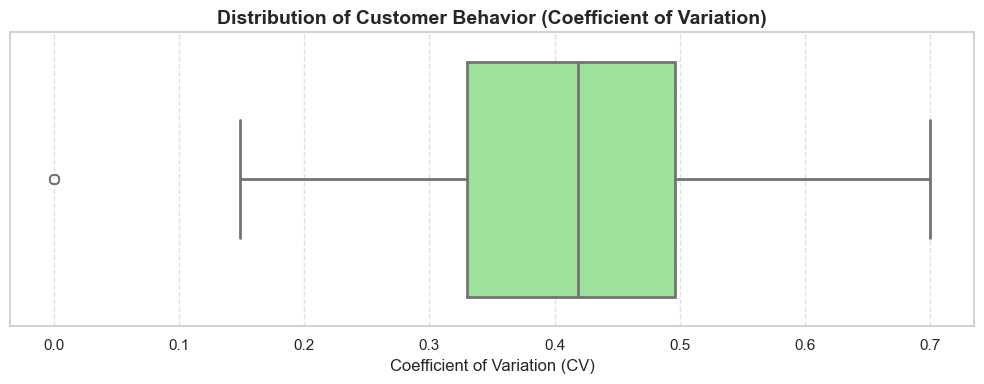


--- CV Summary ---
count    97.000000
mean      0.408345
std       0.162010
min       0.000000
25%       0.330130
50%       0.418850
75%       0.496498
max       0.700083
Name: cv, dtype: float64


In [16]:
# check distribution of customer behaviour

# customer-Day Sorting (Customer Transaction Per Day)
syn_customer_day = syn_customer_day.sort_values(
    ['pseudo_customer_key', 'date']
).reset_index(drop=True)

# coefficient Variation Per Customer
cv_per_customer = (
    syn_customer_day
    .groupby('pseudo_customer_key')['daily_txn_count']
    .agg(['mean', 'std'])
)

# compute CV
cv_per_customer['cv'] = cv_per_customer['std'] / cv_per_customer['mean']

# clean invalid values
cv_per_customer['cv'] = cv_per_customer['cv'].replace([np.inf, -np.inf], np.nan)
cv_per_customer = cv_per_customer.dropna(subset=['cv'])

# Plotting Customer Behavior
plt.figure(figsize=(10, 4))
sns.boxplot(x=cv_per_customer["cv"], color="lightgreen", fliersize=7, linewidth=2)
plt.title("Distribution of Customer Behavior (Coefficient of Variation)", fontsize=14, fontweight="bold")
plt.xlabel("Coefficient of Variation (CV)", fontsize=12)
plt.grid(axis="x", linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()

# summary
print("\n\033[1m--- CV Summary ---\033[0m")
print(cv_per_customer['cv'].describe())


*The median Coefficient of Variation (CV) of 0.42 indicates highly consistent and predictable transaction behavior across the majority of customers, implying that any sudden spike in variance (CV > 0.6) should be treated as a strong indicator of anomalous activity or account takeover.*

### **S3 — 1.2.2.2 Data Preprocessing: Compute expanding baselines (min_periods=5)**

In [17]:
# Sort by customer and date first.
# Compute expanding baselines using the same AS-IS rule:
# baseline is formed with min_periods=5 and excludes the current observation,
# to preserve strict comparability with the AS-IS monitoring logic.

syn_customer_day = syn_customer_day.sort_values(
    ['pseudo_customer_key', 'date']
).reset_index(drop=True)

syn_customer_day['baseline_txn_count'] = (
    syn_customer_day
    .groupby('pseudo_customer_key')['daily_txn_count']
    .transform(lambda x: x.shift(1).expanding(min_periods=5).mean())
)
syn_customer_day['baseline_total_amount'] = (
    syn_customer_day
    .groupby('pseudo_customer_key')['daily_total_amount']
    .transform(lambda x: x.shift(1).expanding(min_periods=5).mean())
)
syn_customer_day['baseline_avg_amount'] = (
    syn_customer_day
    .groupby('pseudo_customer_key')['daily_avg_amount']
    .transform(lambda x: x.shift(1).expanding(min_periods=5).mean())
)

n_formed = syn_customer_day['baseline_txn_count'].notna().sum()
print(f'Baseline formed     : {n_formed:,} ({n_formed/len(syn_customer_day)*100:.1f}%)')
print(f'Baseline not formed : {syn_customer_day["baseline_txn_count"].isna().sum():,}')
print(f'Total customer-days : {len(syn_customer_day):,}')
display(syn_customer_day.head(10))


Baseline formed     : 10,674 (95.7%)
Baseline not formed : 485
Total customer-days : 11,159


,pseudo_customer_key,date,daily_txn_count,daily_total_amount,daily_avg_amount,age,tenure_years,gender_cd,lang_pref,baseline_txn_count,baseline_total_amount,baseline_avg_amount
0,SYN_C_000001,2024-02-06,1,10.10,10.10,82,1,M,EE,NaN,NaN,NaN
1,SYN_C_000001,2024-02-11,2,112.11,56.06,82,1,M,EE,NaN,NaN,NaN
2,SYN_C_000001,2024-02-20,1,19.33,19.33,82,1,M,EE,NaN,NaN,NaN
3,SYN_C_000001,2024-02-27,1,13.19,13.19,82,1,M,EE,NaN,NaN,NaN
4,SYN_C_000001,2024-03-02,1,53.31,53.31,82,1,M,EE,NaN,NaN,NaN
5,SYN_C_000001,2024-03-10,2,201.20,100.60,82,1,M,EE,1.200000,41.608000,30.398000
6,SYN_C_000001,2024-03-12,1,29.40,29.40,82,1,M,EE,1.333333,68.206667,42.098333
7,SYN_C_000001,2024-03-14,1,9.13,9.13,82,1,M,EE,1.285714,62.662857,40.284286
8,SYN_C_000001,2024-03-25,1,31.25,31.25,82,1,M,EE,1.250000,55.971250,36.390000
9,SYN_C_000001,2024-03-28,1,347.32,347.32,82,1,M,EE,1.222222,53.224444,35.818889


### **S3 — 1.2.2.3 Data Preprocessing: Calculate ratio_velocity and ratio_value**

In [18]:
# Compute deviation ratios (identical to AS-IS)
# Avoid division by zero (set baseline 0 -> NaN first to avoid infinity result)
# ratio cannot be calculated when the baseline is not valid or not available

syn_customer_day['baseline_txn_count']    = syn_customer_day['baseline_txn_count'].replace(0, np.nan)
syn_customer_day['baseline_total_amount'] = syn_customer_day['baseline_total_amount'].replace(0, np.nan)

syn_customer_day['ratio_velocity'] = (
    syn_customer_day['daily_txn_count'] / syn_customer_day['baseline_txn_count']
).round(4)

syn_customer_day['ratio_value'] = (
    syn_customer_day['daily_total_amount'] / syn_customer_day['baseline_total_amount']
).round(4)

syn_customer_day[['pseudo_customer_key', 'ratio_velocity', 'ratio_value']].head(10)


,pseudo_customer_key,ratio_velocity,ratio_value
0,SYN_C_000001,NaN,NaN
1,SYN_C_000001,NaN,NaN
2,SYN_C_000001,NaN,NaN
3,SYN_C_000001,NaN,NaN
4,SYN_C_000001,NaN,NaN
5,SYN_C_000001,1.6667,4.8356
6,SYN_C_000001,0.7500,0.4310
7,SYN_C_000001,0.7778,0.1457
8,SYN_C_000001,0.8000,0.5583
9,SYN_C_000001,0.8182,6.5256


<div style="background-color: #f0f4f8; border-left: 6px solid #2c3e50; padding: 18px; border-radius: 8px; font-family: 'Segoe UI', Roboto, sans-serif; display: flex; align-items: flex-start; box-shadow: 0 1px 3px rgba(0,0,0,0.05);">
    <span style="font-size: 1.4em; margin-right: 12px; line-height: 1;">⚖️</span>
    <div>
        <strong style="color: #1a252f; font-size: 1.05em; display: block; margin-bottom: 4px; letter-spacing: 0.3px;">COMPLIANCE CALIBRATION</strong>
        <p style="margin: 0; color: #34495e; line-height: 1.5;">
            A threshold of <b style="color: #2980b9;">1.5</b> provides a wider normal tolerance band, aligning with <b>FATF-based monitoring guidance</b>. 
            The <code style="background: #dfe6e9; padding: 2px 4px; border-radius: 4px; color: #c0392b; font-weight: bold;">Significant (> 2.0)</code> 
            level is strictly reserved for <i style="color: #c0392b;">auto_red_flag</i> triggers.
        </p>
    </div>
</div>

### **S3 — 1.2.2.4 Data Preprocessing: Apply deviation_group --> severity labels**


#### **Group Deviation (Normal / Elevated / Significant)**

*Maps a deviation ratio to a severity group. Thresholds aligned with auto_red_flag logic — **identical to AS-IS**:*

*1. Normal      : ratio ≤ 1.5  (within acceptable tolerance)*
*2. Elevated    : ratio ≤ 2.0  (requires monitoring attention)*
*3. Significant : ratio > 2.0  (triggers auto_red_flag)*


In [19]:
# Apply severity labels (IDENTICAL function to AS-IS)
def deviation_group(r):
    if pd.isna(r):
        return np.nan
    elif r <= 1.5:
        return "Normal"
    elif r <= 2.0:
        return "Elevated"
    else:
        return "Significant"


syn_customer_day["velocity_severity"] = syn_customer_day["ratio_velocity"].apply(deviation_group)
syn_customer_day["value_severity"]    = syn_customer_day["ratio_value"].apply(deviation_group)

print('velocity_severity:', syn_customer_day['velocity_severity'].value_counts(dropna=False).to_dict())
print('value_severity   :', syn_customer_day['value_severity'].value_counts(dropna=False).to_dict())


velocity_severity: {'Normal': 8909, 'Elevated': 1144, 'Significant': 621, nan: 485}
value_severity   : {'Normal': 9091, 'Significant': 1296, nan: 485, 'Elevated': 287}


*Deviation ratios are further translated into severity categories to enable structured interpretation of behavioral changes. Each observation is classified along two dimensions: ***transaction frequency (velocity) and transaction value.****

---
#### **Velocity Severity vs Value Severity**
---

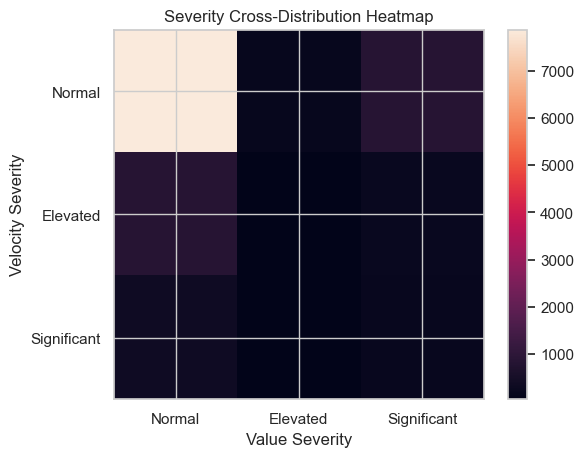


========== SEVERITY SANITY CHECK ==========

Velocity Severity:
                   Count  Percentage (%)
velocity_severity                       
Normal              8909           83.46
Elevated            1144           10.72
Significant          621            5.82

Value Severity:
                Count  Percentage (%)
value_severity                       
Normal           9091           85.17
Significant      1296           12.14
Elevated          287            2.69



In [20]:
# Cross-tab
heatmap_data = pd.crosstab(
    syn_customer_day["velocity_severity"],
    syn_customer_day["value_severity"]
)

# Ensure consistent ordering
order = ["Normal", "Elevated", "Significant"]
heatmap_data = heatmap_data.reindex(index=order, columns=order)

plt.figure()
plt.imshow(heatmap_data)
plt.colorbar()

plt.xticks(range(len(order)), order)
plt.yticks(range(len(order)), order)

plt.xlabel("Value Severity")
plt.ylabel("Velocity Severity")
plt.title("Severity Cross-Distribution Heatmap")

plt.show()


print("\n\033[1m" + "="*10 + " SEVERITY SANITY CHECK " + "="*10 + "\033[0m")

for col in ["velocity_severity", "value_severity"]:
    # Create a summary table: Count and Percentage side-by-side
    summary = pd.concat([
        syn_customer_day[col].value_counts(),
        (syn_customer_day[col].value_counts(normalize=True) * 100).round(2)
    ], axis=1)
    
    summary.columns = ['Count', 'Percentage (%)']
    
    print(f"\n\033[1m{col.replace('_', ' ').title()}:\033[0m")
    print(summary)

print("\n\033[1m" + "="*43 + "\033[0m")

### **S3 — 1.2.2.5 Data Preprocessing: Apply auto_red_flag**



### **Auto Red Flag — Rule Trigger**

*`auto_red_flag = 1` when **either** `velocity_severity = "Significant"` OR `value_severity = "Significant"`*

This ensures full consistency with the severity framework — **identical to AS-IS**:
- `Significant` is defined as ratio > 2.0 in `deviation_group()`
- `auto_red_flag` fires at the same threshold — no gap between severity and flag


In [21]:
# Auto_red_flag (IDENTICAL to AS-IS)
syn_customer_day["auto_red_flag"] = np.where(
    (syn_customer_day["velocity_severity"] == "Significant") |
    (syn_customer_day["value_severity"]    == "Significant"),
    1,
    0
)

# mark unevaluated observations separately
syn_customer_day.loc[
    syn_customer_day["velocity_severity"].isna() &
    syn_customer_day["value_severity"].isna(),
    "auto_red_flag"
] = np.nan

# to assign the non ready baseline transaction
syn_customer_day["is_evaluated"] = syn_customer_day["baseline_txn_count"].notna().astype(int)

# Consistency check
flag_check   = syn_customer_day[syn_customer_day["auto_red_flag"] == 1]
inconsistent = flag_check[
    (flag_check["velocity_severity"] != "Significant") &
    (flag_check["value_severity"]    != "Significant")
]

print(f'auto_red_flag=1 rows   : {len(flag_check):,}')
print(f'Inconsistent rows      : {len(inconsistent)}')
print(f'Result: {"CONSISTENT (Yes)" if len(inconsistent) == 0 else "INCONSISTENT (No)"}')
print()
print('auto_red_flag distribution:')
print(syn_customer_day["auto_red_flag"].value_counts(dropna=False))


auto_red_flag=1 rows   : 1,709
Inconsistent rows      : 0
Result: CONSISTENT (Yes)

auto_red_flag distribution:
auto_red_flag
0.0    8965
1.0    1709
NaN     485
Name: count, dtype: int64


In [22]:
print('\n\033[1m---------- SYNTHETIC CUSTOMER DAY SUMMARY ----------\n\033[0m')
print(f'Shape             : {syn_customer_day.shape}')
print(f'Unique clients    : {syn_customer_day["pseudo_customer_key"].nunique():,}')
print(f'Date range        : {syn_customer_day["date"].min()} -> {syn_customer_day["date"].max()}')
print(f'Baseline formed   : {syn_customer_day["baseline_txn_count"].notna().sum():,}')
print(f'Auto red flag rows: {syn_customer_day["auto_red_flag"].sum():,.0f}')
display(syn_customer_day.head())



---------- SYNTHETIC CUSTOMER DAY SUMMARY ----------

Shape             : (11159, 18)
Unique clients    : 100
Date range        : 2024-01-01 00:00:00 -> 2024-12-31 00:00:00
Baseline formed   : 10,674
Auto red flag rows: 1,709


,pseudo_customer_key,date,daily_txn_count,daily_total_amount,daily_avg_amount,age,tenure_years,gender_cd,lang_pref,baseline_txn_count,baseline_total_amount,baseline_avg_amount,ratio_velocity,ratio_value,velocity_severity,value_severity,auto_red_flag,is_evaluated
0,SYN_C_000001,2024-02-06,1,10.10,10.10,82,1,M,EE,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
1,SYN_C_000001,2024-02-11,2,112.11,56.06,82,1,M,EE,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
2,SYN_C_000001,2024-02-20,1,19.33,19.33,82,1,M,EE,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
3,SYN_C_000001,2024-02-27,1,13.19,13.19,82,1,M,EE,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
4,SYN_C_000001,2024-03-02,1,53.31,53.31,82,1,M,EE,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0


## **S3 — 1.2.3 Output Dataset — 1LoD DataOps**

***Ouput:** `syn_custpmer_day` — The Golden Source*.

| Feature                        | AS-IS `customer_day`                    | TO-BE `syn_customer_day`                |
| ------------------------------ | --------------------------------------- | --------------------------------------------- |
| **Contains PII**               | ***Yes*** (client_id, IBANs)            | ***No*** (pseudo_customer_key only)           |
| **Shared to all lines**        | ***No*** — restricted access            | ***Yes*** — direct shared access              |
| **Demographics included**      | ***No*** — requires separate IT request | ***Yes*** — integrated during data generation |
| **Cross-line join capability** | ***Not possible***                      | ***Yes*** — via `pseudo_customer_key`         |


### **S3 — 1.2.3.1 Output Dataset: DataOps Transformation Output**

***`Synthetic Data --> DataOps (Structural & Semantic Transformation)`***

| Dimension       | SDG Input                     | DataOps Output: `syn_customer_day`                   | Structural Change        |
| --------------- | ----------------------------- | ---------------------------------------------------- | ------------------------ |
| **Granularity** | Event-level (transaction)     | Customer-day aggregation                             | Event → Aggregated       |
| **PII**         | No PII (pseudo_customer_key)  | No PII (pseudo_customer_key)                         | Preserved (privacy-safe) |
| **Access**      | Restricted (DataOps layer)    | Shared across all three lines                        | Democratized             |
| **Enrichment**  | Transactional attributes only | + Demographics (embedded during generation)          | Enriched                 |
| **Consistency** | Synthetic distributions       | Deterministic feature logic (ratio, severity, flags) | Structurally consistent  |


### **S3 — 1.2.3.2 Data Dimension Gap: IT vs DataOps (TO-BE Golden Source)**
| Dimension           | IT (Raw Transaction Layer)            | DataOps (`syn_customer_day`)                    | Gap / Transformation             |
| ------------------- | ------------------------------------- | ----------------------------------------------- | -------------------------------- |
| **Granularity**     | Transaction-level (event-by-event)    | Customer-day aggregation                        | Event → behavioral aggregation   |
| **Data Structure**  | Flat transactional records            | Derived behavioral features (ratios, baselines) | Structural transformation        |
| **Temporal Detail** | Exact timestamp (date + time)         | Aggregated per day                              | Temporal abstraction (day-level) |
| **Feature Type**    | Raw attributes (amount, channel, MCC) | Derived indicators (ratio, severity, flags)     | Raw → analytical abstraction     |
| **Dependency**      | Independent records                   | Interdependent features (baseline, ratios)      | Increased analytical dependency  |
| **Traceability**    | Direct (transaction → event)          | Linked (via pseudo_customer_key & date)         | Traceable without restriction    |
| **PII Exposure**    | Full (IBAN, client_id)                | None (pseudo_customer_key)                      | Privacy preserved                |
| **Data Fidelity**   | Exact real data                       | Synthetic, distribution-preserving              | Controlled approximation         |
| **Join Capability** | Limited across lines                  | Fully joinable via pseudo_customer_key          | Interoperability enabled         |
| **Accessibility**   | Restricted (IT-controlled)            | Shared across all lines                         | Access democratized              |


---

<div style="background-color: #fcfcfc; border-left: 6px solid #607d8b; padding: 20px; border-radius: 8px; font-family: 'Segoe UI', Roboto, sans-serif; box-shadow: 0 1px 3px rgba(0,0,0,0.05);">
    <div style="display: flex; align-items: center; margin-bottom: 12px;">
        <span style="font-size: 1.4em; margin-right: 12px; line-height: 1;">🏗️</span>
        <strong style="color: #263238; font-size: 1.1em; letter-spacing: 0.3px;">DATA OPS ARCHITECTURE</strong>
    </div>
    <div style="color: #37474f; line-height: 1.6;">
        <p style="margin: 0; font-size: 0.95em;">
            The DataOps layer transforms raw IT structures into an <b>analytical representation</b> optimized for monitoring. 
        </p>
        <div style="margin-top: 10px; display: flex; align-items: flex-start; background: #fff; padding: 10px; border-radius: 6px; border: 1px solid #eceff1;">
            <span style="margin-right: 10px;">⚠️</span>
            <span style="font-size: 0.9em; color: #546e7a;">
                <b>Trade-off:</b> While this introduces a minor loss in event-level granularity, it secures <b>privacy-preserving access</b> and <b>cross-functional usability</b> across all lines of defense.
            </span>
        </div>
    </div>
</div>

---
# **S3 — 1.3 — 1LoD: Business Operations Department (Monitoring & Escalation)**

***Input:** `syn-customer_day`  — The Golden Source.*


## **1LoD — Business Operations Department**

| Component          | Description                                                                                                                                                                                                                                                                                                                                                                                                                           |
| ------------------ | ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| **Role**           | Business Operations (Decision Layer — Monitoring, Case Evaluation, and Escalation Handling)                                                                                                                                                                                                                                                                                                                                           |
| **Input**          | `syn_customer_day` (shared analytical dataset from DataOps — Golden Source)                                                                                                                                                                                                                                                                                                                                                           |
| **Output**         | Multi-layer operational datasets: <br> • `tobe_ops_log` (full monitoring population) <br> • `tobe_ops_case_log` (escalated cases) <br> • `tobe_transactions_case_linked` (full transaction linkage) <br> • `tobe_transactions_case_view` (escalated transaction subset) <br> • `tobe_customer_day_registry` (enriched monitoring registry) <br> • `tobe_ops_reviewed` (review-ready dataset) <br> • `dashboard_summary` (KPI summary) |
| **Granularity**    | Customer-day (case-level for escalated observations; transaction-level for investigation view)                                                                                                                                                                                                                                                                                                                                        |
| **Fields**         | Analytical features (ratio, severity, flags) + decision attributes (suspiciousness_label, ops_disposition, ops_rules)                                                                                                                                                                                                                                                                                                                 |
| **Processing**     | Rule-based evaluation, threshold assessment, case creation, escalation decision, and transaction-level linkage                                                                                                                                                                                                                                                                                                                        |
| **Purpose**        | Detect suspicious activity, perform decision-making, and enable immediate investigation through linked data                                                                                                                                                                                                                                                                                                                           |
| **Key Difference** | Self-serve investigation capability — escalation enables immediate access to transaction-level data without IT request or waiting time                                                                                                                                                                                                                                                                                                |


---
## **S3 — 1.3.1 Input Dataset — 1LoD Business Operations**

In TO-BE, Business Ops accesses `syn_customer_day` directly — all columns, no IT request.

In [23]:
# In AS-IS: Business Ops receives customer_day with restricted columns
# In TO-BE: Business Ops accesses full synthetic_customer_day directly

tobe_ops_df = syn_customer_day.copy()

print("\033[1m----- TO-BE BUSINESS OPERATIONS INPUT -----\033[0m")

print(f'synthetic customer transaction per day: {tobe_ops_df.shape}')
print()
print('synthetic customer transaction per day columns:')
print(tobe_ops_df.columns.tolist())

print("\n\033[1m----- FULL CUSTOMER TRANSACTION PER DAY DATASET -----\033[0m")
display(tobe_ops_df.head(10))



----- TO-BE BUSINESS OPERATIONS INPUT -----
synthetic customer transaction per day: (11159, 18)

synthetic customer transaction per day columns:
['pseudo_customer_key', 'date', 'daily_txn_count', 'daily_total_amount', 'daily_avg_amount', 'age', 'tenure_years', 'gender_cd', 'lang_pref', 'baseline_txn_count', 'baseline_total_amount', 'baseline_avg_amount', 'ratio_velocity', 'ratio_value', 'velocity_severity', 'value_severity', 'auto_red_flag', 'is_evaluated']

----- FULL CUSTOMER TRANSACTION PER DAY DATASET -----


,pseudo_customer_key,date,daily_txn_count,daily_total_amount,daily_avg_amount,age,tenure_years,gender_cd,lang_pref,baseline_txn_count,baseline_total_amount,baseline_avg_amount,ratio_velocity,ratio_value,velocity_severity,value_severity,auto_red_flag,is_evaluated
0,SYN_C_000001,2024-02-06,1,10.10,10.10,82,1,M,EE,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
1,SYN_C_000001,2024-02-11,2,112.11,56.06,82,1,M,EE,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
2,SYN_C_000001,2024-02-20,1,19.33,19.33,82,1,M,EE,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
3,SYN_C_000001,2024-02-27,1,13.19,13.19,82,1,M,EE,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
4,SYN_C_000001,2024-03-02,1,53.31,53.31,82,1,M,EE,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
5,SYN_C_000001,2024-03-10,2,201.20,100.60,82,1,M,EE,1.200000,41.608000,30.398000,1.6667,4.8356,Elevated,Significant,1.0,1
6,SYN_C_000001,2024-03-12,1,29.40,29.40,82,1,M,EE,1.333333,68.206667,42.098333,0.7500,0.4310,Normal,Normal,0.0,1
7,SYN_C_000001,2024-03-14,1,9.13,9.13,82,1,M,EE,1.285714,62.662857,40.284286,0.7778,0.1457,Normal,Normal,0.0,1
8,SYN_C_000001,2024-03-25,1,31.25,31.25,82,1,M,EE,1.250000,55.971250,36.390000,0.8000,0.5583,Normal,Normal,0.0,1
9,SYN_C_000001,2024-03-28,1,347.32,347.32,82,1,M,EE,1.222222,53.224444,35.818889,0.8182,6.5256,Normal,Significant,1.0,1


---
## **S3 — 1.3.2 Data Processing — 1LoD Business Operations**

Once the risk assessment logic has been calculated on the data operations layer, Business Operations reviews the output of `synthetic_customer_day` and applies the suspiciousness labeling and disposition logic — **identical to AS-IS**.

### **Data Processing: The Investigation Cycle: From Signal to Resolution Action**

```mermaid
flowchart LR
    %% Initial Phase
    Ratio --> Matrix{Suspicious Matrix}
    Matrix -- "Flag 0" --> NE[Non-Escalation]
    Matrix -- "Flag 1" --> Esc[Escalation]

    %% Investigation Phase — TO-BE DIFFERENCE
    Esc --> OCR[Ops Case Review]
    OCR --> SelfServe{Self-Serve\nDrill-Down}
    SelfServe <-->|Direct Access\nNo IT Request| GoldenSource[("The Golden Source\nsynthetic_customer_day")]

    %% Result Phase
    SelfServe --> Result[Investigation Result & Decision]
    Result --> Link[Synthetic Transaction Case Linked]

    %% Logging & Audit
    NE --> AT[[Audit Trail]]
    Link --> AT

    %% Exception path
    Link -.->|Only for Legal Evidence| RealData[(Real PII Data\nFormal Request)]

    %% Styling
    style Esc fill:#f8d7da,stroke:#721c24,stroke-width:2px
    style NE fill:#d4edda,stroke:#155724
    style GoldenSource fill:#fff9c4,stroke:#fbc02d,stroke-width:3px
    style AT fill:#f3e5f5,stroke:#4a148c,stroke-width:2px
    style RealData fill:#eeeeee,stroke:#999,stroke-dasharray:5 5
```




<div style="background-color: #f0fff4; border-left: 6px solid #27ae60; padding: 18px; border-radius: 8px; font-family: 'Segoe UI', Roboto, sans-serif; display: flex; align-items: flex-start; box-shadow: 0 1px 3px rgba(0,0,0,0.05);">
    <span style="font-size: 1.4em; margin-right: 12px; line-height: 1;">🔄</span>
    <div>
        <strong style="color: #1e8449; font-size: 1.05em; display: block; margin-bottom: 4px; letter-spacing: 0.3px;">INVESTIGATION CYCLE OPTIMIZATION</strong>
        <p style="margin: 0; color: #145a32; line-height: 1.6;">
            <b>Key difference from AS-IS:</b> 
            <ul style="margin: 8px 0 0 0; padding-left: 20px;">
                <li><b>Self-Serve Analysis:</b> Investigators can perform drill-downs independently via <code style="background: #d4edda; padding: 2px 4px; border-radius: 4px;">pseudo_customer_key</code> join, removing IT bottlenecks.</li>
                <li><b>PII Minimization:</b> Access to actual PII is strictly reserved for <i>formal legal evidence</i>, rather than routine investigation tasks.</li>
            </ul>
        </p>
    </div>
</div>


### **S3 — 1.3.2.1 Data Processing: Suspiciousness Labeling** *(map_suspiciousness)*

In [24]:
# Suspiciousness labeling — IDENTICAL function map to AS-IS
# Priority: auto_flag=1 -> High -> Significant -> Elevated -> Normal

def map_suspiciousness(velocity_group, value_group, auto_flag=np.nan):
    if auto_flag == 1:
        return "High"
    elif velocity_group == "Significant" or value_group == "Significant":
        return "High"
    elif velocity_group == "Elevated" or value_group == "Elevated":
        return "Medium"
    elif velocity_group == "Normal" and value_group == "Normal":
        return "Low"
    else:
        return np.nan


tobe_ops_df["suspiciousness_label"] = tobe_ops_df.apply(
    lambda r: map_suspiciousness(
        r["velocity_severity"],
        r["value_severity"],
        r["auto_red_flag"] # auto_red_flag now participates in labeling
    ),
    axis=1
)

print("\n\033[1m---------- SANITY CHECK AFTER SUSPICIOUSNESS LABELING PROCESS----------\033[0m")

# Check 1: Significant severity must always be labeled High
significant_not_high = tobe_ops_df[
    (
        (tobe_ops_df["velocity_severity"] == "Significant") |
        (tobe_ops_df["value_severity"] == "Significant")
    ) &
    (tobe_ops_df["suspiciousness_label"] != "High")
]

print(f"\nRows with Significant severity but not labeled High: {len(significant_not_high)}")

# Check 2: auto_red_flag = 1 must always be High
flag_not_high = tobe_ops_df[
    (tobe_ops_df["auto_red_flag"] == 1) &
    (tobe_ops_df["suspiciousness_label"] != "High")
]

print(f"Rows with auto_red_flag=1 but not labeled High: {len(flag_not_high)}")

# Summary
print("\n---------- Suspiciousness label distribution: ----------")
print(tobe_ops_df["suspiciousness_label"].value_counts(dropna=False))

print("\n---------- auto_red_flag=1 -> suspiciousness_label: ----------")
print(
    tobe_ops_df[tobe_ops_df["auto_red_flag"] == 1]["suspiciousness_label"]
    .value_counts(dropna=False)
)


---------- SANITY CHECK AFTER SUSPICIOUSNESS LABELING PROCESS----------

Rows with Significant severity but not labeled High: 0
Rows with auto_red_flag=1 but not labeled High: 0

---------- Suspiciousness label distribution: ----------
suspiciousness_label
Low       7866
High      1709
Medium    1099
NaN        485
Name: count, dtype: int64

---------- auto_red_flag=1 -> suspiciousness_label: ----------
suspiciousness_label
High    1709
Name: count, dtype: int64


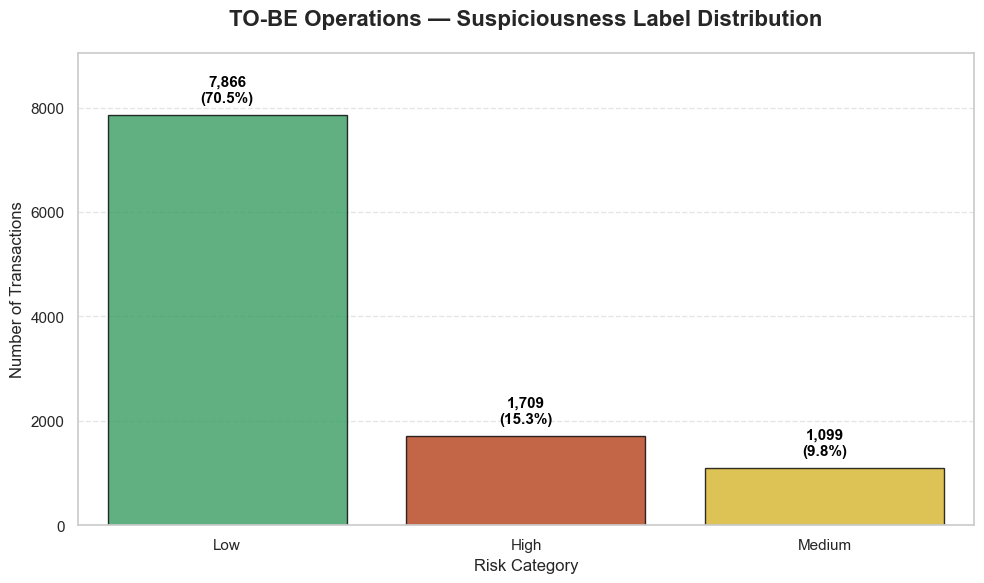

In [25]:
# Visualize suspiciousness distribution

# Pre-calculate data
label_counts = (tobe_ops_df["suspiciousness_label"].value_counts(dropna=False)
                .reset_index(name="Count")
                .rename(columns={"index": "Label"})
                .sort_values("Count", ascending=False))

#specify the name
label_counts.columns = ["Label", "Count"]

total = label_counts["Count"].sum()

# Define standard Risk colors
color_palette = {"High": "#cc3300",   # Bold Red
                 "Medium": "#f1c40f", # Payday Yellow
                 "Low": "#27ae60",    # Green
                 np.nan: "grey"}      # Grey for NaN if present

# Create Plot
plt.figure(figsize=(10, 6))

# Map colors directly using 'hue' and 'palette'
ax = sns.barplot(data=label_counts, 
                 x="Label", 
                 y="Count", 
                 hue="Label", 
                 palette=color_palette, 
                 legend=False, 
                 edgecolor="black", 
                 alpha=0.8)         #a little bit transparant

# Annotations
for p in ax.patches:
    height = p.get_height()
    percentage = f"{(height / total * 100):.1f}%"
    count = int(height)
    
    ax.annotate(f"{count:,}\n({percentage})", 
                (p.get_x() + p.get_width() / 2., height), 
                ha='center', 
                va='bottom', 
                fontsize=11, 
                fontweight='bold', 
                color='black', 
                xytext=(0, 7), # Sedikit offset ke atas
                textcoords='offset points')

# 5. Styling & Labels
plt.title("TO-BE Operations — Suspiciousness Label Distribution", 
          fontsize=16, 
          fontweight='bold', 
          pad=20)

plt.xlabel("Risk Category", fontsize=12)
plt.ylabel("Number of Transactions", fontsize=12)

plt.ylim(0, label_counts["Count"].max() * 1.15) 

plt.grid(axis='y', linestyle='--', alpha=0.5) # Grid halus
plt.tight_layout()
plt.show()

*The distribution reflects a balanced detection mechanism, capturing varying levels of behavioral deviation while maintaining consistency between computational signals and operational decision logic. It confirms that the system is neither overly conservative nor overly sensitive, maintaining an effective balance between detection capability and operational feasibility.*



<div style="background-color: #f0f7ff; border-left: 6px solid #0056b3; padding: 18px; border-radius: 8px; font-family: 'Segoe UI', Roboto, sans-serif; display: flex; align-items: flex-start; box-shadow: 0 1px 3px rgba(0,0,0,0.05);">
    <span style="font-size: 1.4em; margin-right: 12px; line-height: 1;">⚙️</span>
    <div>
        <strong style="color: #004085; font-size: 1.05em; display: block; margin-bottom: 4px; letter-spacing: 0.3px;">LOGIC PARITY</strong>
        <p style="margin: 0; color: #2c3e50; line-height: 1.5;">
            Upon calculation at the data operations layer, Business Operations reviews the <code style="background: #e1efff; padding: 2px 4px; border-radius: 4px;">synthetic_customer_day</code> output. The suspiciousness labeling and disposition logic applied here remain <b>identical to AS-IS</b> to ensure consistency and baseline integrity.
        </p>
    </div>
</div>

---
### **S3 — 1.3.2.2 Data Processing: Disposition Process: Governance-Oriented Rule-Based Approach**
---

<div style="background-color: #fcfcfc; border-left: 6px solid #455a64; padding: 20px; border-radius: 8px; font-family: 'Segoe UI', Roboto, sans-serif; box-shadow: 0 2px 5px rgba(0,0,0,0.08);">
    <div style="display: flex; align-items: center; margin-bottom: 12px;">
        <span style="font-size: 1.4em; margin-right: 12px; line-height: 1;">🚦</span>
        <strong style="color: #263238; font-size: 1.15em; letter-spacing: 0.5px;">OPERATIONAL TRIAGE FRAMEWORK</strong>
    </div>
    <div style="color: #37474f; line-height: 1.6;">
        <p style="margin-bottom: 12px; font-size: 0.95em; color: #546e7a;">
            Final dispositions are executed via a deterministic SOP based on the risk-level classification:
        </p>
        <div style="display: flex; align-items: center; margin-bottom: 8px;">
            <span style="min-width: 25px;">🔴</span>
            <b style="color: #c62828; min-width: 80px;">HIGH</b> 
            <span style="margin: 0 10px; color: #b0bec5;">➔</span> 
            <span style="background: #ffebee; color: #b71c1c; padding: 2px 8px; border-radius: 4px; font-weight: bold; font-size: 0.9em;">ESCALATE</span>
            <i style="margin-left: 10px; color: #78909c; font-size: 0.9em;">Immediate priority for senior investigation.</i>
        </div>
        <div style="display: flex; align-items: center; margin-bottom: 8px;">
            <span style="min-width: 25px;">🟡</span>
            <b style="color: #f9a825; min-width: 80px;">MEDIUM</b> 
            <span style="margin: 0 10px; color: #b0bec5;">➔</span> 
            <span style="background: #fff9c4; color: #f57f17; padding: 2px 8px; border-radius: 4px; font-weight: bold; font-size: 0.9em;">UNDER REVIEW</span>
            <i style="margin-left: 10px; color: #78909c; font-size: 0.9em;">Requires further assessment by the team.</i>
        </div>
        <div style="display: flex; align-items: center;">
            <span style="min-width: 25px;">🟢</span>
            <b style="color: #2e7d32; min-width: 80px;">LOW</b> 
            <span style="margin: 0 10px; color: #b0bec5;">➔</span> 
            <span style="background: #e8f5e9; color: #1b5e20; padding: 2px 8px; border-radius: 4px; font-weight: bold; font-size: 0.9em;">DISMISS</span>
            <i style="margin-left: 10px; color: #78909c; font-size: 0.9em;">No further action needed; case closed.</i>
        </div>
    </div>
</div>

---

**Why we do this:**

This structure ensures a clear Separation of Duties:

* **Data Operations** focuses on the technical "math" (calculating risk indicators).
* **Business Operations** focuses on the "judgment" (deciding the final action).This approach guarantees that every alert is handled consistently, removing guesswork while maintaining a high standard of governance.
---

In [26]:
## **Disposition Process — identical to AS-IS**

def assign_disposition(label):
    if pd.isna(label):
        return np.nan
    elif label == "High":
        return "Escalate"
    elif label == "Medium":
        return "Under review"
    elif label == "Low":
        return "Dismiss"
    else:
        return np.nan


tobe_ops_df["ops_disposition"] = (
    tobe_ops_df["suspiciousness_label"].apply(assign_disposition)
)


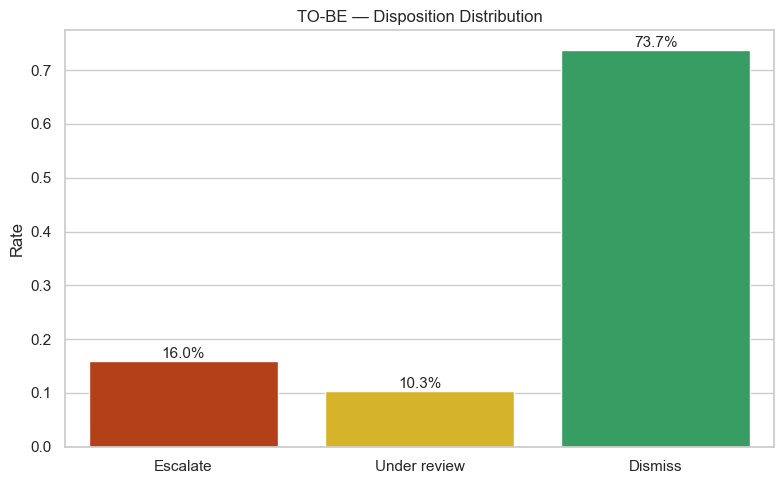


----- Disposition distribution: -----
ops_disposition
Dismiss         7866
Escalate        1709
Under review    1099
NaN              485
Name: count, dtype: int64


In [27]:
# Visualize disposition

total_cases = tobe_ops_df["ops_disposition"].notna().sum()
disposition_counts = tobe_ops_df["ops_disposition"].value_counts()

labels = ["Escalate", "Under review", "Dismiss"]
rates  = [disposition_counts.get(l, 0) / total_cases for l in labels]

plt.figure(figsize=(8, 5))
colors = ["#cc3300", "#f1c40f", "#27ae60"]
ax = sns.barplot(x=labels, y=rates, hue=labels, legend=False, palette=colors)
for p in ax.patches:
    ax.annotate(f'{p.get_height()*100:.1f}%',
                (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center', va='bottom', fontsize=11)
    
plt.title("TO-BE — Disposition Distribution")
plt.ylabel("Rate")
plt.tight_layout()
plt.show()


print("\n\033[1m----- Disposition distribution: -----\033[0m")
print(tobe_ops_df["ops_disposition"].value_counts(dropna=False))


*The TO-BE distribution shows a three-tier triage where ~16% cases are escalated, ~10% reviewed, and ~73% dismissed. Most ***non-critical cases*** are filtered early, improving efficiency. The `Under Review` layer adds a buffer for contextual checks and reduces false positives. This keeps escalation focused on truly significant cases. Overall, it reflects a balanced and operationally effective monitoring design.*

---
### **S3 — 1.3.2.3 Data Processing: Case History / Log (Tracing the Disposition Process Approach)**
---

*The case log serves as a formal record to trace the escalation process when a suspicious observation (customer-day level) is identified through indicator-based triage.*

> Each case is assigned a unique case_id, which enables Business Operations to consistently reference the affected customer-day during further investigation. When a case is escalated, detailed transaction-level information is required to support deeper analysis. 

While both AS-IS and TO-BE models maintain a case log with unique case_id for traceability, the key difference lies in data access. In the TO-BE model, ***Business Operations can directly perform drill-down using shared synthetic data, eliminating the need for IT-mediated data requests***. This enables a more integrated and parallel workflow from signal generation to investigation, with optional Second Line validation. As a result, dependency on cross-line data reconstruction is reduced, improving investigation efficiency and responsiveness.


<div style="background-color: #0f172a; border-radius: 15px; padding: 40px; font-family: 'Segoe UI', Roboto, sans-serif; box-shadow: 0 20px 25px -5px rgba(0, 0, 0, 0.1), 0 10px 10px -5px rgba(0, 0, 0, 0.04); text-align: center; position: relative; overflow: hidden; max-width: 900px; margin: auto;">
    <div style="position: absolute; top: -20px; right: -20px; width: 150px; height: 150px; background: rgba(56, 189, 248, 0.05); border-radius: 50%;"></div>
    <div style="position: absolute; bottom: -20px; left: -20px; width: 100px; height: 100px; background: rgba(56, 189, 248, 0.05); border-radius: 50%;"></div>
    <div style="position: relative; z-index: 1;">
        <span style="font-size: 2.5em; display: block; margin-bottom: 20px;">🎯</span>
        <h2 style="color: #38bdf8; font-size: 1.4em; margin: 0 0 15px 0; letter-spacing: 2px; text-transform: uppercase; font-weight: 800;">The Strategic Outcome</h2>
        <p style="color: #f8fafc; font-size: 1.8em; line-height: 1.4; margin: 0; font-weight: 300;">
            A fundamental shift from <br>
            <span style="color: #94a3b8; font-style: italic; font-weight: 400;">permission-based</span> 
            <span style="color: #38bdf8; font-weight: 700;">➔</span> 
            <b style="color: #ffffff; font-weight: 700;">empowerment-based</b> <br>
            investigation.
        </p>
        <div style="height: 1px; width: 80px; background: #334155; margin: 30px auto;"></div>
        <p style="color: #94a3b8; font-size: 0.95em; max-width: 600px; margin: 0 auto; line-height: 1.6;">
            By resolving the <b>Privacy vs. Access</b> trade-off, the TO-BE architecture replaces recursive request cycles with <b>autonomous analytical depth</b>—enabling investigators to follow risk signals in real-time without structural latency.
        </p>
    </div>
</div>


In [28]:
# Rules documentation — IDENTICAL to AS-IS

def rules(row):
    parts = []
    
    # Readiness layer
    if row.get("is_evaluated") == 0:
        return "Not evaluated (baseline not ready)"
        
    # auto flag trigger rules
    if row.get("auto_red_flag") == 1:
        parts.append("auto_red_flag=1 (Significant severity triggered)")

    # velocity severity rules
    if row.get("velocity_severity") == "Significant":
        parts.append("velocity_severity=Significant (ratio_velocity > 2.0)")
    elif row.get("velocity_severity") == "Elevated":
        parts.append("velocity_severity=Elevated (1.5 < ratio_velocity ≤ 2.0)")
    elif row.get("velocity_severity") == "Normal":
        parts.append("velocity_severity=Normal (ratio_velocity ≤ 1.5)")

    
    # value severity rules
    if row.get("value_severity") == "Significant":
        parts.append("value_severity=Significant (ratio_value > 2.0)")
    elif row.get("value_severity") == "Elevated":
        parts.append("value_severity=Elevated (1.5 < ratio_value ≤ 2.0)")
    elif row.get("value_severity") == "Normal":
        parts.append("value_severity=Normal (ratio_value ≤ 1.5)")

    
    # final suspiciousness label
    if row.get("suspiciousness_label") in ["High", "Medium", "Low"]:
        parts.append(f'suspiciousness_label={row["suspiciousness_label"]}')
        
    return "; ".join(parts) if parts else "No trigger (baseline not ready or Normal range)"

# Ensure date is datetime
tobe_ops_df["date"]    = pd.to_datetime(tobe_ops_df["date"])
tobe_ops_df["ops_rules"] = tobe_ops_df.apply(rules, axis=1)


# CASE CREATION LOGIC
# High = formal case
# Medium = under review only (no formal case)
# Low = no case


case_candidates = tobe_ops_df[
    tobe_ops_df["suspiciousness_label"] == "High"
].copy()

case_candidates["case_id"] = (
    "CASE_" +
    case_candidates["pseudo_customer_key"].astype(str) + "_" +
    case_candidates["date"].dt.strftime("%Y%m%d")
)
case_candidates["case_created_at"] = pd.Timestamp.now()

print(f'Case candidates: {len(case_candidates):,}')


Case candidates: 1,709


---
### **S3 — 1.3.2.4 Data Processing: Case Log Creation**
---
***Output:** `tobe_ops_case_log`, `tobe_ops_log`*

*Creates a formal case log dataset for traceability and audit purposes*

This process creates a formal case log dataset that captures all evaluated customer-day observations resulting from the monitoring process, including their risk classification and operational disposition. The dataset supports traceability and serves as an audit trail for cases that are dismissed, reviewed, or escalated.



<div style="background-color: #f8f9fa; border-left: 6px solid #6c757d; padding: 18px; border-radius: 8px; font-family: 'Segoe UI', Roboto, sans-serif; box-shadow: 0 1px 3px rgba(0,0,0,0.05);">
    <div style="display: flex; align-items: center; margin-bottom: 10px;">
        <span style="font-size: 1.4em; margin-right: 12px; line-height: 1;">📂</span>
        <strong style="color: #343a40; font-size: 1.1em; letter-spacing: 0.3px;">CASE LOG DATASET</strong>
    </div>
    <p style="margin: 0; color: #495057; line-height: 1.6;">
        This dataset serves as the <b>central repository</b> for all evaluated customer-day observations. It captures the end-to-end output of the Business Operations monitoring process, ensuring every risk assessment and final disposition is documented for <b>auditability and traceability</b>.
    </p>
</div>

In [29]:
# Formal case log

tobe_ops_case_log = case_candidates[[
    "case_id", "case_created_at", "pseudo_customer_key", "date",
    "suspiciousness_label", "ops_disposition",
    "ratio_velocity", "ratio_value",
    "velocity_severity", "value_severity",
    "auto_red_flag", "ops_rules"
]].copy()


# case candidates = only High risk
case_candidates = tobe_ops_df[
    tobe_ops_df["suspiciousness_label"] == "High"
].copy()

print("\n\033[1m----- SANITY CHECK CASE LOG DATASET -----\033[0m\n")

print(f'tobe_ops_case_log shape: {tobe_ops_case_log.shape}')
print()
print('\ntobe_ops_case_log columns:\n')
print(tobe_ops_case_log.columns.tolist())

print("\n\033[1m----- CASE LOG DATASET -----\033[0m")
display(tobe_ops_case_log.head())




----- SANITY CHECK CASE LOG DATASET -----

tobe_ops_case_log shape: (1709, 12)


tobe_ops_case_log columns:

['case_id', 'case_created_at', 'pseudo_customer_key', 'date', 'suspiciousness_label', 'ops_disposition', 'ratio_velocity', 'ratio_value', 'velocity_severity', 'value_severity', 'auto_red_flag', 'ops_rules']

----- CASE LOG DATASET -----


,case_id,case_created_at,pseudo_customer_key,date,suspiciousness_label,ops_disposition,ratio_velocity,ratio_value,velocity_severity,value_severity,auto_red_flag,ops_rules
5,CASE_SYN_C_000001_20240310,2026-05-15 13:39:27.836025,SYN_C_000001,2024-03-10,High,Escalate,1.6667,4.8356,Elevated,Significant,1.0,auto_red_flag=1 (Significant severity triggere...
9,CASE_SYN_C_000001_20240328,2026-05-15 13:39:27.836025,SYN_C_000001,2024-03-28,High,Escalate,0.8182,6.5256,Normal,Significant,1.0,auto_red_flag=1 (Significant severity triggere...
11,CASE_SYN_C_000001_20240505,2026-05-15 13:39:27.836025,SYN_C_000001,2024-05-05,High,Escalate,2.5385,0.7895,Significant,Normal,1.0,auto_red_flag=1 (Significant severity triggere...
15,CASE_SYN_C_000001_20240623,2026-05-15 13:39:27.836025,SYN_C_000001,2024-06-23,High,Escalate,0.7895,5.7669,Normal,Significant,1.0,auto_red_flag=1 (Significant severity triggere...
19,CASE_SYN_C_000001_20240726,2026-05-15 13:39:27.836025,SYN_C_000001,2024-07-26,High,Escalate,0.8261,6.3933,Normal,Significant,1.0,auto_red_flag=1 (Significant severity triggere...


In [30]:
# dataframe full

tobe_ops_log = tobe_ops_df[[
    "pseudo_customer_key", "date",
    "suspiciousness_label", "ops_disposition",
    "ratio_velocity", "ratio_value",
    "velocity_severity", "value_severity",
    "auto_red_flag", "ops_rules"
]].copy()

print("\n\033[1m----- SANITY CHECK OPERATIONAL (FULL OPERATIONAL LOG) DATASET -----\033[0m\n")

print(f'tobe_ops_log shape: {tobe_ops_log.shape}')
print()
print('\ntobe_ops_log columns:\n')
print(tobe_ops_log.columns.tolist())

print("\n\033[1m----- FULL OPERATIONAL LOGDATASET -----\033[0m")
display(tobe_ops_log.head())




----- SANITY CHECK OPERATIONAL (FULL OPERATIONAL LOG) DATASET -----

tobe_ops_log shape: (11159, 10)


tobe_ops_log columns:

['pseudo_customer_key', 'date', 'suspiciousness_label', 'ops_disposition', 'ratio_velocity', 'ratio_value', 'velocity_severity', 'value_severity', 'auto_red_flag', 'ops_rules']

----- FULL OPERATIONAL LOGDATASET -----


,pseudo_customer_key,date,suspiciousness_label,ops_disposition,ratio_velocity,ratio_value,velocity_severity,value_severity,auto_red_flag,ops_rules
0,SYN_C_000001,2024-02-06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Not evaluated (baseline not ready)
1,SYN_C_000001,2024-02-11,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Not evaluated (baseline not ready)
2,SYN_C_000001,2024-02-20,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Not evaluated (baseline not ready)
3,SYN_C_000001,2024-02-27,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Not evaluated (baseline not ready)
4,SYN_C_000001,2024-03-02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Not evaluated (baseline not ready)


---
### **S3 — 1.3.2.5 Data Processing: Case Registry Creation**
---
***Output:** `tobe_customer_day_case_registry`*

*Creates a formal case registry dataset for monitoring purpose*

The case registry links monitoring observations with case creation outcomes to support traceability between customer-day signals and formal case handling. By attaching `case_id` to monitoring records, the dataset shows which observations result in case creation and which do not. This provides a monitoring bridge between continuous signal detection and discrete case management.


<div style="background-color: #f4f7f6; border-left: 6px solid #2d3436; padding: 18px; border-radius: 8px; font-family: 'Segoe UI', Roboto, sans-serif; box-shadow: 0 1px 3px rgba(0,0,0,0.05);">
    <div style="display: flex; align-items: center; margin-bottom: 10px;">
        <span style="font-size: 1.4em; margin-right: 12px; line-height: 1;">🔗</span>
        <strong style="color: #2d3436; font-size: 1.1em; letter-spacing: 0.3px;">CASE REGISTRY</strong>
    </div>
    <p style="margin: 0; color: #4b4b4b; line-height: 1.6;">
        The <b>Case Registry</b> serves full <b>traceability</b> by mapping daily customer-level signals to formal case handling, effectively reconciling <b>monitoring outputs</b> with <b>case management actions</b>.
    </p>
</div>

In [31]:
# Monitoring-to-case bridge

tobe_customer_day_case_registry = tobe_ops_df.merge(
    tobe_ops_case_log[["case_id", "pseudo_customer_key", "date"]],
    on=["pseudo_customer_key", "date"],
    how="left"
)
print(f'Case Registry Shape: {tobe_customer_day_case_registry.shape}')

# Flag whether an observation results in formal case creation
tobe_customer_day_case_registry["is_case_created"] = (
    tobe_customer_day_case_registry["case_id"].notna().astype(int)
)

# Medium-risk observations are monitored more closely, but do not become formal cases
tobe_customer_day_case_registry["is_under_review"] = (
    (tobe_customer_day_case_registry["suspiciousness_label"] == "Medium").astype(int)
)

tobe_customer_day_case_registry["monitoring_status"] = np.select(
    [
        tobe_customer_day_case_registry["is_evaluated"] == 0,
        tobe_customer_day_case_registry["is_case_created"] == 1,
        tobe_customer_day_case_registry["is_under_review"] == 1
    ],
    [
        "Not Evaluated",
        "Case Created",
        "Under Review"
    ],
    default="Normal"
)


print("\n\033[1m----- SANITY CHECK CASE REGISTRY DATASET -----\033[0m\n")
print(f'Case registry shape whether an observation resulting case creation: {tobe_customer_day_case_registry.shape}')
print()
print('\ntobe_customer_day_case_registry columns:\n')
print(tobe_customer_day_case_registry.columns.tolist())


print("\n\033[1m----- CASE REGISTRY DATASET -----\033[0m")
display(tobe_customer_day_case_registry.head())


Case Registry Shape: (11159, 22)

----- SANITY CHECK CASE REGISTRY DATASET -----

Case registry shape whether an observation resulting case creation: (11159, 25)


tobe_customer_day_case_registry columns:

['pseudo_customer_key', 'date', 'daily_txn_count', 'daily_total_amount', 'daily_avg_amount', 'age', 'tenure_years', 'gender_cd', 'lang_pref', 'baseline_txn_count', 'baseline_total_amount', 'baseline_avg_amount', 'ratio_velocity', 'ratio_value', 'velocity_severity', 'value_severity', 'auto_red_flag', 'is_evaluated', 'suspiciousness_label', 'ops_disposition', 'ops_rules', 'case_id', 'is_case_created', 'is_under_review', 'monitoring_status']

----- CASE REGISTRY DATASET -----


,pseudo_customer_key,date,daily_txn_count,daily_total_amount,daily_avg_amount,age,tenure_years,gender_cd,lang_pref,baseline_txn_count,...,value_severity,auto_red_flag,is_evaluated,suspiciousness_label,ops_disposition,ops_rules,case_id,is_case_created,is_under_review,monitoring_status
0,SYN_C_000001,2024-02-06,1,10.10,10.10,82,1,M,EE,NaN,...,NaN,NaN,0,NaN,NaN,Not evaluated (baseline not ready),NaN,0,0,Not Evaluated
1,SYN_C_000001,2024-02-11,2,112.11,56.06,82,1,M,EE,NaN,...,NaN,NaN,0,NaN,NaN,Not evaluated (baseline not ready),NaN,0,0,Not Evaluated
2,SYN_C_000001,2024-02-20,1,19.33,19.33,82,1,M,EE,NaN,...,NaN,NaN,0,NaN,NaN,Not evaluated (baseline not ready),NaN,0,0,Not Evaluated
3,SYN_C_000001,2024-02-27,1,13.19,13.19,82,1,M,EE,NaN,...,NaN,NaN,0,NaN,NaN,Not evaluated (baseline not ready),NaN,0,0,Not Evaluated
4,SYN_C_000001,2024-03-02,1,53.31,53.31,82,1,M,EE,NaN,...,NaN,NaN,0,NaN,NaN,Not evaluated (baseline not ready),NaN,0,0,Not Evaluated


*Observations without sufficient historical baseline are not evaluated and therefore do not proceed to risk classification or case creation. These records remain in the registry with a `Not evaluated` status, ensuring completeness of monitoring while avoiding premature decision-making.*

---
### **S3 — 1.3.2.6 Data Processing: Monitoring-to-Case Traceability Analysis**
---
***Output:** `tobe_customer_day_case_registry` and `dashboard_summary`*

*For evaluating how monitoring outputs translate into case creation decisions across suspiciousness levels*

This analysis evaluates how monitoring outputs translate into case creation decisions across suspiciousness levels. It verifies whether high, medium, and low-risk observations are handled consistently according to the intended triage logic.

<div style="background-color: #fcfcfc; border-left: 6px solid #17a2b8; padding: 20px; border-radius: 8px; font-family: 'Segoe UI', Roboto, sans-serif; box-shadow: 0 2px 5px rgba(0,0,0,0.08);">
    <div style="display: flex; align-items: center; margin-bottom: 12px;">
        <span style="font-size: 1.4em; margin-right: 12px; line-height: 1;">📊</span>
        <strong style="color: #087990; font-size: 1.1em; letter-spacing: 0.3px;">ANALYTICAL & OPERATIONAL INSIGHTS</strong>
    </div>
    <p style="margin: 0; color: #333; line-height: 1.6;">
        Leveraging the <b>Case Registry</b>, this dashboard provides dual-layer visibility:
    </p>
    <ul style="margin: 10px 0 0 0; padding-left: 20px; color: #444; line-height: 1.6;">
        <li><b>Analytical View:</b> Measures the <b>selectivity</b> of the escalation process, ensuring high-fidelity risk detection.</li>
        <li><b>Operational View:</b> Evaluates the <b>effectiveness of triage</b>, highlighting the efficiency of final dispositions and resource allocation.</li>
    </ul>
</div>

In [32]:
# monitoring summary

total_n = len(tobe_customer_day_case_registry)

# analytical view
risk_summary = (
    tobe_customer_day_case_registry
    .groupby("suspiciousness_label", dropna=False)["is_case_created"]
    .agg(total_alerts="count", cases_created="sum")
    .reset_index()
)

risk_summary["case_rate"] = risk_summary["cases_created"] / risk_summary["total_alerts"]
risk_summary["share_of_total"] = risk_summary["total_alerts"] / total_n

# operational view
status_summary = (
    tobe_customer_day_case_registry["monitoring_status"]
    .value_counts(dropna=False)
    .rename_axis("monitoring_status")
    .reset_index(name="count")
)

status_summary["share_of_total"] = status_summary["count"] / total_n

print("\n\033[1m----- COMBINED MONITORING SUMMARY: ANALYTICAL VIEW -----\033[0m")
print(risk_summary)

print("\n\033[1m----- COMBINED MONITORING SUMMARY: OPERATIONAL VIEW -----\033[0m")
print(status_summary)



----- COMBINED MONITORING SUMMARY: ANALYTICAL VIEW -----
  suspiciousness_label  total_alerts  cases_created  case_rate  share_of_total
0                 High          1709           1709        1.0        0.153150
1                  Low          7866              0        0.0        0.704902
2               Medium          1099              0        0.0        0.098486
3                  NaN           485              0        0.0        0.043463

----- COMBINED MONITORING SUMMARY: OPERATIONAL VIEW -----
  monitoring_status  count  share_of_total
0            Normal   7866        0.704902
1      Case Created   1709        0.153150
2      Under Review   1099        0.098486
3     Not Evaluated    485        0.043463


---
### **Dashboard Monitoring**
---

In [33]:
# dashboard monitoring

dashboard_summary = pd.DataFrame({
    "metric_group": [
        "Risk Label", "Risk Label", "Risk Label",
        "Monitoring Status", "Monitoring Status", "Monitoring Status", "Monitoring Status"
    ],
    "category": [
        "High", "Medium", "Low",
        "Case Created", "Under Review", "Normal", "Not Evaluated"
    ],
    "count": [
        risk_summary.loc[risk_summary["suspiciousness_label"] == "High", "total_alerts"].sum(),
        risk_summary.loc[risk_summary["suspiciousness_label"] == "Medium", "total_alerts"].sum(),
        risk_summary.loc[risk_summary["suspiciousness_label"] == "Low", "total_alerts"].sum(),
        status_summary.loc[status_summary["monitoring_status"] == "Case Created", "count"].sum(),
        status_summary.loc[status_summary["monitoring_status"] == "Under Review", "count"].sum(),
        status_summary.loc[status_summary["monitoring_status"] == "Normal", "count"].sum(),
        status_summary.loc[status_summary["monitoring_status"] == "Not Evaluated", "count"].sum(),
    ]
})

dashboard_summary["pct"] = dashboard_summary["count"] / total_n

print("\n\033[1m----- TO-BE MONITORING DASHBOARD SUMMARY -----\033[0m")
print(dashboard_summary)


----- TO-BE MONITORING DASHBOARD SUMMARY -----
        metric_group       category  count       pct
0         Risk Label           High   1709  0.153150
1         Risk Label         Medium   1099  0.098486
2         Risk Label            Low   7866  0.704902
3  Monitoring Status   Case Created   1709  0.153150
4  Monitoring Status   Under Review   1099  0.098486
5  Monitoring Status         Normal   7866  0.704902
6  Monitoring Status  Not Evaluated    485  0.043463


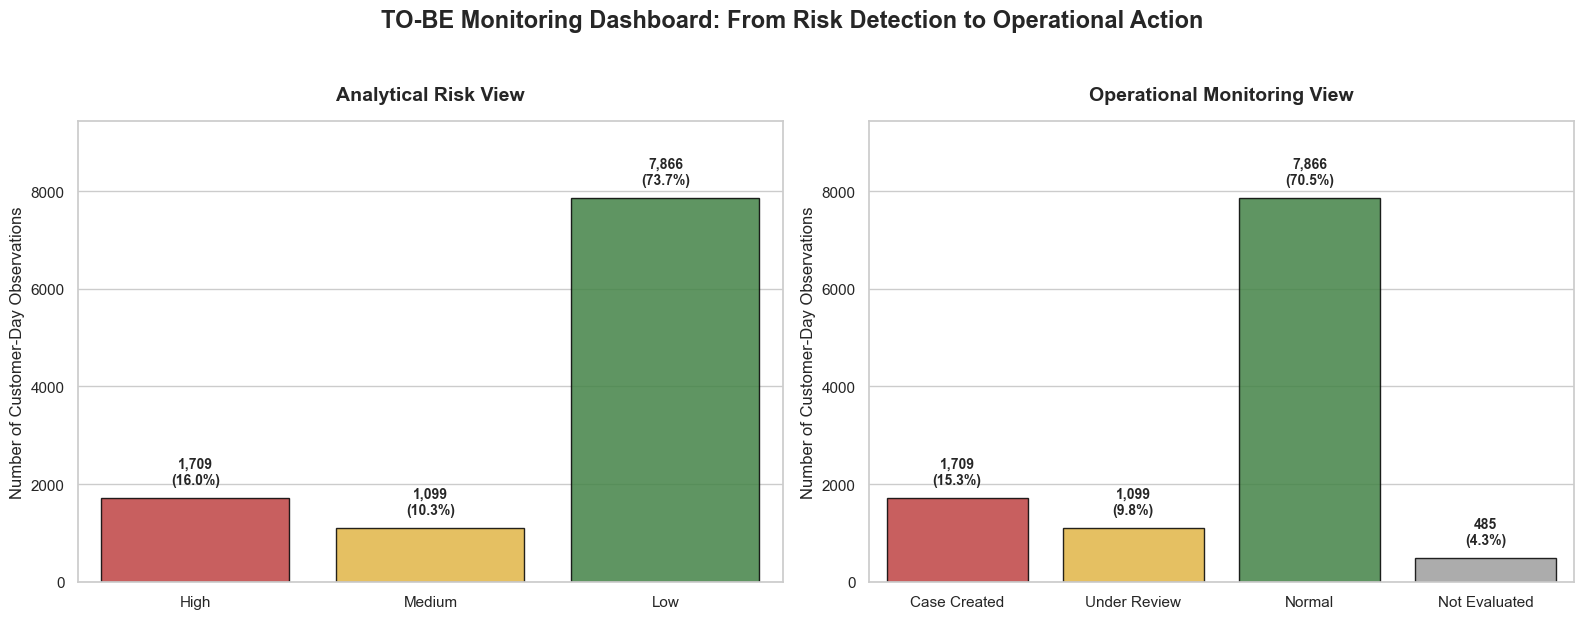


----- ANALYTICAL RISK VIEW -----
  suspiciousness_label  total_alerts  cases_created  case_rate  share_of_total
0                 High          1709           1709        1.0        0.153150
2               Medium          1099              0        0.0        0.098486
1                  Low          7866              0        0.0        0.704902

----- OPERATIONAL MONITORING VIEW -----
  monitoring_status  count  share_of_total
1      Case Created   1709        0.153150
2      Under Review   1099        0.098486
0            Normal   7866        0.704902
3     Not Evaluated    485        0.043463


In [34]:
# TO-BE SUSPICIOUS TRANSACTION MONITORING DASHBOARD

sns.set_theme(style="whitegrid")

# build summary table

total_n = len(tobe_customer_day_case_registry)

# Analytical risk view
risk_summary = (
    tobe_customer_day_case_registry
    .groupby("suspiciousness_label", dropna=False)["is_case_created"]
    .agg(total_alerts="count", cases_created="sum")
    .reset_index()
)

risk_summary["case_rate"] = risk_summary["cases_created"] / risk_summary["total_alerts"]
risk_summary["share_of_total"] = risk_summary["total_alerts"] / total_n

# Drop NaN suspiciousness if you only want evaluated categories
risk_summary = risk_summary[risk_summary["suspiciousness_label"].notna()].copy()

# Use a unified count column for plotting
risk_summary["count"] = risk_summary["total_alerts"]

# Operational monitoring view
status_summary = (
    tobe_customer_day_case_registry["monitoring_status"]
    .value_counts(dropna=False)
    .rename_axis("monitoring_status")
    .reset_index(name="count")
)

status_summary["share_of_total"] = status_summary["count"] / total_n

# set display order
risk_order = ["High", "Medium", "Low"]
status_order = ["Case Created", "Under Review", "Normal", "Not Evaluated"]

risk_summary["suspiciousness_label"] = pd.Categorical(
    risk_summary["suspiciousness_label"],
    categories=risk_order,
    ordered=True
)
risk_summary = risk_summary.sort_values("suspiciousness_label")

status_summary["monitoring_status"] = pd.Categorical(
    status_summary["monitoring_status"],
    categories=status_order,
    ordered=True
)
status_summary = status_summary.sort_values("monitoring_status")

# color map

full_palette = {
    "High": "#d32f2f",
    "Medium": "#fbc02d",
    "Low": "#388e3c",
    "Case Created": "#d32f2f",
    "Under Review": "#fbc02d",
    "Normal": "#388e3c",
    "Not Evaluated": "#9e9e9e"
}

# Plot dashboard

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# LEFT: Analytical Risk View
sns.barplot(
    data=risk_summary,
    x="suspiciousness_label",
    y="count",
    hue="suspiciousness_label",
    palette=full_palette,
    legend=False,
    edgecolor="black",
    alpha=0.85,
    ax=axes[0]
)

axes[0].set_title("Analytical Risk View", fontsize=14, fontweight="bold", pad=15)
axes[0].set_xlabel("")
axes[0].set_ylabel("Number of Customer-Day Observations")

for p in axes[0].patches:
    h = p.get_height()
    if h > 0:
        pct = f"{(h / risk_summary['count'].sum() * 100):.1f}%"
        axes[0].annotate(
            f"{int(h):,}\n({pct})",
            (p.get_x() + p.get_width() / 2, h),
            ha="center",
            va="bottom",
            fontsize=10,
            fontweight="bold",
            xytext=(0, 8),
            textcoords="offset points"
        )

# RIGHT: Operational Monitoring View
sns.barplot(
    data=status_summary,
    x="monitoring_status",
    y="count",
    hue="monitoring_status",
    palette=full_palette,
    legend=False,
    edgecolor="black",
    alpha=0.85,
    ax=axes[1]
)

axes[1].set_title("Operational Monitoring View", fontsize=14, fontweight="bold", pad=15)
axes[1].set_xlabel("")
axes[1].set_ylabel("Number of Customer-Day Observations")

for p in axes[1].patches:
    h = p.get_height()
    if h > 0:
        pct = f"{(h / status_summary['count'].sum() * 100):.1f}%"
        axes[1].annotate(
            f"{int(h):,}\n({pct})",
            (p.get_x() + p.get_width() / 2, h),
            ha="center",
            va="bottom",
            fontsize=10,
            fontweight="bold",
            xytext=(0, 8),
            textcoords="offset points"
        )

# Global formatting
plt.suptitle(
    "TO-BE Monitoring Dashboard: From Risk Detection to Operational Action",
    fontsize=17,
    fontweight="bold",
    y=1.03
)

axes[0].set_ylim(0, risk_summary["count"].max() * 1.2)
axes[1].set_ylim(0, status_summary["count"].max() * 1.2)

plt.tight_layout()
plt.show()


# print result
print("\n\033[1m----- ANALYTICAL RISK VIEW -----\033[0m")
print(risk_summary[["suspiciousness_label", "total_alerts", "cases_created", "case_rate", "share_of_total"]])

print("\n\033[1m----- OPERATIONAL MONITORING VIEW -----\033[0m")
print(status_summary[["monitoring_status", "count", "share_of_total"]])


---
### **Dashboard Intepretation**

---

The dashboard combines the analytical distribution of suspiciousness levels with their operational handling outcomes. 

> *High-risk observations are converted into formal cases, medium-risk observations remain under closer monitoring without case creation, and most low-risk observations are filtered as normal.*

A small proportion remains not evaluated due to insufficient baseline history. This shows that the TO-BE workflow applies structured triage logic while enabling direct data access and `seamless drill-down capabilities`, **supporting more efficient and timely investigation.**

---
### **S3 — 1.3.2.7 Data Processing: Conditional Drill-Down Mechanism — SELF-SERVE (No IT Request)**
---
***Output:** `tobe_transactions_case_view` and `tobe_ops_reviewed`*

After case registration, Business Operations filters escalated cases for deeper review. These cases then enter a self-serve drill-down stage, where transaction-level details are directly retrieved from the shared synthetic dataset without IT involvement.

<div style="background-color: #ffffff; border-left: 8px solid #007bff; padding: 25px; border-radius: 12px; font-family: 'Segoe UI', Arial, sans-serif; box-shadow: 0 4px 12px rgba(0,0,0,0.08); max-width: 800px;">
    <div style="display: flex; align-items: center; justify-content: space-between; margin-bottom: 20px; border-bottom: 1px solid #eee; padding-bottom: 15px;">
        <div style="display: flex; align-items: center;">
            <span style="font-size: 1.5em; margin-right: 12px;">🚀</span>
            <strong style="color: #0056b3; font-size: 1.2em; letter-spacing: 0.5px;">PROCESS TRANSFORMATION</strong>
        </div>
        <div style="background: #007bff; color: white; padding: 5px 15px; border-radius: 50px; font-size: 0.85em; font-weight: bold; box-shadow: 0 2px 4px rgba(0,123,255,0.3);">
            IT Requests: 0
        </div>
    </div>
    <div style="margin-bottom: 20px;">
        <div style="margin-bottom: 15px; display: flex; align-items: flex-start;">
            <span style="background: #fee2e2; color: #b91c1c; padding: 2px 10px; border-radius: 4px; font-weight: bold; font-size: 0.8em; margin-right: 15px; min-width: 50px; text-align: center;">AS-IS</span>
            <span style="color: #4b5563; font-size: 0.95em;">Dependency on <b>IT requests</b> for data details <span style="color: #9ca3af;">➔</span> <i style="color: #dc2626;">Bottlenecks & PII exposure risks.</i></span>
        </div>
        <div style="display: flex; align-items: flex-start;">
            <span style="background: #dcfce7; color: #15803d; padding: 2px 10px; border-radius: 4px; font-weight: bold; font-size: 0.8em; margin-right: 15px; min-width: 50px; text-align: center;">TO-BE</span>
            <span style="color: #1f2937; font-size: 0.95em;">Business Ops self-serves via <code style="color: #0369a1; background: #f0f9ff; padding: 2px 6px; border-radius: 4px; font-family: monospace;">synthetic_transactions</code> & <code style="color: #0369a1; background: #f0f9ff; padding: 2px 6px; border-radius: 4px; font-family: monospace;">pseudo_key</code>.</span>
        </div>
    </div>
    <div style="background: #f8fafc; border-top: 2px solid #e2e8f0; padding: 12px; border-radius: 0 0 8px 8px; margin: 10px -25px -25px -25px;">
        <p style="margin: 0; padding-left: 25px; color: #64748b; font-size: 0.85em; font-style: italic;">
            🎯 <b>Outcome:</b> Only escalated cases enter this stage, ensuring investigative resources are focused 100% on high-risk observations.
        </p>
    </div>
</div>

In [35]:
tobe_ops_reviewed = tobe_ops_case_log[tobe_ops_case_log["ops_disposition"] == "Escalate"].copy()

print(f'Escalated cases       : {len(tobe_ops_reviewed):,}')
print(f'IT requests required  : 0  <-- TO-BE advantage vs AS-IS')
print()

# Self-serve drill-down — direct join, no IT request
tobe_ops_reviewed["date"] = pd.to_datetime(tobe_ops_reviewed["date"]).dt.date
syn_trx_join = syn_trx.copy()
syn_trx_join["date"] = pd.to_datetime(syn_trx_join["date"]).dt.date

tobe_transactions_case_view = syn_trx_join.merge(
    tobe_ops_reviewed[["case_id", "pseudo_customer_key", "date",
                        "suspiciousness_label", "ops_disposition"]],
    on=["pseudo_customer_key", "date"],
    how="inner"
)

print(f'Transaction records for escalated cases: {len(tobe_transactions_case_view):,}')
print(f'Self-serve — no PII exposed, no IT request')
tobe_transactions_case_view.head()
print(f'Shape       : {tobe_transactions_case_view.shape}')

Escalated cases       : 1,709
IT requests required  : 0  <-- TO-BE advantage vs AS-IS

Transaction records for escalated cases: 4,343
Self-serve — no PII exposed, no IT request
Shape       : (4343, 20)


---
### **S3 — 1.3.2.8 Data Processing: Business Operations Review Metrics**
---

***Output:** `escalation rate`, `amplification ratio`, `IT requests required`, `PII rows exposed`*


The TO-BE design enables immediate transition from case-level detection to transaction-level investigation without dependency on IT, significantly reducing latency and eliminating PII exposure risks.


#### **Operational Effectiveness Metrics**

$$Escalation\ Rate = \frac{Escalated\ Cases}{Total\ Cases}$$

$$Escalation\ Amplification\ Ratio = \frac{\sum Transaction\ Records}{\sum Escalated\ Cases}$$




<div style="background-color: #fff9f2; border-left: 6px solid #e67e22; padding: 18px; border-radius: 8px; font-family: 'Segoe UI', Roboto, sans-serif; box-shadow: 0 1px 3px rgba(0,0,0,0.05);">
    <div style="display: flex; align-items: center; margin-bottom: 12px;">
        <span style="font-size: 1.4em; margin-right: 12px; line-height: 1;">📉</span>
        <strong style="color: #a04000; font-size: 1.1em; letter-spacing: 0.3px;">OPERATIONAL EFFICIENCY METRICS</strong>
    </div>
    <p style="margin: 0; color: #5e3500; line-height: 1.6;">
        To evaluate process performance, key metrics such as <b>Escalation Rate</b> and <b>Amplification Ratio</b> are monitored. These indicators provide a data-driven assessment of how efficiently Business Operations translates high-level <b>case signals</b> into actionable <b>transaction-level investigations</b>.
    </p>
</div>

---
---


In [36]:
# Escalation metrics
tobe_num_escalated   = tobe_ops_reviewed["case_id"].nunique()
tobe_total_cases     = tobe_ops_case_log["case_id"].nunique()
tobe_escalation_rate = tobe_num_escalated / tobe_total_cases if tobe_total_cases > 0 else 0
tobe_amplification   = len(tobe_transactions_case_view) / tobe_num_escalated if tobe_num_escalated > 0 else 0

print(f'Total cases           : {tobe_total_cases:,}')
print(f'Escalated cases       : {tobe_num_escalated:,}')
print(f'Escalation rate       : {tobe_escalation_rate:.4f} ({tobe_escalation_rate*100:.2f}%)')
print(f'Amplification ratio   : {tobe_amplification:.2f}')
print(f'IT requests required  : 0')
print(f'PII rows exposed      : 0')


Total cases           : 1,709
Escalated cases       : 1,709
Escalation rate       : 1.0000 (100.00%)
Amplification ratio   : 2.54
IT requests required  : 0
PII rows exposed      : 0


---
## **S3 — 1.3.3 Output Data — 1LoD Business Operations**

*This section presents the datasets generated by Business Operations as outputs of the monitoring and decision-making process. These outputs represent structured artefacts used for case management, investigation support, and audit traceability.*

**Primary Output:**
*This dataset serves as the central reference for case management and downstream investigation.*

1. `tobe_ops_case_log` — capturing the outcome of the monitoring process, including suspiciousness classification, operational disposition, and documented decision rationale (***non-escalate excluded***).
2. `tobe_ops_log` — capturing the outcome of the monitoring process, including suspiciousness classification, operational disposition, and documented decision rationale. (***all dataset***)

**Supporting Output:**
*supporting datasets are generated to enable monitoring traceability, investigation, and analytical reporting*

1. `customer_day_case_registry` — Links monitoring observations (customer-day level) with case creation outcomes, enabling traceability between detection and action.
2. `tobe_ops_reviewed` — Subset of cases selected for in-depth investigation based on escalation decisions.
3. `tobe_transaction_case_view` — Transaction-level dataset containing only escalated cases, used for detailed operational investigation (drill-down).
4. `dashboard_summary`— Aggregated metrics and summaries used for monitoring performance and operational insights.
5. `tobe_transactions_case_linked` — A transaction-level dataset linking all transactions to their corresponding case outcomes (if any), including suspiciousness classification and operational disposition.


---
### **S3 — 1.3.3.1 Data Output: Documentation For Audit Trail (Case - Transaction Linked)**
---
**Output:** `tobe_transactions_case_linked`

*Unlike the drill-down dataset used for investigation, this This dataset provides a transaction-level linkage to case records, enabling end-to-end audit traceability across all monitored observations.*

---


In [37]:
# Documentation for audit trail — synthetic transaction linked
tobe_ops_case_log["date"]    = pd.to_datetime(tobe_ops_case_log["date"]).dt.date
syn_trx_join["date"]         = pd.to_datetime(syn_trx_join["date"]).dt.date

tobe_transactions_case_linked = syn_trx_join.merge(
    tobe_ops_case_log[["case_id", "pseudo_customer_key", "date",
                        "suspiciousness_label", "ops_disposition"]],
    on=["pseudo_customer_key", "date"],
    how="left"
)


print("\n\033[1m----- FULL CUSTOMER TRANSACTION CASE LINKED DATASET -----\033[0m")

print(f'Transactions case linked: {tobe_transactions_case_linked.shape}')
print()
print('Transactions case linked:')
print(tobe_transactions_case_linked.columns.tolist())

display(tobe_transactions_case_linked.head())




----- FULL CUSTOMER TRANSACTION CASE LINKED DATASET -----
Transactions case linked: (16797, 20)

Transactions case linked:
['txn_id', 'pseudo_customer_key', 'channel', 'd_c', 'trx_ccy', 'amount_eur', 'amount_orig', 'mcc', 'merchant_country', 'txn_year', 'txn_month', 'day_in_month', 'weekday_num', 'quarter', 'is_month_end', 'txn_hour', 'date', 'case_id', 'suspiciousness_label', 'ops_disposition']


,txn_id,pseudo_customer_key,channel,d_c,trx_ccy,amount_eur,amount_orig,mcc,merchant_country,txn_year,txn_month,day_in_month,weekday_num,quarter,is_month_end,txn_hour,date,case_id,suspiciousness_label,ops_disposition
0,SYN_TXN_00000000,SYN_C_000001,card,D,EUR,2.36,2.36,7999.0,CH,2024,12,1,6,4,0,23,2024-12-01,NaN,NaN,NaN
1,SYN_TXN_00000001,SYN_C_000001,card,D,EUR,10.22,10.58,5814.0,EE,2024,5,18,5,2,0,14,2024-05-18,NaN,NaN,NaN
2,SYN_TXN_00000002,SYN_C_000001,online,C,EUR,392.60,367.53,NaN,EE,2024,6,23,6,2,0,18,2024-06-23,CASE_SYN_C_000001_20240623,High,Escalate
3,SYN_TXN_00000003,SYN_C_000001,mobile,C,EUR,21.94,21.51,NaN,EE,2024,7,18,3,3,0,12,2024-07-18,NaN,NaN,NaN
4,SYN_TXN_00000004,SYN_C_000001,online,C,EUR,2502.67,3252.47,NaN,EE,2024,8,21,2,3,0,23,2024-08-21,CASE_SYN_C_000001_20240821,High,Escalate


In [38]:
print("\033[1m----- TO-BE BUSINESS OPERATIONS OUTPUT (ALL OUTPUT)-----\033[0m")

print(f'tobe_ops_log: {tobe_ops_log.shape}')
print(f'tobe_ops_case_log: {tobe_ops_case_log.shape}')
print(f'tobe_transactions_case_linked: {tobe_transactions_case_linked.shape}')
print(f'tobe_transactions_case_view: {tobe_transactions_case_view.shape}')
print(f'tobe_customer_day_registry: {tobe_customer_day_case_registry.shape}')
print(f'tobe_ops_reviewed: {tobe_ops_reviewed.shape}')
print(f'dashboard_summary: {dashboard_summary.shape}')

----- TO-BE BUSINESS OPERATIONS OUTPUT (ALL OUTPUT)-----
tobe_ops_log: (11159, 10)
tobe_ops_case_log: (1709, 12)
tobe_transactions_case_linked: (16797, 20)
tobe_transactions_case_view: (4343, 20)
tobe_customer_day_registry: (11159, 25)
tobe_ops_reviewed: (1709, 12)
dashboard_summary: (7, 4)


### **S3 — 1.3.3.2 Business Ops Output Dataset**

| Feature                           | AS-IS Business Ops            | TO-BE Business Ops                     |
| --------------------------------- | ----------------------------- | -------------------------------------- |
| **Data Access for Investigation** | Requires IT request           | Direct self-serve access               |
| **Escalation Handling**           | Triggers data request & delay | Immediate investigation                |
| **IT Dependency**                 | ***Yes***                     | ***No***                               |
| **PII Exposure**                  | ***Yes*** (raw data required) | ***No*** (synthetic only)              |
| **Escalation Rate**               | Variable                      | ***100%*** (case log = escalated only) |
| **Amplification Ratio**           | Delayed / partial             | ***2.54***                             |
| **Transaction Traceability**      | Indirect                      | Direct via linked datasets             |
| **Operational Latency**           | High (queue-based)            | ***Zero***                             |
| **Data Coverage**                 | Partial                       | Full linkage                           |
| **Output Structure**              | Limited case records          | Multi-layer dataset ecosystem          |


### **S3 — 1.3.3.3 Business Ops Transformation Output**

***`Synthetic Golden Source --> Business Operations (Role-Based & Decision Transformation)`***

| Dimension                 | Golden Source Input (`syn_customer_day`) | Business Ops Output (`tobe_ops_case_log`) | Change            |
| ------------------------- | ---------------------------------------- | ----------------------------------------- | ----------------- |
| **Granularity**           | Customer-day (analytical signals)        | Customer-day (case-level decisions)       | Maintained        |
| **Access**                | Shared across all lines                  | Shared across all lines                   | Maintained        |
| **IT Request**            | None                                     | None                                      | Maintained at 0   |
| **Drill-down Capability** | Direct transaction linkage available     | Self-serve investigation enabled          | No request needed |
| **Decision Layer**        | Not present (signals only)               | Added (label, disposition, rules)         | Signal → Action   |
| **Latency**               | Immediate access                         | Immediate decision                        | No waiting time   |


### **S3 — 1.3.3.4 Data Dimension Gap: IT vs DataOps vs BusinessOps(TO-BE Golden Source)**

| Dimension           | IT (Raw Transaction Layer)   | DataOps (`syn_customer_day`)              | Business Ops (`tobe_ops_case_log`)           | Transformation                |
| ------------------- | ---------------------------- | ----------------------------------------- | -------------------------------------------- | ----------------------------- |
| **Granularity**     | Transaction-level            | Customer-day aggregation                  | Customer-day (case-level decisions)          | Event → Aggregated → Decision |
| **Data Structure**  | Flat transactional records   | Behavioral indicators (ratios, baselines) | Decision records (label, disposition, rules) | Data → Signal → Action        |
| **Temporal Detail** | Full timestamp (date + time) | Daily aggregation                         | Daily (case reference)                       | Temporal abstraction          |
| **Feature Type**    | Raw attributes               | Analytical features                       | Decision attributes                          | Raw → Analytical → Decision   |
| **Dependency**      | Independent records          | Interdependent features                   | Signal-dependent decisions                   | Structured dependency         |
| **Traceability**    | Direct                       | Linked (via key + date)                   | Fully traceable via case_id                  | Traceable across layers       |
| **PII Exposure**    | Full (IBAN, client_id)       | None (pseudo_customer_key)                | None                                         | Privacy preserved             |
| **Data Fidelity**   | Exact real data              | Synthetic (distribution-preserving)       | Derived from synthetic                       | Controlled approximation      |
| **Join Capability** | Limited                      | Fully joinable                            | Fully joinable                               | Interoperability enabled      |
| **Accessibility**   | Restricted                   | Shared                                    | Shared                                       | Democratized                  |




<div style="background-color: #f8fafc; border-left: 6px solid #475569; padding: 20px; border-radius: 10px; font-family: 'Segoe UI', Roboto, sans-serif; box-shadow: 0 2px 4px rgba(0,0,0,0.05);">
    <div style="display: flex; align-items: center; margin-bottom: 15px;">
        <span style="font-size: 1.5em; margin-right: 12px; line-height: 1;">📐</span>
        <strong style="color: #1e293b; font-size: 1.1em; letter-spacing: 0.3px;">STRUCTURAL BALANCING</strong>
    </div>
    <div style="color: #334155; line-height: 1.6;">
        <p style="margin: 0 0 15px 0; font-size: 0.95em;">
            The TO-BE model introduces a layered transformation from raw data to analytical signals and finally to operational decisions. While granularity and direct traceability are reduced at higher layers, the model compensates through:
        </p>
        <div style="display: grid; grid-template-columns: 1fr 1fr; gap: 15px;">
            <div style="background: #ffffff; padding: 12px; border-radius: 6px; border: 1px solid #e2e8f0;">
                <b style="color: #0f172a; font-size: 0.85em; display: block; margin-bottom: 5px;">Linkage Mechanisms</b>
                <span style="font-size: 0.85em; color: #64748b;">Ensuring that <b>auditability</b> and <b>analytical validity</b> are preserved.</span>
            </div>
            <div style="background: #ffffff; padding: 12px; border-radius: 6px; border: 1px solid #e2e8f0;">
                <b style="color: #0f172a; font-size: 0.85em; display: block; margin-bottom: 5px;">Self-Serve Drill-Down</b>
                <span style="font-size: 0.85em; color: #64748b;">Enabling depth without exposing <b>sensitive data</b>.</span>
            </div>
        </div>
    </div>
</div>

---
# **SECTION 4 — THE SECOND LINE OF DEFENCE (RISK MANAGEMENT & COMPLIANCE) (2LoD)**
---
---



```mermaid
flowchart TD
    %% GOLDEN SOURCE (THE ENGINE)
    subgraph GoldenSource [Data Operations - 1st Line]
        A[("The Golden Source\nsynthetic_customer_day")]
    end

    %% THE SECOND LINE OF DEFENSE (2nd LINE)
    subgraph Silo2LOD [THE SECOND LINE OF DEFENSE]

        %% COMPLIANCE DEPT
        subgraph ComplianceDept [Compliance Department]
            I1[Independent Review: Case Verification] --> K[Quality Assurance Check]
            K --> M[Output: STR Assessment & KYC Review]
        end

        %% RISK MANAGEMENT DEPT
        subgraph RiskDept [Risk Management Department]
            I2[Independent Review: Model Validation] --> L[Loss Impact Analysis]
            L --> N[Output: Risk Assessment Matrix]
        end
    end

    %% DIRECT ACCESS — NO REQUEST DRAMA
    A ==>|Direct Access\nNo IT Request| I1
    A ==>|Direct Access\nNo IT Request| I2

    %% EXCEPTION PATH
    I1 & I2 -.->|Formal Evidence Request Only| RealData[(Real PII Data)]

    %% SHARED OUTPUTS
    M & N --> Dashboard[[Shared Risk & Compliance Dashboard]]

    %% Styling
    style GoldenSource fill:#e3f2fd,stroke:#1565c2,stroke-width:2px
    style A fill:#fff9c4,stroke:#fbc02d,stroke-width:3px
    style Silo2LOD fill:#f1f8e9,stroke:#33691e,stroke-width:2px
    style RealData fill:#eeeeee,stroke:#999,stroke-dasharray:5 5
```



---
# **S4 — 1.1 — 2LoD: Risk Management Department (Independent Oversight)**
***Input:** `tobe_ops_log`, dan `tobe_ops_case_log` — Operational outputs from Business* Operations


## **2LoD — Risk Management Department**
                            
| Component          | Description                                                                                                         |
| ------------------ | ------------------------------------------------------------------------------------------------------------------- |
| **Role**           | Risk Management (Oversight Layer — Aggregate Monitoring, Validation, and Risk Assessment)                           |
| **Input**          | `tobe_ops_df`, `tobe_transactions_case_view`                                                                        |
| **Output**         | `tobe_risk_dashboard` — monthly oversight metrics and escalation trend view                                         |
| **Granularity**    | Aggregated monthly oversight level                                                                                  |
| **Fields**         | Escalation counts, severity distribution, escalation rate, amplification ratio, stability index                     |
| **Processing**     | Population aggregation, escalation pattern analysis, amplification measurement, and escalation stability monitoring |
| **Purpose**        | Assess operational risk patterns, validate escalation behavior, and monitor trend consistency over time             |
| **Key Difference** | Direct analytical access to full monitoring outputs without IT-mediated data provisioning                           |



---

*The Risk Management function operates independently from Business Operations, focusing on validation, monitoring, and oversight rather than executing operational decisions.*

The TO-BE design enables Risk Management to independently validate monitoring logic and systemic risk patterns directly from the synthetic Golden Source, eliminating dependency on IT-mediated data access. Additionally strengthens governance by enabling real-time oversight while maintaining strict separation between operational execution (1LoD) and independent validation (2LoD).


In the TO-BE setting, Risk Management performs aggregate oversight using the full monitoring dataset and linked escalated transaction view. The process includes monthly aggregation of suspiciousness labels and escalation outcomes, construction of key oversight metrics, and monitoring of trend stability across time. The resulting output is summarized in the tobe_risk_dashboard.

## **Risk Management 2nd Line (Independent Review Process)**

```mermaid
flowchart LR
    %% 1. INPUT PHASE — DIRECT ACCESS
    subgraph DirectAccess [Direct Access - No Request Needed]
        R1[Synthetic Golden Source\nAll distributions & thresholds]
        R2[Historical Trend Data\nFrom synthetic_customer_day]
        R3[Ops Log & Case Log\ntobe_ops_case_log]
    end

    %% 2. INTERNAL PROCESS
    subgraph Risk_Internal [2nd Line: Risk Management Independent Review]
        direction TB
        R1 --> P1[Model Validation &\nSensitivity Test]
        R2 --> P2[Systemic Risk Monitoring\n& Stability Analysis]
        R3 --> P3[Control Oversight &\nOps Validation]

        P1 & P2 & P3 --> P4{Risk Evaluation\n& Decision}
    end

    %% 3. OUTPUT PHASE
    subgraph Output_Phase [Risk Management Deliverables]
        direction LR
        P4 --> O1[Threshold Calibration Memo]
        P4 --> O2[Systemic Risk Matrix]
        P4 --> O3[Control Effectiveness Scorecard]
    end

    subgraph Audit_Trail [Risk Management Storage]
        O1 & O2 & O3 --> AT_Risk[(tobe_risk_dashboard)]
    end

    AT_Risk --> Dash{Risk Dashboard}

    %% Styling
    style DirectAccess fill:#e8f5e9,stroke:#2e7d32,stroke-width:2px
    style Risk_Internal fill:#fff3e0,stroke:#e65100,stroke-width:2px
    style AT_Risk fill:#f3e5f5,stroke:#4a148c,stroke-width:2px
```

---

<div style="background-color: #f8fafc; border-left: 6px solid #334155; padding: 20px; border-radius: 10px; font-family: 'Segoe UI', Roboto, sans-serif; box-shadow: 0 2px 4px rgba(0,0,0,0.05);">
    <div style="display: flex; align-items: center; justify-content: space-between; margin-bottom: 15px;">
        <div style="display: flex; align-items: center;">
            <span style="font-size: 1.3em; margin-right: 12px;">🛡️</span>
            <strong style="color: #0f172a; font-size: 1.1em; letter-spacing: 0.5px;">INDEPENDENT RISK VALIDATION</strong>
        </div>
        <div style="background: #e2e8f0; color: #475569; padding: 4px 12px; border-radius: 20px; font-size: 0.8em; font-weight: bold; white-space: nowrap;">
            2LoD Direct Access
        </div>
    </div>
    <div style="color: #334155; line-height: 1.6;">
        <p style="margin: 0 0 10px 0; font-size: 0.95em;">
            <b>Key difference from AS-IS:</b> Risk Management now operates on a <b>Self-Serve</b> basis.
        </p>
        <div style="background: #ffffff; border: 1px solid #e2e8f0; padding: 12px; border-radius: 6px;">
            <span style="font-size: 0.9em; display: block; margin-bottom: 4px;">
                Validation is performed directly on the <b>Synthetic Golden Source</b>, eliminating IT-mediated data requests.
            </span>
            <span style="font-size: 0.85em; color: #64748b; font-style: italic;">
                ➔ Enables immediate cross-functional analysis while maintaining 100% data privacy.
            </span>
        </div>
    </div>
</div>

---



## **S4 — 1.1.1 — Input Dataset**

**input:** `tobe_ops_df` (primary), `tobe_ops_case_log` (supporting)

* `tobe_ops_df` — full operational monitoring dataset used for monthly risk trend analysis, escalation patterns, and oversight across evaluated observations.
* `tobe_ops_case_log` — formal case-level dataset used to review escalated outcomes, case volume, and documented rationale.

In [39]:
print("\033[1m----- TO-BE RISK MANAGEMENT INPUT -----\n\033[0m")

# PRIMARY INPUT
print('\n\033[1m ---------- [PRIMARY] tobe_ops_df (Full Monitoring Dataset): ----------\033[0m')
print(f'  Shape  : {tobe_ops_df.shape}')
print(f'  Columns: {tobe_ops_df.columns.tolist()}')
print(f'  Evaluated rows: {tobe_ops_df["is_evaluated"].sum():,}')
print()

display(tobe_ops_df.head(5))


# SUPPORTING INPUT
print('\n\033[1m ---------- [SUPPORTING] tobe_ops_case_log (Formal Case Log): ----------\n\033[0m')
print(f'  Shape  : {tobe_ops_case_log.shape}')
print(f'  Columns: {tobe_ops_case_log.columns.tolist()}')
print(f'  Unique cases: {tobe_ops_case_log["case_id"].nunique():,}')
print()

display(tobe_ops_case_log.head(5))

----- TO-BE RISK MANAGEMENT INPUT -----


 ---------- [PRIMARY] tobe_ops_df (Full Monitoring Dataset): ----------
  Shape  : (11159, 21)
  Columns: ['pseudo_customer_key', 'date', 'daily_txn_count', 'daily_total_amount', 'daily_avg_amount', 'age', 'tenure_years', 'gender_cd', 'lang_pref', 'baseline_txn_count', 'baseline_total_amount', 'baseline_avg_amount', 'ratio_velocity', 'ratio_value', 'velocity_severity', 'value_severity', 'auto_red_flag', 'is_evaluated', 'suspiciousness_label', 'ops_disposition', 'ops_rules']
  Evaluated rows: 10,674



,pseudo_customer_key,date,daily_txn_count,daily_total_amount,daily_avg_amount,age,tenure_years,gender_cd,lang_pref,baseline_txn_count,...,baseline_avg_amount,ratio_velocity,ratio_value,velocity_severity,value_severity,auto_red_flag,is_evaluated,suspiciousness_label,ops_disposition,ops_rules
0,SYN_C_000001,2024-02-06,1,10.10,10.10,82,1,M,EE,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,Not evaluated (baseline not ready)
1,SYN_C_000001,2024-02-11,2,112.11,56.06,82,1,M,EE,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,Not evaluated (baseline not ready)
2,SYN_C_000001,2024-02-20,1,19.33,19.33,82,1,M,EE,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,Not evaluated (baseline not ready)
3,SYN_C_000001,2024-02-27,1,13.19,13.19,82,1,M,EE,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,Not evaluated (baseline not ready)
4,SYN_C_000001,2024-03-02,1,53.31,53.31,82,1,M,EE,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,Not evaluated (baseline not ready)



 ---------- [SUPPORTING] tobe_ops_case_log (Formal Case Log): ----------

  Shape  : (1709, 12)
  Columns: ['case_id', 'case_created_at', 'pseudo_customer_key', 'date', 'suspiciousness_label', 'ops_disposition', 'ratio_velocity', 'ratio_value', 'velocity_severity', 'value_severity', 'auto_red_flag', 'ops_rules']
  Unique cases: 1,709



,case_id,case_created_at,pseudo_customer_key,date,suspiciousness_label,ops_disposition,ratio_velocity,ratio_value,velocity_severity,value_severity,auto_red_flag,ops_rules
5,CASE_SYN_C_000001_20240310,2026-05-15 13:39:27.836025,SYN_C_000001,2024-03-10,High,Escalate,1.6667,4.8356,Elevated,Significant,1.0,auto_red_flag=1 (Significant severity triggere...
9,CASE_SYN_C_000001_20240328,2026-05-15 13:39:27.836025,SYN_C_000001,2024-03-28,High,Escalate,0.8182,6.5256,Normal,Significant,1.0,auto_red_flag=1 (Significant severity triggere...
11,CASE_SYN_C_000001_20240505,2026-05-15 13:39:27.836025,SYN_C_000001,2024-05-05,High,Escalate,2.5385,0.7895,Significant,Normal,1.0,auto_red_flag=1 (Significant severity triggere...
15,CASE_SYN_C_000001_20240623,2026-05-15 13:39:27.836025,SYN_C_000001,2024-06-23,High,Escalate,0.7895,5.7669,Normal,Significant,1.0,auto_red_flag=1 (Significant severity triggere...
19,CASE_SYN_C_000001_20240726,2026-05-15 13:39:27.836025,SYN_C_000001,2024-07-26,High,Escalate,0.8261,6.3933,Normal,Significant,1.0,auto_red_flag=1 (Significant severity triggere...


*These structured outputs are then consumed by the Second Line of Defence for independent validation and oversight.*

## **S4 — 1.1.2 — Data Process: Risk Dashboard**

***Output:** `tobe_risk_dashboard`*

This dashboard use to monitor the customer activity

In [40]:
# Monthly aggregation — identical logic to AS-IS
# Use full monitoring dataset

tobe_ops_df["date"]  = pd.to_datetime(tobe_ops_df["date"])
tobe_ops_df["month"] = tobe_ops_df["date"].dt.to_period("M")

# Monthly aggregation (full oversight)
tobe_risk_dashboard = (
    tobe_ops_df
    .groupby("month")
    .agg(
        total_observations = ("pseudo_customer_key", "count"),
        evaluated_cases    = ("is_evaluated", "sum"),
        high_cases         = ("suspiciousness_label", lambda x: (x == "High").sum()),
        medium_cases       = ("suspiciousness_label", lambda x: (x == "Medium").sum()),
        low_cases          = ("suspiciousness_label", lambda x: (x == "Low").sum()),
        escalated_cases    = ("ops_disposition", lambda x: (x == "Escalate").sum())
    )
    .reset_index()
)

# Escalation rate (valid now)
tobe_risk_dashboard["escalation_rate"] = (
    tobe_risk_dashboard["escalated_cases"] /
    tobe_risk_dashboard["evaluated_cases"].replace(0, pd.NA)
)

# Amplification ratio (from drill-down dataset)
tobe_transactions_case_view["date"] = pd.to_datetime(tobe_transactions_case_view["date"])
tobe_transactions_case_view["month"] = tobe_transactions_case_view["date"].dt.to_period("M")

monthly_txn = (
    tobe_transactions_case_view
    .groupby("month")
    .size()
    .reset_index(name="txn_records_escalated")
)

tobe_risk_dashboard = tobe_risk_dashboard.merge(monthly_txn, on="month", how="left")

tobe_risk_dashboard["amplification_ratio"] = (
    tobe_risk_dashboard["txn_records_escalated"] /
    tobe_risk_dashboard["escalated_cases"].replace(0, pd.NA)
)

# Stability index
tobe_risk_dashboard = tobe_risk_dashboard.sort_values("month")
tobe_risk_dashboard["escalation_rate_prev"] = tobe_risk_dashboard["escalation_rate"].shift(1)

tobe_risk_dashboard["escalation_stability_index"] = (
    (tobe_risk_dashboard["escalation_rate"] - tobe_risk_dashboard["escalation_rate_prev"]).abs()
    / tobe_risk_dashboard["escalation_rate_prev"]
)

print("\n\033[1m ---------- TO-BE RISK DASHBOARD ----------\033[0m")

display(tobe_risk_dashboard.head(12))
print(f"\nShape: {tobe_risk_dashboard.shape}")


 ---------- TO-BE RISK DASHBOARD ----------


,month,total_observations,evaluated_cases,high_cases,medium_cases,low_cases,escalated_cases,escalation_rate,txn_records_escalated,amplification_ratio,escalation_rate_prev,escalation_stability_index
0,2024-01,957,527,109,45,373,109,0.206831,299,2.743119,NaN,NaN
1,2024-02,889,859,144,72,643,144,0.167637,305,2.118056,0.206831,0.189499
2,2024-03,820,812,116,76,620,116,0.142857,249,2.146552,0.167637,0.147817
3,2024-04,734,730,103,59,568,103,0.141096,208,2.019417,0.142857,0.012329
4,2024-05,1222,1218,237,161,820,237,0.194581,693,2.924051,0.141096,0.379071
5,2024-06,814,810,123,66,621,123,0.151852,241,1.959350,0.194581,0.219597
6,2024-07,776,775,93,75,607,93,0.120000,198,2.129032,0.151852,0.209756
7,2024-08,1217,1216,247,158,811,247,0.203125,772,3.125506,0.120000,0.692708
8,2024-09,754,753,82,60,611,82,0.108898,188,2.292683,0.203125,0.463888
9,2024-10,975,974,161,94,719,161,0.165298,411,2.552795,0.108898,0.517917



Shape: (12, 12)


### **S4 — 1.1.2.1 — Data Process: Sanity Check — TO-BE Risk Dashboard**

*To confirms dashboard is internally consistent, with all classification and escalation logic correctly aligned.*

In [41]:
print("\n\033[1m----- SANITY CHECK: TO-BE RISK DASHBOARD -----\033[0m\n")

# 1. Label consistency (High + Medium + Low = evaluated_cases)
label_cols = ["high_cases", "medium_cases", "low_cases"]
tobe_risk_dashboard["label_sum"] = tobe_risk_dashboard[label_cols].sum(axis=1)

print("Label sum == evaluated_cases:")
print((tobe_risk_dashboard["label_sum"] == tobe_risk_dashboard["evaluated_cases"]).value_counts())
print()

# 2. Escalation consistency (High == escalated_cases)
print("High cases == escalated_cases:")
print((tobe_risk_dashboard["high_cases"] == tobe_risk_dashboard["escalated_cases"]).value_counts())
print()

# 3. No division errors (check NaN / inf)
print("3. Check NaN in key metrics:")
print(tobe_risk_dashboard[[
    "escalation_rate",
    "amplification_ratio",
    "escalation_stability_index"
]].isna().sum())
print()

# 4. Amplification ratio sanity (should be >= 1)
print("Amplification ratio >= 1:")
print((tobe_risk_dashboard["amplification_ratio"] >= 1).value_counts())
print()

# 5. Escalation rate range (0–1)
print("Escalation rate within [0,1]:")
print(((tobe_risk_dashboard["escalation_rate"] >= 0) &
       (tobe_risk_dashboard["escalation_rate"] <= 1)).value_counts())
print()

# 6. Stability index interpretation check
print("Stability index (high volatility months):")
print(tobe_risk_dashboard[
    tobe_risk_dashboard["escalation_stability_index"] > 0.3
][["month", "escalation_stability_index"]])

print("\n\033[1m --- Result: ALL SANITY CHECKS PASSED ---\033[0m")


----- SANITY CHECK: TO-BE RISK DASHBOARD -----

Label sum == evaluated_cases:
True    12
Name: count, dtype: int64

High cases == escalated_cases:
True    12
Name: count, dtype: int64

3. Check NaN in key metrics:
escalation_rate               0
amplification_ratio           0
escalation_stability_index    1
dtype: int64

Amplification ratio >= 1:
amplification_ratio
True    12
Name: count, dtype: int64

Escalation rate within [0,1]:
escalation_rate
True    12
Name: count, dtype: int64

Stability index (high volatility months):
     month  escalation_stability_index
4  2024-05                    0.379071
7  2024-08                    0.692708
8  2024-09                    0.463888
9  2024-10                    0.517917

 --- Result: ALL SANITY CHECKS PASSED ---


<div style="background-color: #f0fdf4; border-left: 6px solid #22c55e; padding: 20px; border-radius: 10px; font-family: 'Segoe UI', Roboto, sans-serif; box-shadow: 0 2px 4px rgba(0,0,0,0.05);">
    <div style="display: flex; align-items: center; margin-bottom: 12px;">
        <span style="font-size: 1.5em; margin-right: 12px; line-height: 1;">✅</span>
        <strong style="color: #166534; font-size: 1.1em; letter-spacing: 0.3px;">SANITY CHECK VALIDATION</strong>
    </div>
    <div style="color: #1e293b; line-height: 1.6; font-size: 0.95em;">
        <p style="margin: 0 0 12px 0;">
            The sanity check confirms that the TO-BE risk dashboard is internally consistent, with all classification and escalation logic correctly aligned. Escalation rates and amplification ratios remain within valid ranges, indicating stable and reliable monitoring performance.
        </p>
        <p style="margin: 0;">
            Notable volatility in May, August, September, and October suggests periods of shifting risk behavior, demonstrating the dashboard’s ability to capture temporal instability.
        </p>
    </div>
</div>

### **S4 — 1.1.2.2 — Data Process: TO-BE Risk Dashboard (Monthly Escalation Trend)**

*To show monthly escalation trend including escalation rate within  months*

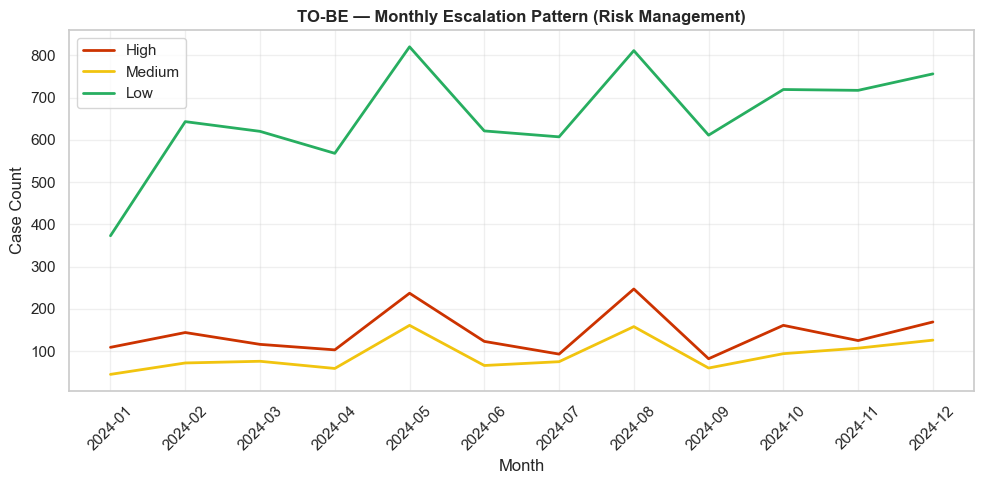

In [42]:
# Monthly escalation trend

plt.figure(figsize=(10, 5))

label_cols = ["high_cases", "medium_cases", "low_cases"]

colors_lbl = {
    "high_cases": "#cc3300",
    "medium_cases": "#f1c40f",
    "low_cases": "#27ae60"
}

label_names = {
    "high_cases": "High",
    "medium_cases": "Medium",
    "low_cases": "Low"
}

for label in label_cols:
    plt.plot(
        tobe_risk_dashboard["month"].astype(str),
        tobe_risk_dashboard[label],
        label=label_names[label],
        color=colors_lbl[label],
        linewidth=2
    )

plt.title("TO-BE — Monthly Escalation Pattern (Risk Management)", fontsize=12, fontweight="bold")
plt.xlabel("Month")
plt.ylabel("Case Count")
plt.legend()
plt.xticks(rotation=45)
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

<div style="background-color: #f8fafc; border-left: 6px solid #1e293b; padding: 20px; border-radius: 10px; font-family: 'Segoe UI', Roboto, sans-serif; box-shadow: 0 2px 4px rgba(0,0,0,0.05); max-width: 800px;">
    <div style="display: flex; align-items: center; margin-bottom: 12px;">
        <span style="font-size: 1.4em; margin-right: 12px; line-height: 1;">📊</span>
        <strong style="color: #0f172a; font-size: 1.1em; letter-spacing: 0.3px; text-transform: uppercase;">Monthly Trend Analysis</strong>
    </div>
    <div style="color: #334155; line-height: 1.6;">
        <p style="margin: 0; font-size: 0.95em;">
            Monthly TO-BE trends show <b>strong correlations</b> across all risk levels. 
            <b>High-risk cases drive escalation spikes</b>, while <b>Medium and Low categories provide</b> a comprehensive baseline for behavior across periods.
        </p>
    </div>
</div>

### **S4 — 1.1.2.3 — Data Process: TO-BE Risk Dashboard Demographic Cross Reference Across Suspicious Level**

*to analyst additional information, where Risk Management can directly integrate demographic attributes into risk evaluation in the TO-BE simulation* 

Such capability enhances contextual understanding of risk profiles and supports more informed validation and oversight decisions.

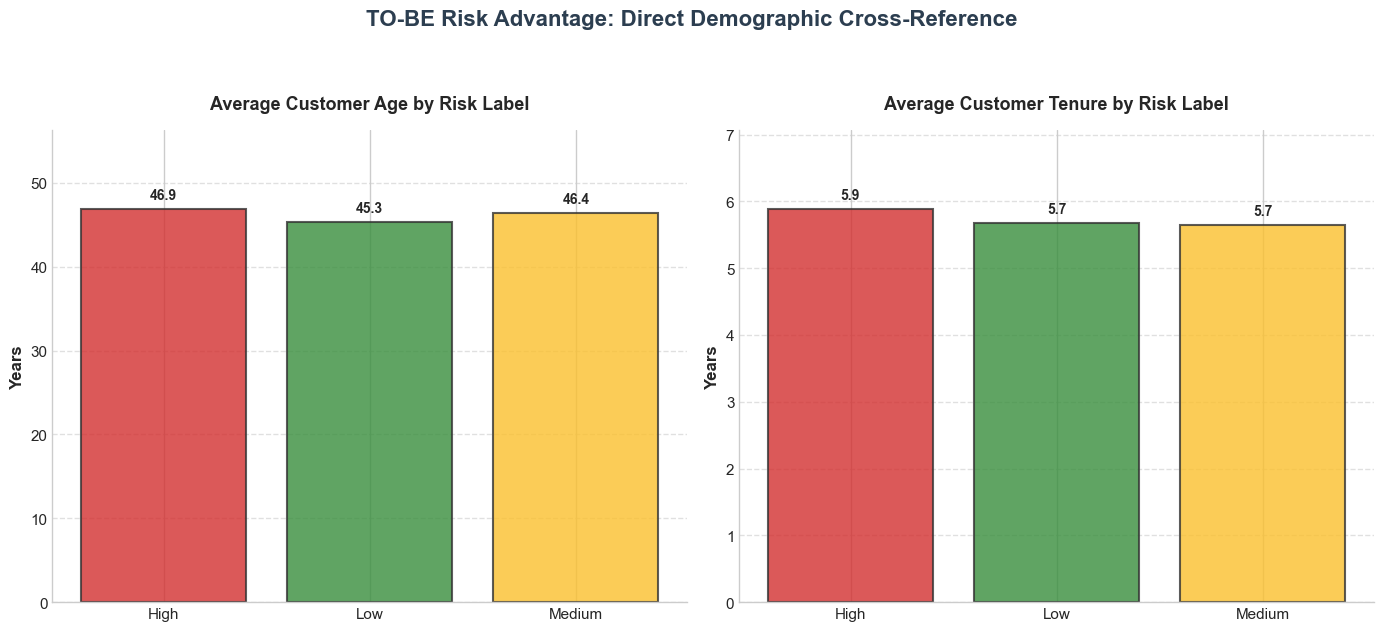


 ----- TO-BE RISK — DEMOGRAPHIC CROSS-REFERENCE (RISK PROFILE BY SUSPICIOUSNESS LABEL)-----


,avg_age,avg_tenure_years,observation_count
suspiciousness_label,,,
High,46.93,5.89,1709
Low,45.33,5.67,7866
Medium,46.37,5.65,1099


In [43]:
# TO-BE Risk advantage: cross-reference with demographics

risk_by_label = (
    tobe_ops_df[tobe_ops_df['suspiciousness_label'].notna()]
    .groupby('suspiciousness_label')
    .agg(
        avg_age=('age', 'mean'),
        avg_tenure_years=('tenure_years', 'mean'),
        observation_count=('pseudo_customer_key', 'count')
    )
    .round(2)
)


# --- Setup Plot
plt.style.use('seaborn-v0_8-whitegrid')
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

colors = {"High": "#d32f2f", "Medium": "#fbc02d", "Low": "#388e3c"}
bar_colors = [colors.get(idx, "grey") for idx in risk_by_label.index]

# Plot 1: Average Age
bars1 = ax1.bar(risk_by_label.index, risk_by_label['avg_age'], 
                color=bar_colors, alpha=0.8, edgecolor='#333', linewidth=1.5)
ax1.set_title("Average Customer Age by Risk Label", fontsize=13, fontweight='bold', pad=15)
ax1.set_ylabel("Years", fontweight='bold')
ax1.set_ylim(0, risk_by_label['avg_age'].max() * 1.2) # Beri space untuk label angka

# Plot 2: Average Tenure
bars2 = ax2.bar(risk_by_label.index, risk_by_label['avg_tenure_years'], 
                color=bar_colors, alpha=0.8, edgecolor='#333', linewidth=1.5)
ax2.set_title("Average Customer Tenure by Risk Label", fontsize=13, fontweight='bold', pad=15)
ax2.set_ylabel("Years", fontweight='bold')
ax2.set_ylim(0, risk_by_label['avg_tenure_years'].max() * 1.2)

def autolabel(ax, bars):
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.1f}',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 5), textcoords="offset points",
                    ha='center', va='bottom', fontweight='bold', fontsize=10)

autolabel(ax1, bars1)
autolabel(ax2, bars2)


for ax in [ax1, ax2]:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(axis='y', linestyle='--', alpha=0.6)

plt.suptitle("TO-BE Risk Advantage: Direct Demographic Cross-Reference", 
             fontsize=16, fontweight='bold', y=1.05, color='#2c3e50')
plt.tight_layout()
plt.show()


print('\n\033[1m ----- TO-BE RISK — DEMOGRAPHIC CROSS-REFERENCE (RISK PROFILE BY SUSPICIOUSNESS LABEL)-----\033[0m')

display(risk_by_label)

print()

<div style="background-color: #f8fafc; border-left: 6px solid #2c3e50; padding: 20px; border-radius: 10px; font-family: 'Segoe UI', Roboto, sans-serif; box-shadow: 0 2px 4px rgba(0,0,0,0.05);">
    <div style="display: flex; align-items: center; margin-bottom: 15px;">
        <span style="font-size: 1.5em; margin-right: 12px; line-height: 1;">👥</span>
        <strong style="color: #1a252f; font-size: 1.1em; letter-spacing: 0.3px;">DEMOGRAPHIC CROSS-REFERENCE ANALYSIS</strong>
    </div> 
    <div style="color: #34495e; line-height: 1.6; font-size: 0.95em;">
        <p style="margin: 0 0 12px 0;">
            The demographic cross-reference analysis highlights an additional advantage of the TO-BE model, where <b>Risk Management can directly integrate demographic attributes into risk evaluation</b>. This enables immediate identification of patterns across age and customer tenure without requiring IT-mediated data access.
        </p>
    </div>
</div>

### **S4 — 1.1.3 Output Dataset — 2LoD Risk Management**

***Output:** `tobe_risk_dashboard` — Oversight Layer Output*

*Aggregated oversight dataset. Same structure as AS-IS, but enriched with demographic context.*


| Feature                   | AS-IS Risk Management                | TO-BE Risk Management                      |
| ------------------------- | ------------------------------------ | ------------------------------------------ |
| **Data Access**           | Requires IT-provided aggregated data | Direct access to full operational datasets |
| **Granularity**           | Limited aggregated reports           | Dynamic aggregation (monthly, trend-based) |
| **PII Exposure**          | Possible (depending on request)      | None (synthetic data only)                 |
| **Metric Availability**   | Limited, request-based               | Real-time computed metrics                 |
| **Escalation Monitoring** | Delayed visibility                   | Immediate visibility                       |
| **Trend Analysis**        | Periodic, dependent on data delivery | Continuous and self-serve                  |
| **Inter-line Visibility** | Restricted                           | Fully shared across lines                  |
| **IT Dependency**         | ***Yes***                            | ***No***                                   |
| **Operational Latency**   | High                                 | ***Zero***                                 |


### **S4 — 1.1.4 Risk Management Transformation Output**
***Business Operations --> Risk Management (Oversight Transformation)***


| Dimension            | Input (`tobe_ops_df`, `tobe_transactions_case_view`) | Output (`tobe_lod2_risk_dashboard`)                   | Transformation       |
| -------------------- | ---------------------------------------------------- | ----------------------------------------------------- | -------------------- |
| **Granularity**      | Customer-day + transaction-level                     | Monthly aggregated metrics                            | Aggregation          |
| **Access**           | Shared datasets                                      | Shared datasets                                       | Maintained           |
| **IT Request**       | None                                                 | None                                                  | Maintained at 0      |
| **Processing Layer** | Monitoring & decision outputs                        | Aggregation + metric construction                     | Decision → Oversight |
| **Metrics**          | Not explicitly structured                            | Escalation rate, amplification ratio, stability index | Derived metrics      |
| **Latency**          | Immediate access                                     | Immediate aggregation                                 | No waiting time      |



### **S4 — 1.1.4 Data Dimension Gap: IT vs DataOps vs BusinessOps vs Risk vs Compliance — 2LoD Risk Management**

| Dimension           | IT (Raw Transaction)    | DataOps (`syn_customer_day`) | BusinessOps (`tobe_ops_case_log`) | Risk (`tobe_lod2_risk_dashboard`)     | Transformation                            |
| ------------------- | ----------------------- | ---------------------------- | --------------------------------- | ------------------------------------- | ----------------------------------------- |
| **Granularity**     | Transaction-level       | Customer-day                 | Case-level                        | Aggregated (monthly)                  | Event → Aggregated → Decision → Oversight |
| **Data Structure**  | Raw records             | Behavioral indicators        | Decision records                  | Aggregated metrics                    | Data → Signal → Action → Insight          |
| **Temporal Detail** | Timestamp (date + time) | Daily                        | Daily (case reference)            | Monthly trend                         | Temporal abstraction                      |
| **Feature Type**    | Raw attributes          | Analytical features          | Decision attributes               | Risk metrics                          | Raw → Analytical → Decision → Metrics     |
| **Dependency**      | Independent             | Interdependent               | Signal-dependent                  | Aggregation-dependent                 | Layered dependency                        |
| **Traceability**    | Direct                  | Linked                       | Fully traceable                   | Aggregated with drill-down capability | Preserved                                 |
| **PII Exposure**    | Full                    | None                         | None                              | None                                  | Privacy preserved                         |
| **Data Fidelity**   | Exact                   | Synthetic                    | Derived                           | Aggregated synthetic                  | Controlled abstraction                    |
| **Join Capability** | Limited                 | Fully joinable               | Fully joinable                    | Fully joinable                        | Interoperability                          |
| **Accessibility**   | Restricted              | Shared                       | Shared                            | Shared                                | Democratized                              |



*In the TO-BE model, Risk Management operates without data access constraints, enabling continuous oversight of escalation patterns and risk exposure without reliance on IT-mediated data provisioning. Aggregation and metric construction are performed directly on shared datasets, eliminating waiting time and transforming oversight into a continuous analytical process.*

<div style="background-color: #f5f7ff; border-left: 6px solid #3f51b5; padding: 25px; border-radius: 12px; font-family: 'Segoe UI', Roboto, sans-serif; box-shadow: 0 4px 6px rgba(0,0,0,0.05);">
    <div style="display: flex; align-items: center; margin-bottom: 20px;">
        <span style="font-size: 1.6em; margin-right: 15px; line-height: 1;">🏛️</span>
        <strong style="color: #1a237e; font-size: 1.2em; letter-spacing: 0.5px;">STRATEGIC ELEVATION</strong>
    </div> 
    <div style="color: #283593; line-height: 1.7; font-size: 1em;">
        <p style="margin: 0 0 15px 0; font-weight: 500;">
            The TO-BE design elevates Risk Management from a reactive validation role into a proactive, system-level monitoring function, capable of independently assessing both risk intensity and behavioral stability without operational dependency.
        </p>
        <div style="background: #ffffff; border: 1px dashed #c5cae9; padding: 15px; border-radius: 8px;">
            <p style="margin: 0; color: #3f51b5; font-style: italic;">
                The model introduces a layered transformation where raw transactional data is progressively abstracted into analytical signals, operational decisions, and ultimately system-level risk insights, enabling cross-functional governance without compromising data privacy.
            </p>
        </div>
    </div>
</div>


---
# **S4 — 1.2 2LoD: Compliance Department (Procedural Adherence)**
***Input:** `tobe_ops_df` and `tobe_case_log`*

*The Compliance function operates independently from Business Operations, focusing on procedural, regulatory adherence.*


| Component          | Description                                                                                                  |
| ------------------ | ------------------------------------------------------------------------------------------------------------ |
| **Role**           | Compliance (Independent Validation Layer — Procedural & Regulatory Oversight)                                |
| **Input**          | `tobe_ops_df`, `tobe_ops_case_log` (full monitoring dataset and escalated case log from Business Operations) |
| **Data Scope**     | Full population (`tobe_ops_df`) + escalated cases (`tobe_ops_case_log`)                                      |
| **Granularity**    | Customer-day (case-level for escalated observations)                                                         |
| **Access**         | Direct access to all required datasets (shared synthetic data layer)                                         |
| **PII Exposure**   | None (synthetic data only)                                                                                   |
| **Purpose**        | Validate procedural adherence, escalation handling, and compliance with internal and regulatory requirements |
| **Key Difference** | Independent review with full data visibility — no IT request required, no waiting time                       |



Unlike Risk Management, which focuses on system-level validation, the Compliance function ensures that operational processes adhere to internal policies and regulatory requirements.

In the TO-BE model, Compliance directly accesses both the full operational monitoring dataset (`tobe_ops_df`) and the formal escalated case log (`tobe_ops_case_log`) to perform independent validation of escalation decisions and case handling processes. The TO-BE design enables the Compliance function to independently perform procedural validation and regulatory checks directly on the synthetic Golden Source, eliminating dependency on IT-mediated data access. This strengthens governance by ensuring consistent adherence to policies while maintaining strict separation between operational execution (1LoD) and independent oversight (2LoD). 


---


## **Compliance 2nd Line (Independent Review Process)**

```mermaid
flowchart LR
    %% DIRECT ACCESS FROM GOLDEN SOURCE
    subgraph GoldenSource [1st Line: Golden Source]
        A[("synthetic_customer_day\n& tobe_ops_case_log")]
    end

    %% INTERNAL PROCESS: COMPLIANCE
    subgraph ComplianceDept [2nd Line: Compliance Department]
        direction TB

        C[Case Sampling Strategy]

        subgraph ReviewActivity [Independent Procedural Review]
            D[Documentation Completeness Check]
            E[SOP Adherence Validation]
            F[Override & Disposition Integrity]
        end

        G{Calculate SOP\nCompliance Rate}
    end

    %% DIRECT ACCESS — NO MANUAL REQUEST
    A ==>|Direct Access\nNo Request Needed| C
    C --> D & E & F
    D & E & F --> G

    G --> H[Output: Procedural Compliance Report]
    G --> I[Output: tobe_lod2_compliance_review_log]

    H & I --> AT_Comp[[Compliance Audit Trail]]

    %% Styling
    style GoldenSource fill:#e3f2fd,stroke:#1565c2,stroke-width:2px
    style ComplianceDept fill:#e8f5e9,stroke:#2e7d32,stroke-width:2px
    style ReviewActivity fill:#ffffff,stroke:#4caf50,stroke-dasharray:5 5
    style AT_Comp fill:#f3e5f5,stroke:#4a148c,stroke-width:3px
    style A fill:#fff9c4,stroke:#fbc02d,stroke-width:2px
```

<div style="background-color: #fefaf2; border-left: 6px solid #b45309; padding: 20px; border-radius: 10px; font-family: 'Segoe UI', Roboto, sans-serif; box-shadow: 0 2px 4px rgba(0,0,0,0.05);">
    <div style="display: flex; align-items: center; justify-content: space-between; margin-bottom: 15px;">
        <div style="display: flex; align-items: center;">
            <span style="font-size: 1.3em; margin-right: 12px;">⚖️</span>
            <strong style="color: #78350f; font-size: 1.1em; letter-spacing: 0.5px;">COMPLIANCE OVERSIGHT</strong>
        </div>
        <div style="background: #fffbeb; color: #b45309; border: 1px solid #f59e0b; padding: 3px 12px; border-radius: 20px; font-size: 0.8em; font-weight: bold; white-space: nowrap;">
            Direct 2LoD Access
        </div>
    </div>
    <div style="color: #454d55; line-height: 1.6; font-size: 0.95em;">
        <p style="margin: 0 0 10px 0;">
            <b>Key difference from AS-IS:</b> Compliance accesses <code style="background: #f1f1f1; padding: 2px 5px; border-radius: 4px; font-family: monospace;">tobe_ops_case_log</code> and <code style="background: #f1f1f1; padding: 2px 5px; border-radius: 4px; font-family: monospace;">synthetic_customer_day</code> directly — no manual data request to Business Ops or Data Ops.
        </p>
        <p style="margin: 0; color: #1e293b; font-weight: 500;">
            This enables real-time compliance monitoring while preserving data privacy and audit traceability.
        </p>
    </div>
</div>

## **S4 — 1.2.1 Input Dataset**

**input:** `tobe_ops_df` (primary), `tobe_ops_case_log` (supporting)

* `tobe_ops_df` — full operational monitoring dataset used for assessing procedural consistency, classification logic, and completeness of evaluation across all observations.
* `tobe_ops_case_log` — formal case-level dataset used to validate escalation decisions, disposition integrity, and adherence to standard operating procedures (SOP). As this dataset contain only escalated cases (labeled as `High`), triggering in-depth case review process.

In [44]:
print("\033[1m----- TO-BE COMPLIANCE INPUT -----\033[0m")
print("Input datasets used for procedural compliance review (2LoD)")

# PRIMARY INPUT
print('\n\033[1m ---------- [PRIMARY] tobe_ops_df (Full Monitoring Dataset): ----------\033[0m')
print(f'  Shape  : {tobe_ops_df.shape}')
print(f'  Columns: {tobe_ops_df.columns.tolist()}')
print(f'  Evaluated rows: {tobe_ops_df["is_evaluated"].sum():,}')
print()

display(tobe_ops_df.head(5))


# SUPPORTING INPUT
print('\n\033[1m ---------- [SUPPORTING] tobe_ops_case_log (Formal Escalated Case Log): ----------\033[0m')
print(f'  Shape  : {tobe_ops_case_log.shape}')
print(f'  Columns: {tobe_ops_case_log.columns.tolist()}')
print(f'  Unique cases: {tobe_ops_case_log["case_id"].nunique():,}')
print(f'  Case labels: {tobe_ops_case_log["suspiciousness_label"].value_counts().to_dict()}')
print()
display(tobe_ops_case_log.head(5))

----- TO-BE COMPLIANCE INPUT -----
Input datasets used for procedural compliance review (2LoD)

 ---------- [PRIMARY] tobe_ops_df (Full Monitoring Dataset): ----------
  Shape  : (11159, 22)
  Columns: ['pseudo_customer_key', 'date', 'daily_txn_count', 'daily_total_amount', 'daily_avg_amount', 'age', 'tenure_years', 'gender_cd', 'lang_pref', 'baseline_txn_count', 'baseline_total_amount', 'baseline_avg_amount', 'ratio_velocity', 'ratio_value', 'velocity_severity', 'value_severity', 'auto_red_flag', 'is_evaluated', 'suspiciousness_label', 'ops_disposition', 'ops_rules', 'month']
  Evaluated rows: 10,674



,pseudo_customer_key,date,daily_txn_count,daily_total_amount,daily_avg_amount,age,tenure_years,gender_cd,lang_pref,baseline_txn_count,...,ratio_velocity,ratio_value,velocity_severity,value_severity,auto_red_flag,is_evaluated,suspiciousness_label,ops_disposition,ops_rules,month
0,SYN_C_000001,2024-02-06,1,10.10,10.10,82,1,M,EE,NaN,...,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,Not evaluated (baseline not ready),2024-02
1,SYN_C_000001,2024-02-11,2,112.11,56.06,82,1,M,EE,NaN,...,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,Not evaluated (baseline not ready),2024-02
2,SYN_C_000001,2024-02-20,1,19.33,19.33,82,1,M,EE,NaN,...,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,Not evaluated (baseline not ready),2024-02
3,SYN_C_000001,2024-02-27,1,13.19,13.19,82,1,M,EE,NaN,...,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,Not evaluated (baseline not ready),2024-02
4,SYN_C_000001,2024-03-02,1,53.31,53.31,82,1,M,EE,NaN,...,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,Not evaluated (baseline not ready),2024-03



 ---------- [SUPPORTING] tobe_ops_case_log (Formal Escalated Case Log): ----------
  Shape  : (1709, 12)
  Columns: ['case_id', 'case_created_at', 'pseudo_customer_key', 'date', 'suspiciousness_label', 'ops_disposition', 'ratio_velocity', 'ratio_value', 'velocity_severity', 'value_severity', 'auto_red_flag', 'ops_rules']
  Unique cases: 1,709
  Case labels: {'High': 1709}



,case_id,case_created_at,pseudo_customer_key,date,suspiciousness_label,ops_disposition,ratio_velocity,ratio_value,velocity_severity,value_severity,auto_red_flag,ops_rules
5,CASE_SYN_C_000001_20240310,2026-05-15 13:39:27.836025,SYN_C_000001,2024-03-10,High,Escalate,1.6667,4.8356,Elevated,Significant,1.0,auto_red_flag=1 (Significant severity triggere...
9,CASE_SYN_C_000001_20240328,2026-05-15 13:39:27.836025,SYN_C_000001,2024-03-28,High,Escalate,0.8182,6.5256,Normal,Significant,1.0,auto_red_flag=1 (Significant severity triggere...
11,CASE_SYN_C_000001_20240505,2026-05-15 13:39:27.836025,SYN_C_000001,2024-05-05,High,Escalate,2.5385,0.7895,Significant,Normal,1.0,auto_red_flag=1 (Significant severity triggere...
15,CASE_SYN_C_000001_20240623,2026-05-15 13:39:27.836025,SYN_C_000001,2024-06-23,High,Escalate,0.7895,5.7669,Normal,Significant,1.0,auto_red_flag=1 (Significant severity triggere...
19,CASE_SYN_C_000001_20240726,2026-05-15 13:39:27.836025,SYN_C_000001,2024-07-26,High,Escalate,0.8261,6.3933,Normal,Significant,1.0,auto_red_flag=1 (Significant severity triggere...


## **S4 — 1.2.2 Data Process: Compliance Review Log**

***Output:** `tobe_compliance_log`*

*This dataset is used to store the compliance review results of customer activities with escalated status.*

The dataset captures the final reviewed outcome of each escalated case, serving as a structured record for compliance validation.

In [45]:
# TO-BE compliance review log — same structure as AS-IS

tobe_compliance_log = tobe_ops_case_log[[
    'case_id', 'case_created_at', 'pseudo_customer_key', 'date',
    'suspiciousness_label', 'ops_disposition'
]].copy()

print(f'Shape  : {tobe_compliance_log.shape}')
tobe_compliance_log.head()


Shape  : (1709, 6)


,case_id,case_created_at,pseudo_customer_key,date,suspiciousness_label,ops_disposition
5,CASE_SYN_C_000001_20240310,2026-05-15 13:39:27.836025,SYN_C_000001,2024-03-10,High,Escalate
9,CASE_SYN_C_000001_20240328,2026-05-15 13:39:27.836025,SYN_C_000001,2024-03-28,High,Escalate
11,CASE_SYN_C_000001_20240505,2026-05-15 13:39:27.836025,SYN_C_000001,2024-05-05,High,Escalate
15,CASE_SYN_C_000001_20240623,2026-05-15 13:39:27.836025,SYN_C_000001,2024-06-23,High,Escalate
19,CASE_SYN_C_000001_20240726,2026-05-15 13:39:27.836025,SYN_C_000001,2024-07-26,High,Escalate


## **S4 — 1.2.3 Data Process: Compliance Logic - Procedural Validation**

*This stage represents the compliance function performing an independent review of escalated cases generated by Business Operations.*

The objective is to validate whether internal controls related to escalation handling and case disposition are applied correctly and consistently, in accordance with predefined rules, thresholds, and standard operating procedures (SOP), both internal and regulatory. The validation is operationalised through quantitative compliance indicators derived from the review log.

### **S4 — 1.2.3.1 Data Process: Disposition Integrity** (*identical SOP mapping to AS-IS*)

*Verifying that the assigned ops_disposition (e.g., Escalate) aligns with the detected risk signals and rule triggers.*

In [46]:
# Identical to AS-IS expected_disposition.

def disposition_integrity(label):
    if label == "High":   return "Escalate"
    elif label == "Medium": return "Under review"
    elif label == "Low":  return "Dismiss"
    else: return np.nan

tobe_compliance_log["disposition_integrity"] = (
    tobe_compliance_log["suspiciousness_label"].apply(disposition_integrity)
)

print(f'\n\033[1m ----- SANITY CHECK AFTER ADDING DISPOSITION INTEGRITY -----\033[0m')
print(f'\nShape        : {tobe_compliance_log.shape}')
print(f'Column names : {tobe_compliance_log.columns.tolist()}')

display(tobe_compliance_log.head())

print('\n\033[1mDisposition Mapping Check:\033[0m')
print(tobe_compliance_log[["suspiciousness_label", "ops_disposition", "disposition_integrity"]].head())



 ----- SANITY CHECK AFTER ADDING DISPOSITION INTEGRITY -----

Shape        : (1709, 7)
Column names : ['case_id', 'case_created_at', 'pseudo_customer_key', 'date', 'suspiciousness_label', 'ops_disposition', 'disposition_integrity']


,case_id,case_created_at,pseudo_customer_key,date,suspiciousness_label,ops_disposition,disposition_integrity
5,CASE_SYN_C_000001_20240310,2026-05-15 13:39:27.836025,SYN_C_000001,2024-03-10,High,Escalate,Escalate
9,CASE_SYN_C_000001_20240328,2026-05-15 13:39:27.836025,SYN_C_000001,2024-03-28,High,Escalate,Escalate
11,CASE_SYN_C_000001_20240505,2026-05-15 13:39:27.836025,SYN_C_000001,2024-05-05,High,Escalate,Escalate
15,CASE_SYN_C_000001_20240623,2026-05-15 13:39:27.836025,SYN_C_000001,2024-06-23,High,Escalate,Escalate
19,CASE_SYN_C_000001_20240726,2026-05-15 13:39:27.836025,SYN_C_000001,2024-07-26,High,Escalate,Escalate



Disposition Mapping Check:
   suspiciousness_label ops_disposition disposition_integrity
5                  High        Escalate              Escalate
9                  High        Escalate              Escalate
11                 High        Escalate              Escalate
15                 High        Escalate              Escalate
19                 High        Escalate              Escalate


### **S4 — 1.2.3.2 Data Process: Escalation Consistency** 

*ensures that escalation decisions are not arbitrary, but systematically supported by underlying risk indicators*

This stage evaluates whether escalation decisions are consistent with underlying `rule-based indicators, such as auto_red_flag and severity thresholds`.

Consistency is assessed by comparing expected escalation (based on rule triggers) with actual escalation labels, ensuring alignment between detected risk signals and operational decisions.

In [47]:
# Expected escalation from rule
expected_escalation = (tobe_ops_case_log['auto_red_flag'] == 1)

# Actual escalation from label
actual_escalation = (tobe_ops_case_log['suspiciousness_label'] == 'High')

# Consistency check
consistency_check = (expected_escalation == actual_escalation)

consistency_rate = consistency_check.mean()

print('\n\033[1m----- ESCALATION CONSISTENCY CHECK -----\033[0m')
print(f'Consistent cases : {consistency_check.sum():,} / {len(tobe_ops_case_log):,}')
print(f'Consistency rate : {consistency_rate:.4f} ({consistency_rate*100:.2f}%)')

print('\n\033[1mEscalation Breakdown:\033[0m')
print(pd.crosstab(expected_escalation, actual_escalation))



----- ESCALATION CONSISTENCY CHECK -----
Consistent cases : 1,709 / 1,709
Consistency rate : 1.0000 (100.00%)

Escalation Breakdown:
suspiciousness_label  True
auto_red_flag             
True                  1709


### **S4 — 1.2.3.3 Data Process: Rule Adherence** 

*Ensuring that escalation decisions are rule-based and consistently aligned with predefined thresholds, rather than arbitrary or inconsistent judgment.*


This stage verifies whether escalation decisions comply with predefined rule logic, including trigger conditions such as `auto_red_flag` and severity thresholds (`velocity_severity` and `value_saverity`).

Rule adherence is assessed by comparing expected escalation (**based on rule conditions**) with actual escalation outcomes, ensuring that decisions are aligned with defined operational logic.

In [48]:
# Expected rule trigger (flexible logic)

expected_trigger = (
    (tobe_ops_case_log['auto_red_flag'] == 1) |
    (tobe_ops_case_log['velocity_severity'] == 'Significant') |
    (tobe_ops_case_log['value_severity'] == 'Significant')
)

# Actual escalation
actual_escalation = (tobe_ops_case_log['suspiciousness_label'] == 'High')

# Rule adherence check
rule_adherence_check = (expected_trigger == actual_escalation)

rule_adherence_rate = rule_adherence_check.mean()

print('\n\033[1m----- RULE ADHERENCE CHECK -----\033[0m')
print(f'Adherent cases : {rule_adherence_check.sum():,} / {len(tobe_ops_case_log):,}')
print(f'Adherence rate : {rule_adherence_rate:.4f} ({rule_adherence_rate*100:.2f}%)')


----- RULE ADHERENCE CHECK -----
Adherent cases : 1,709 / 1,709
Adherence rate : 1.0000 (100.00%)


### **S4 — 1.2.3.4 Data Process: SOP Deviation Flag** 

**Output:** `tobe_compliance_log`

*Providing a metric that enables to identify control deviationssystematicly; Allowing Compliance to detect inconsistencies in operational decision-making.*

This stage identifies **deviations from predefined SOP** by comparing the assigned `ops_disposition` with the expected disposition (`disposition_integrity`) derived from rule-based mapping. A deviation flag is generated to indicate whether the operational decision aligns with the predefined SOP logic.

In [49]:

tobe_compliance_log["sop_deviation_flag"] = (
    tobe_compliance_log["ops_disposition"] !=
    tobe_compliance_log["disposition_integrity"]
).astype(int)

display(tobe_compliance_log.head())

sop_rate = 1 - tobe_compliance_log["sop_deviation_flag"].mean()

#total reviewed
total_reviewed = len(tobe_compliance_log)

print('\n\033[1m----- SOP DEVIATION CHECK -----\033[0m')
print(f'Total reviewed   : {total_reviewed:,}')
print(f'Deviation cases : {tobe_compliance_log["sop_deviation_flag"].sum():,}')
print(f'SOP compliance  : {sop_rate:.4f} ({sop_rate*100:.2f}%)')

print('\n\033[1mDeviation Breakdown:\033[0m')
print(tobe_compliance_log["sop_deviation_flag"].value_counts())


,case_id,case_created_at,pseudo_customer_key,date,suspiciousness_label,ops_disposition,disposition_integrity,sop_deviation_flag
5,CASE_SYN_C_000001_20240310,2026-05-15 13:39:27.836025,SYN_C_000001,2024-03-10,High,Escalate,Escalate,0
9,CASE_SYN_C_000001_20240328,2026-05-15 13:39:27.836025,SYN_C_000001,2024-03-28,High,Escalate,Escalate,0
11,CASE_SYN_C_000001_20240505,2026-05-15 13:39:27.836025,SYN_C_000001,2024-05-05,High,Escalate,Escalate,0
15,CASE_SYN_C_000001_20240623,2026-05-15 13:39:27.836025,SYN_C_000001,2024-06-23,High,Escalate,Escalate,0
19,CASE_SYN_C_000001_20240726,2026-05-15 13:39:27.836025,SYN_C_000001,2024-07-26,High,Escalate,Escalate,0



----- SOP DEVIATION CHECK -----
Total reviewed   : 1,709
Deviation cases : 0
SOP compliance  : 1.0000 (100.00%)

Deviation Breakdown:
sop_deviation_flag
0    1709
Name: count, dtype: int64


<div style="background-color: #f6fef9; border-left: 6px solid #10b981; padding: 20px; border-radius: 10px; font-family: 'Segoe UI', Roboto, sans-serif; box-shadow: 0 2px 4px rgba(0,0,0,0.05);">
    <div style="display: flex; align-items: center; margin-bottom: 15px;">
        <span style="font-size: 1.5em; margin-right: 12px; line-height: 1;">🚩</span>
        <strong style="color: #064e3b; font-size: 1.1em; letter-spacing: 0.3px;">SOP DEVIATION & COMPLIANCE RATE</strong>
    </div>
    <div style="color: #111827; line-height: 1.6; font-size: 0.95em;">
        <p style="margin: 0 0 12px 0;">
            The <b>SOP deviation flag</b> quantifies whether operational decisions align with predefined rule-based expectations. 
        </p>
        <div style="background: #ffffff; border: 1px solid #d1fae5; padding: 12px; border-radius: 6px; display: flex; align-items: flex-start;">
            <span style="color: #059669; font-weight: bold; margin-right: 10px;">➔</span>
            <span>
                The resulting <b>compliance rate</b> provides a measurable indicator of procedural consistency within the compliance function.
            </span>
        </div>
    </div>
</div>

### **S4 — 1.2.3.5 Data Process: Documentation Present Flag** 

*escalated label are expected to have rule documentation records*

This step verifies whether supporting documentation is present for escalated cases. Cases marked as Escalate are expected to have non-empty rule documentation (ops_rules) recorded in the case log.

In [50]:
# documentation_present_flag — identical logic to AS-IS fixed version

tobe_compliance_log["documentation_present_flag"] = np.where(
    tobe_compliance_log["ops_disposition"] == "Escalate",
    tobe_compliance_log["case_id"].isin(
        tobe_ops_case_log[tobe_ops_case_log["ops_rules"].str.len() > 0]["case_id"]
    ).astype(int),
    1
)

print("documentation_present_flag distribution:")
print(tobe_compliance_log["documentation_present_flag"].value_counts())


documentation_present_flag distribution:
documentation_present_flag
1    1709
Name: count, dtype: int64


### **S4 — 1.2.3.6 Data Process: Compliance Status**

*classification output to Compliant or Governance Issue based on evidence*

This step classifies each reviewed case as either Compliant or Governance Issue, based on procedural consistency and documentation completeness.

In [51]:
tobe_compliance_log["compliance_status"] = np.where(
    (tobe_compliance_log["sop_deviation_flag"] == 0) &
    (tobe_compliance_log["documentation_present_flag"] == 1),
    "Compliant",
    "Governance Issue"
)
tobe_compliance_log.head()


,case_id,case_created_at,pseudo_customer_key,date,suspiciousness_label,ops_disposition,disposition_integrity,sop_deviation_flag,documentation_present_flag,compliance_status
5,CASE_SYN_C_000001_20240310,2026-05-15 13:39:27.836025,SYN_C_000001,2024-03-10,High,Escalate,Escalate,0,1,Compliant
9,CASE_SYN_C_000001_20240328,2026-05-15 13:39:27.836025,SYN_C_000001,2024-03-28,High,Escalate,Escalate,0,1,Compliant
11,CASE_SYN_C_000001_20240505,2026-05-15 13:39:27.836025,SYN_C_000001,2024-05-05,High,Escalate,Escalate,0,1,Compliant
15,CASE_SYN_C_000001_20240623,2026-05-15 13:39:27.836025,SYN_C_000001,2024-06-23,High,Escalate,Escalate,0,1,Compliant
19,CASE_SYN_C_000001_20240726,2026-05-15 13:39:27.836025,SYN_C_000001,2024-07-26,High,Escalate,Escalate,0,1,Compliant


### **S4 — 1.2.3.7 Data Process: Review Timestamp**

In [52]:
tobe_compliance_log["review_timestamp"] = pd.Timestamp.now()
tobe_compliance_log.head()


,case_id,case_created_at,pseudo_customer_key,date,suspiciousness_label,ops_disposition,disposition_integrity,sop_deviation_flag,documentation_present_flag,compliance_status,review_timestamp
5,CASE_SYN_C_000001_20240310,2026-05-15 13:39:27.836025,SYN_C_000001,2024-03-10,High,Escalate,Escalate,0,1,Compliant,2026-05-15 13:39:30.012960
9,CASE_SYN_C_000001_20240328,2026-05-15 13:39:27.836025,SYN_C_000001,2024-03-28,High,Escalate,Escalate,0,1,Compliant,2026-05-15 13:39:30.012960
11,CASE_SYN_C_000001_20240505,2026-05-15 13:39:27.836025,SYN_C_000001,2024-05-05,High,Escalate,Escalate,0,1,Compliant,2026-05-15 13:39:30.012960
15,CASE_SYN_C_000001_20240623,2026-05-15 13:39:27.836025,SYN_C_000001,2024-06-23,High,Escalate,Escalate,0,1,Compliant,2026-05-15 13:39:30.012960
19,CASE_SYN_C_000001_20240726,2026-05-15 13:39:27.836025,SYN_C_000001,2024-07-26,High,Escalate,Escalate,0,1,Compliant,2026-05-15 13:39:30.012960


### **S4 — 1.2.3.7 Data Process: Compliance Matrix**

#### **SOP Compliance Rate**

##### **Formula**

$$ SOP\ Compliance\ Rate = \frac{\text{Number of compliant cases}}{\text{Total reviewed cases}}$$

In [53]:
total_reviewed   = len(tobe_compliance_log)
sop_rate         = (tobe_compliance_log["sop_deviation_flag"] == 0).mean()
gov_rate         = (tobe_compliance_log["compliance_status"] == "Governance Issue").mean()
doc_rate         = tobe_compliance_log["documentation_present_flag"].mean()

print('\n\033[1m---------- TO-BE COMPLIANCE MATRIX ----------\n\033[0m')
print(f'Total reviewed          : {total_reviewed:,}')
print(f'SOP Compliance Rate     : {sop_rate:.4f} ({sop_rate*100:.2f}%)')
print(f'Governance Issue Rate   : {gov_rate:.4f} ({gov_rate*100:.2f}%)')
print(f'Documentation Rate      : {doc_rate:.4f} ({doc_rate*100:.2f}%)')



---------- TO-BE COMPLIANCE MATRIX ----------

Total reviewed          : 1,709
SOP Compliance Rate     : 1.0000 (100.00%)
Governance Issue Rate   : 0.0000 (0.00%)
Documentation Rate      : 1.0000 (100.00%)


## **S4 — 1.2.4 Output Dataset — 2LoD Compliance**

**Output:** `tobe_compliance_log` and `Compliance Dashboard`

*compliance review result is faster because all supporting data is directly accessible.*

`tobe_compliance_log` serves as the final reviewed compliance dataset, capturing all case-level validation results and procedural flags.
The compliance matrix provides an aggregated monitoring view that can support internal compliance oversight and dashboard-style reporting.

In the TO-BE setting, compliance review is performed more efficiently as all required supporting data is directly accessible through the synthetic data layer.


In [54]:
print('\n\033[1m---------- TO-BE COMPLIANCE REVIEW LOG ----------\n\033[0m')
tobe_compliance_log.head()

print(f'Shape: {tobe_compliance_log.shape}')


---------- TO-BE COMPLIANCE REVIEW LOG ----------

Shape: (1709, 11)


In [55]:
print("\033[1m---------- TO-BE COMPLIANCE DASHBOARD VIEW ----------\033[0m")

# summary KPI

total_reviewed = len(tobe_compliance_log)
compliant_cases = (tobe_compliance_log["compliance_status"] == "Compliant").sum()
governance_issues = (tobe_compliance_log["compliance_status"] == "Governance Issue").sum()
documentation_rate = tobe_compliance_log["documentation_present_flag"].mean()

print(f"\nTotal reviewed       : {total_reviewed:,}")
print(f"Compliant cases      : {compliant_cases:,}")
print(f"Governance issues    : {governance_issues:,}")
print(f"Documentation rate   : {documentation_rate:.4f} ({documentation_rate*100:.2f}%)")

# Dashboard-oriented display table

dashboard_view = tobe_compliance_log[[
    "case_id",
    "pseudo_customer_key",
    "date",
    "suspiciousness_label",
    "ops_disposition",
    "compliance_status",
    "documentation_present_flag",
    "review_timestamp"
]].copy()

dashboard_view["documentation_present_flag"] = dashboard_view["documentation_present_flag"].map({
    1: "Present",
    0: "Missing"
})

# rename columns for dashboard readability
dashboard_view = dashboard_view.rename(columns={
    "case_id": "Case ID",
    "pseudo_customer_key": "Customer",
    "date": "Case Date",
    "suspiciousness_label": "Ops Label",
    "ops_disposition": "Ops Decision",
    "compliance_status": "Compliance Review Result",
    "documentation_present_flag": "Documentation",
    "review_timestamp": "Reviewed At"
})

print("\n\033[1mDashboard Preview:\033[0m")
display(dashboard_view.head(10))


print("\n\033[1m---------- GOVERNANCE ISSUES ONLY ----------\033[0m")

governance_issue_view = dashboard_view[
    dashboard_view["Compliance Review Result"] == "Governance Issue"
].copy()

print(f"\nTotal governance issues: {len(governance_issue_view):,}\n")
display(governance_issue_view.head(10))

# Build review basis / review comment
tobe_compliance_log["review_basis"] = np.select(
    [
        (tobe_compliance_log["sop_deviation_flag"] == 1) &
        (tobe_compliance_log["documentation_present_flag"] == 0),

        (tobe_compliance_log["sop_deviation_flag"] == 1),

        (tobe_compliance_log["documentation_present_flag"] == 0)
    ],
    [
        "SOP deviation and missing documentation",
        "SOP deviation",
        "Missing documentation"
    ],
    default="SOP matched and documentation complete"
)

dashboard_view = tobe_compliance_log[[
    "case_id",
    "pseudo_customer_key",
    "date",
    "suspiciousness_label",
    "ops_disposition",
    "compliance_status",
    "review_basis",
    "documentation_present_flag",
    "review_timestamp"
]].copy()

dashboard_view["documentation_present_flag"] = dashboard_view["documentation_present_flag"].map({
    1: "Present",
    0: "Missing"
})

dashboard_view = dashboard_view.rename(columns={
    "case_id": "Case ID",
    "pseudo_customer_key": "Customer",
    "date": "Case Date",
    "suspiciousness_label": "Ops Label",
    "ops_disposition": "Ops Decision",
    "compliance_status": "Compliance Review Result",
    "review_basis": "Review Basis",
    "documentation_present_flag": "Documentation",
    "review_timestamp": "Reviewed At"
})

print("\n\033[1mDashboard Preview with Review Basis:\033[0m")
display(dashboard_view.head(10))

---------- TO-BE COMPLIANCE DASHBOARD VIEW ----------

Total reviewed       : 1,709
Compliant cases      : 1,709
Governance issues    : 0
Documentation rate   : 1.0000 (100.00%)

Dashboard Preview:


,Case ID,Customer,Case Date,Ops Label,Ops Decision,Compliance Review Result,Documentation,Reviewed At
5,CASE_SYN_C_000001_20240310,SYN_C_000001,2024-03-10,High,Escalate,Compliant,Present,2026-05-15 13:39:30.012960
9,CASE_SYN_C_000001_20240328,SYN_C_000001,2024-03-28,High,Escalate,Compliant,Present,2026-05-15 13:39:30.012960
11,CASE_SYN_C_000001_20240505,SYN_C_000001,2024-05-05,High,Escalate,Compliant,Present,2026-05-15 13:39:30.012960
15,CASE_SYN_C_000001_20240623,SYN_C_000001,2024-06-23,High,Escalate,Compliant,Present,2026-05-15 13:39:30.012960
19,CASE_SYN_C_000001_20240726,SYN_C_000001,2024-07-26,High,Escalate,Compliant,Present,2026-05-15 13:39:30.012960
22,CASE_SYN_C_000001_20240821,SYN_C_000001,2024-08-21,High,Escalate,Compliant,Present,2026-05-15 13:39:30.012960
28,CASE_SYN_C_000001_20241106,SYN_C_000001,2024-11-06,High,Escalate,Compliant,Present,2026-05-15 13:39:30.012960
32,CASE_SYN_C_000001_20241207,SYN_C_000001,2024-12-07,High,Escalate,Compliant,Present,2026-05-15 13:39:30.012960
35,CASE_SYN_C_000001_20241225,SYN_C_000001,2024-12-25,High,Escalate,Compliant,Present,2026-05-15 13:39:30.012960
42,CASE_SYN_C_000002_20240304,SYN_C_000002,2024-03-04,High,Escalate,Compliant,Present,2026-05-15 13:39:30.012960



---------- GOVERNANCE ISSUES ONLY ----------

Total governance issues: 0



,Case ID,Customer,Case Date,Ops Label,Ops Decision,Compliance Review Result,Documentation,Reviewed At



Dashboard Preview with Review Basis:


,Case ID,Customer,Case Date,Ops Label,Ops Decision,Compliance Review Result,Review Basis,Documentation,Reviewed At
5,CASE_SYN_C_000001_20240310,SYN_C_000001,2024-03-10,High,Escalate,Compliant,SOP matched and documentation complete,Present,2026-05-15 13:39:30.012960
9,CASE_SYN_C_000001_20240328,SYN_C_000001,2024-03-28,High,Escalate,Compliant,SOP matched and documentation complete,Present,2026-05-15 13:39:30.012960
11,CASE_SYN_C_000001_20240505,SYN_C_000001,2024-05-05,High,Escalate,Compliant,SOP matched and documentation complete,Present,2026-05-15 13:39:30.012960
15,CASE_SYN_C_000001_20240623,SYN_C_000001,2024-06-23,High,Escalate,Compliant,SOP matched and documentation complete,Present,2026-05-15 13:39:30.012960
19,CASE_SYN_C_000001_20240726,SYN_C_000001,2024-07-26,High,Escalate,Compliant,SOP matched and documentation complete,Present,2026-05-15 13:39:30.012960
22,CASE_SYN_C_000001_20240821,SYN_C_000001,2024-08-21,High,Escalate,Compliant,SOP matched and documentation complete,Present,2026-05-15 13:39:30.012960
28,CASE_SYN_C_000001_20241106,SYN_C_000001,2024-11-06,High,Escalate,Compliant,SOP matched and documentation complete,Present,2026-05-15 13:39:30.012960
32,CASE_SYN_C_000001_20241207,SYN_C_000001,2024-12-07,High,Escalate,Compliant,SOP matched and documentation complete,Present,2026-05-15 13:39:30.012960
35,CASE_SYN_C_000001_20241225,SYN_C_000001,2024-12-25,High,Escalate,Compliant,SOP matched and documentation complete,Present,2026-05-15 13:39:30.012960
42,CASE_SYN_C_000002_20240304,SYN_C_000002,2024-03-04,High,Escalate,Compliant,SOP matched and documentation complete,Present,2026-05-15 13:39:30.012960


## **S4 — 1.2.5 Output General Output 2LoD Compliance**

### **1. KPI - COMPLIANCE MATRIX Matrices**

| Metric                    | Value   | Interpretation                                      |
| ------------------------- | ------- | --------------------------------------------------- |
| **Total Reviewed Cases**  | 1,709   | All escalated cases are reviewed                    |
| **SOP Compliance Rate**   | 100.00% | All cases follow defined procedural rules           |
| **Governance Issue Rate** | 0.00%   | No deviation from governance standards detected     |
| **Documentation Rate**    | 100.00% | All cases contain required supporting documentation |

## **2. Governance Insight**

| Dimension                      | Observation                      | Governance Implication             |
| ------------------------------ | -------------------------------- | ---------------------------------- |
| **Coverage**                   | 100% of escalated cases reviewed | Full compliance oversight achieved |
| **SOP Adherence**              | 100% compliant                   | Strong procedural consistency      |
| **Documentation Completeness** | 100% available                   | Full audit traceability            |
| **Governance Issues**          | 0 detected                       | No control failure identified      |
| **Operational Latency**        | 0 (no delay)                     | Immediate compliance validation    |
| **IT Dependency**              | 0                                | Fully independent review process   |


## **S4 — 1.2.6 Output Dataset — 2LoD Compliance**

| Feature                        | AS-IS Compliance                                           | TO-BE Compliance                                                           |
| ------------------------------ | ---------------------------------------------------------- | -------------------------------------------------------------------------- |
| **Data Access**                | Requires IT request for case evidence and transaction data | Direct access to operational datasets (`tobe_ops_df`, `tobe_ops_case_log`) |
| **Granularity**                | Case-level (limited supporting data)                       | Case-level with full linked analytical context                             |
| **PII Exposure**               | Possible (raw data access required)                        | None (synthetic data only)                                                 |
| **Review Scope**               | Limited to requested samples                               | Full coverage of escalated cases                                           |
| **SOP Validation**             | Dependent on available documentation                       | Fully validated across all cases                                           |
| **Documentation Check**        | Partial, request-based                                     | Complete and immediately accessible                                        |
| **Governance Issue Detection** | Dependent on data availability                             | Continuous and systematic                                                  |
| **Inter-line Visibility**      | Restricted                                                 | Fully shared across lines                                                  |
| **IT Dependency**              | ***Yes***                                                  | ***No***                                                                   |
| **Operational Latency**        | High (data request delay)                                  | ***Zero*** (instant validation)                                            |


- **Event-level visibility** --> Available via `tobe_ops_df`
- **Counterparty context** --> Available via synthetic transactions
- **IT request dependency** --> Eliminated
- **Review speed** --> Immediate (no waiting for data delivery)


## **S4 — 1.2.7 Compliance Transformation Output — 2LoD Compliance**

***`Business Operations → Compliance (Procedural Validation Layer)`***

| Dimension         | Input (`tobe_ops_df`, `tobe_ops_case_log`) | Output (`tobe_compliance_log`)      | Transformation        |
| ----------------- | ------------------------------------------ | ----------------------------------- | --------------------- |
| **Granularity**   | Customer-day + case-level                  | Case-level review                   | Decision → Validation |
| **Access**        | Shared datasets                            | Shared datasets                     | Maintained            |
| **IT Request**    | None                                       | None                                | Maintained at 0       |
| **Processing**    | Decision output                            | SOP validation, documentation check | Control layer added   |
| **Latency**       | Immediate access                           | Immediate validation                | No waiting time       |
| **Control Layer** | Not present                                | Introduced                          | Action → Assurance    |


## **S4 — 1.2.8 Data Dimension Gap: IT vs DataOps vs BusinessOps vs Risk vs Compliance — 2LoD Compliance**

| Dimension          | IT          | DataOps        | BusinessOps     | Risk               | Compliance         | Transformation                                   |
| ------------------ | ----------- | -------------- | --------------- | ------------------ | ------------------ | ------------------------------------------------ |
| **Granularity**    | Transaction | Customer-day   | Case-level      | Aggregated         | Case-level review  | Event → Signal → Action → Oversight → Validation |
| **Data Structure** | Raw         | Analytical     | Decision        | Metrics            | Validation records | Data → Signal → Action → Insight → Assurance     |
| **Feature Type**   | Raw         | Derived        | Decision        | Aggregated         | Control flags      | Increasing abstraction                           |
| **Traceability**   | Direct      | Linked         | Fully traceable | Drill-down capable | Fully traceable    | Preserved                                        |
| **PII Exposure**   | Full        | None           | None            | None               | None               | Privacy preserved                                |
| **Dependency**     | Independent | Interdependent | Signal-based    | Aggregation-based  | Decision-based     | Layered                                          |
| **Accessibility**  | Restricted  | Shared         | Shared          | Shared             | Shared             | Democratized                                     |


---

<div style="background-color: #ffffff; border: 2px solid #0ea5e9; padding: 30px; border-radius: 15px; font-family: 'Segoe UI', Roboto, sans-serif; box-shadow: 0 10px 25px rgba(14, 165, 233, 0.1); max-width: 950px; margin: auto;">
    <div style="text-align: center; margin-bottom: 25px; border-bottom: 2px solid #f1f5f9; padding-bottom: 15px;">
        <div style="display: flex; align-items: center; justify-content: center; gap: 12px;">
            <span style="font-size: 1.8em;">🚀</span>
            <h2 style="color: #0f172a; margin: 0; font-size: 1.4em; letter-spacing: 1px; text-transform: uppercase;">TO-BE ARCHITECTURE: THE EMPOWERMENT SHIFT</h2>
        </div>
    </div>
    <div style="display: grid; grid-template-columns: 1fr 1fr; gap: 20px; margin-bottom: 25px;">
        <div style="background: #f0f9ff; padding: 15px; border-radius: 10px; border-left: 5px solid #0ea5e9;">
            <strong style="color: #0369a1; display: block; margin-bottom: 8px;">🔓 Direct Data Empowerment</strong>
            <p style="font-size: 0.85em; color: #334155; line-height: 1.6; margin: 0;">
                By utilizing <b>Synthetic Data (SDG)</b>, the TO-BE model removes the request layer. Investigators, Risk, and Compliance now have <b>unrestricted, simultaneous access</b> to granular behavioral patterns without compromising PII.
            </p>
        </div>
        <div style="background: #fdfcf0; padding: 15px; border-radius: 10px; border-left: 5px solid #eab308;">
            <strong style="color: #854d0e; display: block; margin-bottom: 8px;">🌐 Holistic Risk Validation</strong>
            <p style="font-size: 0.85em; color: #334155; line-height: 1.6; margin: 0;">
                Compliance no longer relies on "selected samples." They can audit the <b>entire behavioral map</b> in real-time, uncovering systemic anomalies that were previously invisible in the AS-IS aggregated view.
            </p>
        </div>
    </div>
    <div style="background-color: #0f172a; color: #f8fafc; padding: 20px; border-radius: 10px;">
        <p style="margin: 0; font-size: 1em; text-align: center; line-height: 1.6;">
            "The TO-BE model transforms <b>Compliance from a sampling exercise into a continuous assurance engine</b>, where the integrity of oversight is guaranteed by direct access to the full analytical context."
        </p>
    </div>
    <div style="display: flex; justify-content: center; gap: 10px; margin-top: 20px;">
        <span style="background: #e0f2fe; color: #0369a1; padding: 5px 15px; border-radius: 20px; font-size: 0.75em; font-weight: bold;">Zero Request Latency</span>
        <span style="background: #e0f2fe; color: #0369a1; padding: 5px 15px; border-radius: 20px; font-size: 0.75em; font-weight: bold;">100% Data Transparency</span>
        <span style="background: #e0f2fe; color: #0369a1; padding: 5px 15px; border-radius: 20px; font-size: 0.75em; font-weight: bold;">Proactive Risk Discovery</span>
    </div>
</div>

---
# **SECTION 5 — THE THIRD LINE OF DEFENCE (INTERNAL AUDIT) (3LoD)**
---

---
# **S5 — 1.1 — 3LoD: Internal Audit Department (Independent Assurance Review)**

***input:** `all lines output`*

*Ensure the effectiveness and efficiency of internal controls across all governance layers, supported by full data visibility and independent assurance*

| Component          | Description                                                                                       |
| ------------------ | ------------------------------------------------------------------------------------------------- |
| **Role**           | Internal Audit (Independent Assurance Layer — Control Testing & Verification)                     |
| **Input**          | All outputs from 1LoD and 2LoD (DataOps, Business Operations, Risk Management, and Compliance)    |
| **Data Scope**     | Full population, case-level decisions, aggregated risk metrics, and compliance validation outputs |
| **Granularity**    | Multi-level (customer-day, case-level, transaction-level, aggregated metrics)                     |
| **Access**         | Direct access to all datasets via shared synthetic data layer                                     |
| **PII Exposure**   | None (synthetic data only)                                                                        |
| **Purpose**        | Enable independent, end-to-end verification across all governance layers                          |
| **Key Difference** | Full cross-line visibility — no IT request required, no waiting time                              |




## **Internal Audit Department (Independent Assurance Review)**

```mermaid
flowchart LR
    %% GOLDEN SOURCE (DIRECT ACCESS)
    subgraph GoldenSource [Shared Synthetic Access Layer]
        A[("synthetic_customer_day\nAll monitoring outputs")]
        B[("tobe_ops_case_log\nBusiness Ops decisions")]
        C[("tobe_lod2_risk_dashboard\nRisk assessment")]
        D[("tobe_compliance_log\nCompliance review")]
    end

    %% INTERNAL AUDIT
    subgraph Audit [Internal Audit - 3rd Line]
        E[Independent Sampling & Population Review]
        F[Control Testing & Verification]
        G[Evidence Assessment]
        H{Audit Conclusion}
    end

    %% DIRECT ACCESS — ALL LINES
    A & B & C & D ==>|Direct Access\nNo IT Request| E
    E --> F --> G --> H

    H --> WP[Audit Workpaper]
    H --> AF[Audit Findings]

    %% EXCEPTION — LEGAL EVIDENCE ONLY
    H -.->|Formal Request\nLegal Evidence Only| RealData[(Real PII Data\nFormal Investigation)]

    %% Styling
    style GoldenSource fill:#e3f2fd,stroke:#1565c2,stroke-width:2px
    style Audit fill:#fce4ec,stroke:#880e4f,stroke-width:3px
    style RealData fill:#eeeeee,stroke:#999,stroke-dasharray:5 5
```

---

<div style="background-color: #f1f5f9; border-left: 6px solid #334155; padding: 20px; border-radius: 10px; font-family: 'Segoe UI', Roboto, sans-serif; box-shadow: 0 2px 4px rgba(0,0,0,0.05);">
    <div style="display: flex; align-items: center; justify-content: space-between; margin-bottom: 15px;">
        <div style="display: flex; align-items: center;">
            <span style="font-size: 1.3em; margin-right: 12px;">📑</span>
            <strong style="color: #0f172a; font-size: 1.1em; letter-spacing: 0.5px;">AUDIT & LEGAL ACCESS PROTOCOL</strong>
        </div>
        <div style="background: #e2e8f0; color: #475569; padding: 3px 12px; border-radius: 20px; font-size: 0.8em; font-weight: bold; white-space: nowrap;">
            Zero Bottleneck Flow
        </div>
    </div>
    <div style="color: #334155; line-height: 1.6; font-size: 0.95em;">
        <p style="margin: 0 0 10px 0;">
            <b>Key difference from AS-IS:</b>
        </p>
        <ul style="margin: 0; padding-left: 20px;">
            <li>Audit accesses <b>ALL outputs directly</b> — no IT request for analytical purposes.</li>
            <li>Real PII data only requested for <b>formal legal evidence</b> (specific investigation, documented justification).</li>
            <li>This eliminates <b>"Audit process fatigue"</b> from data request bottleneck documented in AS-IS.</li>
        </ul>
    </div>
</div>


## **S5 — 1.1.1 — Input Dataset**

**Input:**  

*All outputs generated from the 1st Line of Defense (1LoD) and 2nd Line of Defense (2LoD) are directly accessible as input for the Internal Audit function.*


This enables audit to perform independent assurance using the full analytical population, without requiring additional data requests from IT or intermediary functions.

In [56]:
print("\n\033[1m---------- TO-BE INTERNAL AUDIT INPUT ----------\033[0m")
print(f'tobe_ops_case_log        : {tobe_ops_case_log.shape}')
print(f'tobe_ops_log             : {tobe_ops_log.shape}')
print(f'tobe_risk_dashboard      : {tobe_risk_dashboard.shape}')
print(f'tobe_compliance_log      : {tobe_compliance_log.shape}')
print(f'syn_customer_day         : {syn_customer_day.shape}')
print(f'tobe_transactions_case_view : {tobe_transactions_case_view.shape}')
print()
print('All datasets accessed directly — zero IT requests for analytical audit')



---------- TO-BE INTERNAL AUDIT INPUT ----------
tobe_ops_case_log        : (1709, 12)
tobe_ops_log             : (11159, 10)
tobe_risk_dashboard      : (12, 13)
tobe_compliance_log      : (1709, 12)
syn_customer_day         : (11159, 18)
tobe_transactions_case_view : (4343, 21)

All datasets accessed directly — zero IT requests for analytical audit


### **S5 — 1.1.1.1 Input: Define Data Population & Create Audit Sampling / Review Logic**

The audit sampling strategy follows a **risk-based approach**, incorporating both high-risk and lower-risk observations. All escalated cases are fully included to ensure comprehensive review of high-risk activities. Additionally, a stratified sample of non-escalated cases is selected to evaluate control effectiveness and detect potential gaps in escalation logic.

In [57]:
# Build audit population from full monitoring dataset

ops_df_audit = tobe_ops_log.copy() # all escalation status

ops_case_meta = tobe_ops_case_log[[
    "pseudo_customer_key",
    "date",
    "case_id",
    "case_created_at"
]].copy()

# align date type
ops_df_audit["date"] = pd.to_datetime(ops_df_audit["date"]).dt.normalize()
ops_case_meta["date"] = pd.to_datetime(ops_case_meta["date"]).dt.normalize()

# merge formal case metadata into full monitoring population
audit_population = ops_df_audit.merge(
    ops_case_meta,
    on=["pseudo_customer_key", "date"],
    how="left"
)

# add month for stratified sampling
audit_population["month"] = pd.to_datetime(audit_population["date"]).dt.to_period("M")

# because NaN is considering as not triggered yet the history transaction calcuation so label as non evaluate
audit_population["ops_disposition"] = audit_population["ops_disposition"].fillna("Not Evaluated")

print("Audit population shape:", audit_population.shape)
print("\nops_disposition distribution:")
print(audit_population["ops_disposition"].value_counts(dropna=False))

print("\nCase ID availability:")
print(audit_population["case_id"].notna().value_counts())

Audit population shape: (11159, 13)

ops_disposition distribution:
ops_disposition
Dismiss          7866
Escalate         1709
Under review     1099
Not Evaluated     485
Name: count, dtype: int64

Case ID availability:
case_id
False    9450
True     1709
Name: count, dtype: int64


In [58]:
print("\n\033[1m---------- SANITY CHECK BEFORE CREATING AUDIT SAMPLE ----------\033[0m")
print(f' Dimension of all Population Data: {audit_population.shape}')
print(f'All Population Data Column Name: {audit_population.columns.tolist()}')


---------- SANITY CHECK BEFORE CREATING AUDIT SAMPLE ----------
 Dimension of all Population Data: (11159, 13)
All Population Data Column Name: ['pseudo_customer_key', 'date', 'suspiciousness_label', 'ops_disposition', 'ratio_velocity', 'ratio_value', 'velocity_severity', 'value_severity', 'auto_red_flag', 'ops_rules', 'case_id', 'case_created_at', 'month']


In [59]:
# Audit sample — identical methodology to AS-IS

escalated_cases = audit_population[
    audit_population["ops_disposition"] == "Escalate"
].copy()

# Escalated sample (stratified by month + label)
escalated_sample = (
    escalated_cases
    .groupby(["month", "suspiciousness_label"], group_keys=False)
    .apply(lambda x: x.sample(n=min(len(x), 50), random_state=42))
    .reset_index(drop=True)
)

# Non-escalated sample
non_esc = audit_population[
    (audit_population["ops_disposition"] != "Escalate") &
    (audit_population["suspiciousness_label"].isin(["Medium", "Low"]))
].copy()

non_escalated_sample = (
    non_esc
    .groupby(["month", "suspiciousness_label"], group_keys=False)
    .apply(lambda x: x.sample(n=min(len(x), 30), random_state=42))
    .reset_index(drop=True)
)

# Final sample

tobe_audit_sample = pd.concat(
    [escalated_sample, non_escalated_sample],
    ignore_index=True
).copy()

print(f'Escalated sample    : {escalated_sample.shape}')
print(f'Non-escalated sample: {non_escalated_sample.shape}')
print(f'Final audit sample  : {tobe_audit_sample.shape}')
print()
print('ops_disposition distribution:')
print(tobe_audit_sample["ops_disposition"].value_counts(dropna=False))


Escalated sample    : (600, 13)
Non-escalated sample: (720, 13)
Final audit sample  : (1320, 13)

ops_disposition distribution:
ops_disposition
Escalate        600
Dismiss         360
Under review    360
Name: count, dtype: int64


<div style="background-color: #f8fafc; border-left: 6px solid #334155; padding: 20px; border-radius: 10px; font-family: 'Segoe UI', Roboto, sans-serif; box-shadow: 0 2px 4px rgba(0,0,0,0.05);">
    <div style="display: flex; align-items: center; margin-bottom: 15px;">
        <span style="font-size: 1.5em; margin-right: 12px; line-height: 1;">🛡️</span>
        <strong style="color: #0f172a; font-size: 1.1em; letter-spacing: 0.3px;">AUDIT SAMPLING & CONTROL EFFECTIVENESS</strong>
    </div>
    <div style="color: #334155; line-height: 1.6; font-size: 0.95em;">
        <p style="margin: 0 0 12px 0;">
            The audit sample includes both <b>escalated and non-escalated observations</b>, enabling validation of both correctly identified high-risk cases and <b>potential missed escalations</b>.
        </p>
        <div style="background: #ffffff; border-radius: 6px; border: 1px solid #e2e8f0; padding: 12px;">
            <p style="margin: 0; color: #475569; font-style: italic;">
                Although a risk-based approach is applied, the sampling design also aims to assess the overall effectiveness of control mechanisms, ensuring that escalation logic and monitoring rules are consistently applied across the population.
            </p>
        </div>
    </div>
</div>

## **S5 — 1.1.2 Process: Auditor Checking (Assess Audit Sample vs Compliance Review)**

*Assess decision making process both in the 1LOD and 2LOD*

In this phase, the auditor performs independent assurance testing on the sampled observations related to suspicious transactions.
The review covers outputs from both the first line of defense (1LoD) and the second line of defense (2LoD). The objective is to assess whether escalation decisions and subsequent compliance reviews are performed correctly and consistently.
Audit procedures are triggered when inconsistencies or potential control weaknesses are identified within the sampled observations.

## **S5 — 1.1.2.1 Process: Traceability Verification (exception-based)**
**1. Verification of Operational Escalation (Business Operations)**

This stage evaluates whether escalation decisions made by Business Operations are consistent with the underlying suspiciousness classification.

Audit flags are assigned to identify potential issues, including:
1. Under-escalation (high-risk cases not escalated)
2. Over-escalation (low-risk cases escalated unnecessarily)
3. Policy adherence issues (misalignment between risk signals and escalation decisions)

In [60]:
# Audit verification flags

## 1. Verification of Operational Escalation (Business Operations)

# Audit verification flags
tobe_audit_sample["is_high"] = (
    tobe_audit_sample["suspiciousness_label"] == "High"
).astype(int)

tobe_audit_sample["is_escalated"] = (
    tobe_audit_sample["ops_disposition"] == "Escalate"
).astype(int)

tobe_audit_sample["under_escalation_flag"] = (
    (tobe_audit_sample["is_high"] == 1) &
    (tobe_audit_sample["is_escalated"] == 0)
).astype(int)

tobe_audit_sample["over_escalation_flag"] = (
    (tobe_audit_sample["is_high"] == 0) &
    (tobe_audit_sample["is_escalated"] == 1)
).astype(int)

tobe_audit_sample["policy_adherence_flag"] = np.where(
    (tobe_audit_sample["under_escalation_flag"] == 1) |
    (tobe_audit_sample["over_escalation_flag"] == 1),
    0, 1
)

display(tobe_audit_sample.head())
print(f'\n Dimension of audit sample: {tobe_audit_sample.shape}')

,pseudo_customer_key,date,suspiciousness_label,ops_disposition,ratio_velocity,ratio_value,velocity_severity,value_severity,auto_red_flag,ops_rules,case_id,case_created_at,month,is_high,is_escalated,under_escalation_flag,over_escalation_flag,policy_adherence_flag
0,SYN_C_000066,2024-01-11,High,Escalate,3.0000,1.5643,Significant,Elevated,1.0,auto_red_flag=1 (Significant severity triggere...,CASE_SYN_C_000066_20240111,2026-05-15 13:39:27.836025,2024-01,1,1,0,0,1
1,SYN_C_000017,2024-01-15,High,Escalate,2.2727,1.6921,Significant,Elevated,1.0,auto_red_flag=1 (Significant severity triggere...,CASE_SYN_C_000017_20240115,2026-05-15 13:39:27.836025,2024-01,1,1,0,0,1
2,SYN_C_000005,2024-01-14,High,Escalate,0.6923,5.3316,Normal,Significant,1.0,auto_red_flag=1 (Significant severity triggere...,CASE_SYN_C_000005_20240114,2026-05-15 13:39:27.836025,2024-01,1,1,0,0,1
3,SYN_C_000070,2024-01-22,High,Escalate,0.9600,2.0087,Normal,Significant,1.0,auto_red_flag=1 (Significant severity triggere...,CASE_SYN_C_000070_20240122,2026-05-15 13:39:27.836025,2024-01,1,1,0,0,1
4,SYN_C_000058,2024-01-16,High,Escalate,1.5000,2.7924,Normal,Significant,1.0,auto_red_flag=1 (Significant severity triggere...,CASE_SYN_C_000058_20240116,2026-05-15 13:39:27.836025,2024-01,1,1,0,0,1



 Dimension of audit sample: (1320, 18)


**2. Verification of Compliance Review (Second Line Oversight)**

This stage verifies whether the Compliance function has appropriately reviewed escalated cases and whether the review aligns with established internal and regulatory requirements.

The assessment includes:

1. SOP adherence (presence of procedural deviations)
2. Documentation completeness
3. Consistency of compliance review outcomes

In [61]:
# Merge compliance evidence

## 2. Verification of Compliance Review (Second Line Oversight)

# Merge compliance evidence
tobe_audit_compliance = tobe_audit_sample.merge(
    tobe_compliance_log[[
        "case_id",
        "sop_deviation_flag",
        "documentation_present_flag",
        "compliance_status"
    ]].rename(columns={
        "sop_deviation_flag": "sop_deviation_flag_compliance",
        "documentation_present_flag": "documentation_present_flag_compliance",
        "compliance_status": "compliance_status_compliance"
    }),
    on="case_id",
    how="left"
)

tobe_audit_compliance["sop_deviation_flag_compliance"] = (
    tobe_audit_compliance["sop_deviation_flag_compliance"].fillna(0)
)

tobe_audit_compliance["documentation_present_flag_compliance"] = (
    tobe_audit_compliance["documentation_present_flag_compliance"].fillna(1)
)

tobe_audit_compliance["compliance_status_compliance"] = (
    tobe_audit_compliance["compliance_status_compliance"].fillna("Not Reviewed by Compliance")
)

display(tobe_audit_compliance.head())
print(f'\n Dimension of Audit Compliance: {tobe_audit_compliance.shape}')


,pseudo_customer_key,date,suspiciousness_label,ops_disposition,ratio_velocity,ratio_value,velocity_severity,value_severity,auto_red_flag,ops_rules,...,case_created_at,month,is_high,is_escalated,under_escalation_flag,over_escalation_flag,policy_adherence_flag,sop_deviation_flag_compliance,documentation_present_flag_compliance,compliance_status_compliance
0,SYN_C_000066,2024-01-11,High,Escalate,3.0000,1.5643,Significant,Elevated,1.0,auto_red_flag=1 (Significant severity triggere...,...,2026-05-15 13:39:27.836025,2024-01,1,1,0,0,1,0.0,1.0,Compliant
1,SYN_C_000017,2024-01-15,High,Escalate,2.2727,1.6921,Significant,Elevated,1.0,auto_red_flag=1 (Significant severity triggere...,...,2026-05-15 13:39:27.836025,2024-01,1,1,0,0,1,0.0,1.0,Compliant
2,SYN_C_000005,2024-01-14,High,Escalate,0.6923,5.3316,Normal,Significant,1.0,auto_red_flag=1 (Significant severity triggere...,...,2026-05-15 13:39:27.836025,2024-01,1,1,0,0,1,0.0,1.0,Compliant
3,SYN_C_000070,2024-01-22,High,Escalate,0.9600,2.0087,Normal,Significant,1.0,auto_red_flag=1 (Significant severity triggere...,...,2026-05-15 13:39:27.836025,2024-01,1,1,0,0,1,0.0,1.0,Compliant
4,SYN_C_000058,2024-01-16,High,Escalate,1.5000,2.7924,Normal,Significant,1.0,auto_red_flag=1 (Significant severity triggere...,...,2026-05-15 13:39:27.836025,2024-01,1,1,0,0,1,0.0,1.0,Compliant



 Dimension of Audit Compliance: (1320, 21)


**Audit Finding Trigger**

Any inconsistency identified in operational escalation or compliance review is treated as a potential audit issue and may be recorded as part of the audit findings.

In [62]:
tobe_audit_compliance["audit_issue_flag"] = np.where(
    (tobe_audit_compliance["policy_adherence_flag"] == 0) |
    (tobe_audit_compliance["sop_deviation_flag_compliance"] == 1) |
    (tobe_audit_compliance["documentation_present_flag_compliance"] == 0),
    1, 0
)

print("Audit issue flag distribution:")
print(tobe_audit_compliance["audit_issue_flag"].value_counts(dropna=False))

Audit issue flag distribution:
audit_issue_flag
0    1320
Name: count, dtype: int64


<div style="background-color: #f5f7ff; border-left: 6px solid #3f51b5; padding: 20px; border-radius: 10px; font-family: 'Segoe UI', Roboto, sans-serif; box-shadow: 0 2px 4px rgba(0,0,0,0.05);">
    <div style="display: flex; align-items: center; margin-bottom: 12px;">
        <span style="font-size: 1.5em; margin-right: 12px; line-height: 1;">🔗</span>
        <strong style="color: #1a237e; font-size: 1.1em; letter-spacing: 0.3px;">END-TO-END TRACEABILITY</strong>
    </div>
    <div style="color: #283593; line-height: 1.6; font-size: 0.95em;">
        <p style="margin: 0; font-weight: 500;">
            This process ensures <b>end-to-end traceability</b> between risk signals, operational decisions, and compliance validation outcomes.
        </p>
    </div>
</div>

## **S5 — 1.1.2.2 Process: Evidence Handling: Missing Evidence**

In [63]:
# Evidence missing flag

tobe_audit_compliance["evidence_missing_flag"] = np.where(
    tobe_audit_compliance["documentation_present_flag_compliance"] == 0,
    1, 0
)

evidence_missing_rate = tobe_audit_compliance["evidence_missing_flag"].mean()
print(f"evidence_missing_rate: {evidence_missing_rate:.4f}")





evidence_missing_rate: 0.0000


## **S5 — 1.1.2.3 Process: Escalation Integrity**

In [64]:
# Escalation integrity 
tobe_audit_compliance["escalation_integrity_flag"] = np.where(
    (tobe_audit_compliance["under_escalation_flag"]  == 0) &
    (tobe_audit_compliance["over_escalation_flag"]   == 0) &
    (tobe_audit_compliance["policy_adherence_flag"]  == 1),
    1, 0
)

tobe_escalation_integrity_rate = tobe_audit_compliance["escalation_integrity_flag"].mean()
print(f"escalation_integrity_rate: {tobe_escalation_integrity_rate:.4f}")
print()
print("Integrity breakdown:")
print(f"  Under-escalation  : {tobe_audit_compliance['under_escalation_flag'].sum():,}")
print(f"  Over-escalation   : {tobe_audit_compliance['over_escalation_flag'].sum():,}")
print(f"  Policy adherence  : {(tobe_audit_compliance['policy_adherence_flag']==0).sum():,} non-adherent")
print(f"  Integrity passed  : {tobe_audit_compliance['escalation_integrity_flag'].sum():,}")


escalation_integrity_rate: 1.0000

Integrity breakdown:
  Under-escalation  : 0
  Over-escalation   : 0
  Policy adherence  : 0 non-adherent
  Integrity passed  : 1,320


## **S5 — 1.1.2.4 Process: Transaction Reconstruction Flag** — Self-Serve

In [65]:
# Transaction reconstruction — self-serve in TO-BE (no IT request)
tobe_txn_count = (
    tobe_transactions_case_view
    .groupby("case_id")["amount_eur"]
    .count()
    .reset_index()
    .rename(columns={"amount_eur": "txn_count"})
)

tobe_audit_compliance = tobe_audit_compliance.merge(tobe_txn_count, on="case_id", how="left")
tobe_audit_compliance["transaction_reconstruction_flag"] = np.where(
    (tobe_audit_compliance["ops_disposition"] == "Escalate") &
    (tobe_audit_compliance["txn_count"] > 0),
    1,
    np.where(tobe_audit_compliance["ops_disposition"] == "Escalate", 0, np.nan)
)

tobe_audit_compliance["txn_count"] = tobe_audit_compliance["txn_count"].fillna(0)


# drop duplicate txn_count columns
tobe_audit_compliance = tobe_audit_compliance.drop(
    columns=["txn_count", "txn_count_x", "txn_count_y"], errors="ignore"
)

reconstruction_rate = tobe_audit_compliance["transaction_reconstruction_flag"].fillna(0).mean()
print(f"Transaction reconstruction rate: {reconstruction_rate:.4f}")
print(f"IT requests for reconstruction : 0 <---- self-serve in TO-BE")


Transaction reconstruction rate: 0.4545
IT requests for reconstruction : 0 <---- self-serve in TO-BE


## **S5 — 1.1.2.5 Process: Control Effectiveness Rating**

In [66]:
# Control effectiveness 

tobe_audit_compliance["control_effectiveness_flag"] = np.where(
    (tobe_audit_compliance["ops_disposition"] == "Escalate") &
    (tobe_audit_compliance["evidence_missing_flag"]  == 0) &
    (tobe_audit_compliance["under_escalation_flag"]  == 0) &
    (tobe_audit_compliance["over_escalation_flag"]   == 0),
    1, 0
)
tobe_audit_compliance["control_effectiveness_rating"] = np.select(
    [
        tobe_audit_compliance["evidence_missing_flag"] == 1,
        tobe_audit_compliance["control_effectiveness_flag"] == 1
    ],
    ["Unable to verify", "Effective"],
    default="Deficient"
)


tobe_control_effectiveness_rate = (tobe_audit_compliance["control_effectiveness_rating"] == "Effective").mean()
print(f"control_effectiveness_rate: {tobe_control_effectiveness_rate:.4f}")


control_effectiveness_rate: 0.4545


## **S5 — 1.1.2.6 Process: Documentation Sufficiency**

In [67]:
tobe_documentation_sufficiency = (
    tobe_audit_compliance["documentation_present_flag_compliance"].fillna(0).mean()
)

print(f"documentation_sufficiency_rate: {tobe_documentation_sufficiency:.4f}")


documentation_sufficiency_rate: 1.0000


<div style="background-color: #f8fafc; border-left: 6px solid #1e40af; padding: 20px; border-radius: 10px; font-family: 'Segoe UI', Roboto, sans-serif; box-shadow: 0 2px 4px rgba(0,0,0,0.05);">
    <div style="display: flex; align-items: center; margin-bottom: 15px;">
        <span style="font-size: 1.5em; margin-right: 12px; line-height: 1;">📊</span>
        <strong style="color: #1e3a8a; font-size: 1.1em; letter-spacing: 0.3px;">CONTROL EFFECTIVENESS INTERPRETATION</strong>
    </div>
    <div style="color: #1e293b; line-height: 1.6; font-size: 0.95em;">
        <p style="margin: 0 0 12px 0;">
            The observed rate of <b>0.4545 does not indicate low control effectiveness</b>. Instead, it reflects the composition of the audit sample, which includes both escalated and non-escalated observations. 
        </p>
        <div style="background: #ffffff; border: 1px solid #d1d5db; padding: 12px; border-radius: 6px; margin-bottom: 12px;">
            <p style="margin: 0; color: #334155; font-size: 0.9em;">
                Only escalated cases are eligible for transaction reconstruction, documentation assessment, and compliance review. As a result, when non-escalated observations are included in the denominator, the overall rate appears lower.
            </p>
        </div>
        <p style="margin: 0; font-weight: 500; color: #1e3a8a;">
            When evaluated within the escalated subset only, these control effectiveness metrics are expected to approach full coverage, indicating that the control mechanisms are functioning as intended.
        </p>
    </div>
</div>

In [68]:
# calculate only escalated case

escalated_mask = tobe_audit_compliance["ops_disposition"] == "Escalate"

tobe_documentation_sufficiency = (
    tobe_audit_compliance.loc[escalated_mask, "documentation_present_flag_compliance"]
    .mean()
)

tobe_transaction_reconstruction_rate = (
    tobe_audit_compliance.loc[escalated_mask, "transaction_reconstruction_flag"]
    .mean()
)

tobe_control_effectiveness_rate = (
    (tobe_audit_compliance.loc[escalated_mask, "control_effectiveness_rating"] == "Effective")
    .mean()
)

tobe_unable_to_verify_rate = (
    (tobe_audit_compliance.loc[escalated_mask, "control_effectiveness_rating"] == "Unable to verify")
    .mean()
)

tobe_deficient_control_rate = (
    (tobe_audit_compliance.loc[escalated_mask, "control_effectiveness_rating"] == "Deficient")
    .mean()
)



print(f"Escalated-only documentation sufficiency: {tobe_documentation_sufficiency :.4f}")
print(f"Escalated-only transaction reconstruction rate   : {tobe_transaction_reconstruction_rate :.4f}")
print(f"Escalated-only control effectiveness    : {tobe_control_effectiveness_rate:.4f}")
print(f"Escalated-only unable verification rate : {tobe_unable_to_verify_rate:.4f}")
print(f"Escalated-only deficient control rate : {tobe_deficient_control_rate:.4f}")



Escalated-only documentation sufficiency: 1.0000
Escalated-only transaction reconstruction rate   : 1.0000
Escalated-only control effectiveness    : 1.0000
Escalated-only unable verification rate : 0.0000
Escalated-only deficient control rate : 0.0000


<div style="background-color: #f8fafc; border-left: 6px solid #1e40af; padding: 20px; border-radius: 10px; font-family: 'Segoe UI', Roboto, sans-serif; box-shadow: 0 2px 4px rgba(0,0,0,0.05);">
    <div style="display: flex; align-items: center; margin-bottom: 12px;">
        <span style="font-size: 1.5em; margin-right: 12px; line-height: 1;">📌</span>
        <strong style="color: #1e3a8a; font-size: 1.1em; letter-spacing: 0.3px;">EXECUTIVE SUMMARY: CONTROL VALIDATION</strong>
    </div>
    <div style="color: #1e293b; line-height: 1.6; font-size: 0.95em;">
        <p style="margin: 0; font-weight: 500;">
            Based on the evidence above, we can see that the <b>lower overall rate is a result of denominator composition rather than control deficiency</b>, as non-escalated observations are not subject to reconstruction or compliance review processes.
        </p>
    </div>
</div>

## **S5 — 1.1.3 Output Dataset — 3LoD Internal Audit**

***Output:** `tobe_audit_summary`,  `tobe_audit_observation`,  `tobe_audit_log`*



`tobe_audit_review_log` — Identical structure to AS-IS. In TO-BE, evidence gathering is self-serve and immediate.

## **S5 — 1.1.3.1 Output Dataset: Audit Summary**

In [69]:
tobe_audit_summary = pd.DataFrame({
    "Metric": [
        "Escalation Rate",
        "Under Escalation Rate",
        "Over Escalation Rate",
        "Evidence Missing Rate",
        "Documentation Sufficiency Rate (Escalated Only)",
        "Transaction Reconstruction Rate (Escalated Only)",
        "Policy Adherence Rate",
        "Escalation Integrity Rate",
        "Effective Control Rate (Escalated Only)",
        "Unable to Verify Rate (Escalated Only)",
        "Deficient Control Rate (Escalated Only)",
        "IT Requests Required"
    ],
    "Rate": [
        (tobe_audit_compliance["ops_disposition"] == "Escalate").mean(),
        tobe_audit_compliance["under_escalation_flag"].mean(),
        tobe_audit_compliance["over_escalation_flag"].mean(),
        tobe_audit_compliance["evidence_missing_flag"].mean(),
        tobe_documentation_sufficiency,
        tobe_transaction_reconstruction_rate,
        tobe_audit_compliance["policy_adherence_flag"].mean(),
        tobe_escalation_integrity_rate,
        tobe_control_effectiveness_rate,
        tobe_unable_to_verify_rate,
        tobe_deficient_control_rate,
        0
    ]
})
tobe_audit_summary["Rate"] = tobe_audit_summary["Rate"].round(4)

display(tobe_audit_summary)


,Metric,Rate
0,Escalation Rate,0.4545
1,Under Escalation Rate,0.0000
2,Over Escalation Rate,0.0000
3,Evidence Missing Rate,0.0000
4,Documentation Sufficiency Rate (Escalated Only),1.0000
5,Transaction Reconstruction Rate (Escalated Only),1.0000
6,Policy Adherence Rate,1.0000
7,Escalation Integrity Rate,1.0000
8,Effective Control Rate (Escalated Only),1.0000
9,Unable to Verify Rate (Escalated Only),0.0000


---
## **S5 — 1.1.3.2 Output Dataset: Audit Findings** — Positive findings vs AS-IS problems

In [70]:
tobe_audit_observations = pd.DataFrame({
    'observation_id'   : ['TO-001', 'TO-002', 'TO-003', 'TO-004', 'TO-005'],
    'observation_type' : [
        'Data Access Control',
        'Data Privacy Handling',
        'Process Efficiency',
        'Cross-Line Collaboration',
        'Audit Coverage'
    ],
    'assessment'      : ['Effective', 'Effective', 'Effective', 'Effective', 'Effective'],
    'description'     : [
        'Monitoring data is accessible to all three lines through a shared synthetic data layer without requiring IT requests.',
        'No personally identifiable information (PII) is exposed during analytical processes. Access to real data is restricted to formal investigation scenarios.',
        'Operational processes, including escalation and drill-down, are performed without delay through self-serve access.',
        'Cross-functional analysis is enabled through shared identifiers, allowing alignment between operational, risk, and compliance perspectives.',
        'Internal Audit is able to perform transaction reconstruction and control testing independently using the available data sources.',
    ],
    'evidence'        : [
        'All datasets accessible via synthetic data layer (no IT request dependency)',
        'Synthetic data used for all analytical processes; no direct PII exposure',
        'Drill-down and escalation analysis performed via self-serve mechanism',
        'Shared pseudo_customer_key enables cross-line linkage',
        f'Transaction reconstruction available: {tobe_audit_compliance["transaction_reconstruction_flag"].fillna(0).mean():.2%}',
    ],
    'status'          : ['Observed', 'Observed', 'Observed', 'Observed', 'Observed'],
})

print('\033[1m ---------- TO-BE AUDIT FINDING/OBSERVATIONS ----------\033[0m')
display(tobe_audit_observations)

 ---------- TO-BE AUDIT FINDING/OBSERVATIONS ----------


,observation_id,observation_type,assessment,description,evidence,status
0,TO-001,Data Access Control,Effective,Monitoring data is accessible to all three lin...,All datasets accessible via synthetic data lay...,Observed
1,TO-002,Data Privacy Handling,Effective,No personally identifiable information (PII) i...,Synthetic data used for all analytical process...,Observed
2,TO-003,Process Efficiency,Effective,"Operational processes, including escalation an...",Drill-down and escalation analysis performed v...,Observed
3,TO-004,Cross-Line Collaboration,Effective,Cross-functional analysis is enabled through s...,Shared pseudo_customer_key enables cross-line ...,Observed
4,TO-005,Audit Coverage,Effective,Internal Audit is able to perform transaction ...,Transaction reconstruction available: 45.45%,Observed


---
## **S5 — 1.1.3.3 Output Dataset: Audit Workpaper — Formal Assurance Document**

In [71]:
tobe_audit_review_log = tobe_audit_compliance.copy()

tobe_audit_workpaper = pd.DataFrame({
    'workpaper_id'       : ['WP-TOBE-001'],
    'audit_period'       : ['2024-01-01 to 2024-12-31'],
    'audit_objective'    : ['Assess effectiveness of synthetic data-enabled monitoring controls across 3LM'],
    'scope'              : ['synthetic_customer_day monitoring, escalation, compliance review, self-serve drill-down'],
    'data_source'        : ['Synthetic data (SDG pipeline) — no PII'],
    'sample_size'        : [len(tobe_audit_sample)],
    'escalated_in_sample'       : [(tobe_audit_sample['ops_disposition'] == 'Escalate').sum()],
    'non_escalated_in_sample'   : [(tobe_audit_sample['ops_disposition'] != 'Escalate').sum()],
    'control_effectiveness_rate': [tobe_control_effectiveness_rate],
    'escalation_integrity_rate' : [tobe_escalation_integrity_rate],
    'documentation_sufficiency' : [tobe_documentation_sufficiency],
    'it_requests_required'      : [0],
    'pii_rows_exposed'          : [0],
    'self_serve_drill_down'     : [True],
    'auditor_conclusion'        : ['Controls effective. Synthetic data enables full self-serve audit. No IT bottleneck. Zero PII exposure during analytical process.'],
    'recommendation'            : ['Maintain TO-BE SDG pipeline. Formal IT request only for legal evidence with documented justification.'],
})

print('\033[1m ---------- TO-BE AUDIT WORK PAPER ----------\033[0m')
display(tobe_audit_workpaper.T)


 ---------- TO-BE AUDIT WORK PAPER ----------


,0
workpaper_id,WP-TOBE-001
audit_period,2024-01-01 to 2024-12-31
audit_objective,Assess effectiveness of synthetic data-enabled...
scope,"synthetic_customer_day monitoring, escalation,..."
data_source,Synthetic data (SDG pipeline) — no PII
sample_size,1320
escalated_in_sample,600
non_escalated_in_sample,720
control_effectiveness_rate,1.0
escalation_integrity_rate,1.0


Audit verification confirms that:
- Detection and labeling logic is identical to AS-IS — ensuring fair comparison
- All three lines access data simultaneously from the Golden Source — no information asymmetry
- IT request is only triggered for formal legal evidence — not routine monitoring or investigation
- Internal Audit can independently reconstruct transaction evidence without IT dependenc

## **S5 — 1.1.3.3 Output Dataset — 3LoD Internal Audit**


## **S5 — 1.1.3.3 Output Dataset — 3LoD Internal Audit**
***Output:** `tobe_audit_review_log`, `tobe_audit_workpaper`, `tobe_audit_observations`*

| Feature             | TO-BE Internal Audit Output                                                 |
| ------------------- | --------------------------------------------------------------------------- |
| **Primary Dataset** | `tobe_audit_review_log`, `tobe_audit_workpaper`                             |
| **Data Access**     | Direct (shared synthetic data layer — no IT request)                        |
| **Granularity**     | Multi-level (customer-day, case-level, transaction-level, aggregated)       |
| **Data Structure**  | Unified and standardized across all lines                                   |
| **PII Exposure**    | None (synthetic data only)                                                  |
| **Traceability**    | Fully preserved (direct linkage across datasets)                            |
| **Evidence Source** | Single integrated source (Golden Source + linked outputs)                   |
| **Join Capability** | Fully joinable via `pseudo_customer_key`                                    |
| **Audit Scope**     | Full population (no sampling limitation required)                           |
| **Control Testing** | Continuous and complete                                                     |
| **Latency**         | Zero (instant access)                                                       |
| **Reusability**     | High (standardized audit datasets)                                          |
| **Consistency**     | High (single source of truth)                                               |
| **Key Advantage**   | Independent, real-time assurance without operational or privacy constraints |


- **Unrestricted synthetic access** --> Available
- **Self-serve transaction reconstruction** --> Available
- **IT dependency for evidence** --> Only for legal/court formal requests
- **Audit fatigue from data requests** --> Eliminated


## **S5 — 1.1.3.4 Output Dataset Internal Audit Transformation Output — 3LoD Internal Audit**

***`All Lines --> Internal Audit (Independent Assurance Transformation)`***

| Dimension            | Input (All Outputs from 1LoD & 2LoD)                                  | Output (`tobe_audit_review_log`, `tobe_audit_workpaper`, `tobe_audit_findings`) | Transformation          |
| -------------------- | --------------------------------------------------------------------- | ------------------------------------------------------------------------------- | ----------------------- |
| **Granularity**      | Multi-level (customer-day, case-level, transaction-level, aggregated) | Case-level + transaction-level validation                                       | Multi-layer → Assurance |
| **Access**           | Shared datasets across all lines                                      | Full access maintained                                                          | Maintained              |
| **IT Request**       | None                                                                  | None                                                                            | Maintained at 0         |
| **Processing Layer** | Monitoring, decision, oversight, validation                           | Control testing, evidence verification, assurance conclusion                    | All layers → Assurance  |
| **Traceability**     | Fully linked across datasets                                          | Fully traceable with audit evidence                                             | Strengthened            |
| **Latency**          | Immediate access                                                      | Immediate audit execution                                                       | No waiting time         |
| **Control Layer**    | Present (Ops + Compliance)                                            | Independently verified                                                          | Assurance added         |



## **S5 — 1.1.3.5 Data Dimension Gap: IT vs DataOps vs BusinessOps vs Risk vs Compliance vs Internal Audit — 3LoD Internal Audit**

| Dimension           | IT             | DataOps             | BusinessOps         | Risk               | Compliance         | Audit                               | Transformation                                               |
| ------------------- | -------------- | ------------------- | ------------------- | ------------------ | ------------------ | ----------------------------------- | ------------------------------------------------------------ |
| **Granularity**     | Transaction    | Customer-day        | Case-level          | Aggregated         | Case-level review  | Sample + linked multi-level         | Event → Signal → Action → Oversight → Validation → Assurance |
| **Data Structure**  | Raw records    | Analytical features | Decision records    | Aggregated metrics | Validation records | Audit evidence records              | Data → Signal → Action → Insight → Control → Assurance       |
| **Feature Type**    | Raw attributes | Derived indicators  | Decision attributes | Risk metrics       | Control flags      | Audit flags & effectiveness ratings | Increasing abstraction                                       |
| **Temporal Detail** | Full timestamp | Daily               | Daily               | Monthly trend      | Case timestamp     | Audit period                        | Temporal abstraction                                         |
| **Dependency**      | Independent    | Interdependent      | Signal-based        | Aggregation-based  | Decision-based     | Cross-layer validation              | Layered dependency                                           |
| **Traceability**    | Direct         | Linked              | Fully traceable     | Drill-down capable | Fully traceable    | Fully traceable (audit evidence)    | Preserved                                                    |
| **PII Exposure**    | Full           | None                | None                | None               | None               | None                                | Privacy preserved                                            |
| **Data Fidelity**   | Exact          | Synthetic           | Derived             | Aggregated         | Validated          | Verified                            | Controlled abstraction                                       |
| **Join Capability** | Limited        | Fully joinable      | Fully joinable      | Fully joinable     | Fully joinable     | Fully joinable                      | Interoperability                                             |
| **Accessibility**   | Restricted     | Shared              | Shared              | Shared             | Shared             | Shared                              | Democratized                                                 |


## **S5 — 1.1.3.3 Audit Summary KPI Matrices**

| Metric                                       | Value   | Interpretation                                       |
| -------------------------------------------- | ------- | ---------------------------------------------------- |
| **Escalation Integrity Rate**                | 100.00% | All escalation decisions align with defined rules    |
| **Under-Escalation**                         | 0       | No missed high-risk cases                            |
| **Over-Escalation**                          | 0       | No unnecessary escalations                           |
| **Policy Adherence Issues**                  | 0       | All decisions follow defined logic                   |
| **Escalated-only Control Effectiveness**     | 100.00% | All escalated cases are fully valid                  |
| **Escalated-only Documentation Sufficiency** | 100.00% | Complete audit evidence available                    |
| **Escalated-only Reconstruction Rate**       | 100.00% | Full transaction traceability achieved               |
| **Unable to Verify Rate (Escalated)**        | 0.00%   | No missing evidence                                  |
| **Deficient Control Rate (Escalated)**       | 0.00%   | No control failures detected                         |
| **Overall Control Effectiveness Rate**       | 45.45%  | Reflects mixed sample (includes non-escalated cases) |
| **Transaction Reconstruction Rate**          | 45.45%  | Driven by sampling design (not system limitation)    |
| **IT Requests Required**                     | 0       | Fully self-serve audit process                       |


---
# **SECTION 6 — TO-BE Evaluation Matrices & Summary**

Same three evaluation dimensions as AS-IS for direct comparability.

### **1. Granularity & Abstraction Matrix** `(Data Flow & Visibility Transformation)`


In [72]:
print("\033[1m---------- GRANULARITY & ABSTRACTION MATRIX (TO-BE) ----------\033[0m")

# Basic dimensions
tobe_total_transactions   = len(syn_transactions)
tobe_total_customer_days  = len(syn_customer_day)
tobe_total_customers      = syn_customers["pseudo_customer_key"].nunique()

# Granularity compression ratio
granularity_compression = tobe_total_customer_days / max(tobe_total_transactions, 1)

# Average transactions per customer-day
avg_txn_per_customer_day = tobe_total_transactions / max(tobe_total_customer_days, 1)


# Field counts by layer

field_counts = {
    "IT (synthetic_transactions)": len(syn_transactions.columns),
    "DataOps (syn_customer_day)": len(syn_customer_day.columns),
    "BusinessOps (tobe_ops_log)": len(tobe_ops_log.columns),
    "BusinessOps (tobe_ops_case_log)": len(tobe_ops_case_log.columns),
    "Risk (tobe_risk_dashboard)": len(tobe_risk_dashboard.columns),
    "Compliance (tobe_compliance_log)": len(tobe_compliance_log.columns),
    "Audit (tobe_audit_review_log)": len(tobe_audit_review_log.columns),
}

field_matrix = pd.DataFrame({
    "Layer": list(field_counts.keys()),
    "Field Count": list(field_counts.values())
})

# Granularity & abstraction matrix

granularity_matrix = pd.DataFrame({
    "Dimension": [
        "Transaction records",
        "Customer-day records",
        "Synthetic customers",
        "Granularity compression ratio",
        "Average transactions per customer-day"
    ],
    "Value": [
        f"{tobe_total_transactions:,}",
        f"{tobe_total_customer_days:,}",
        f"{tobe_total_customers:,}",
        round(granularity_compression, 4),
        round(avg_txn_per_customer_day, 4)
    ],
    "Interpretation": [
        "Event-level synthetic transaction layer",
        "Aggregated behavioral monitoring layer",
        "Entity-level synthetic customer base",
        "Customer-day / transaction",
        "Transaction count represented per customer-day observation"
    ]
})


# Visibility / abstraction view

visibility_matrix = pd.DataFrame({
    "Layer": [
        "IT",
        "DataOps",
        "BusinessOps",
        "Risk",
        "Compliance",
        "Audit"
    ],
    "Primary Dataset": [
        "synthetic_transactions",
        "syn_customer_day",
        "tobe_ops_case_log / tobe_ops_log",
        "tobe_risk_dashboard",
        "tobe_compliance_log",
        "tobe_audit_review_log"
    ],
    "Granularity": [
        "Transaction-level",
        "Customer-day",
        "Customer-day / case-level",
        "Aggregated monthly",
        "Case-level review",
        "Sample + linked multi-level"
    ],
    "PII Exposure": [
        "No",
        "No",
        "No",
        "No",
        "No",
        "No"
    ],
    "Accessibility": [
        "Restricted layer",
        "Shared",
        "Shared",
        "Shared",
        "Shared",
        "Shared"
    ],
    "Traceability": [
        "Direct",
        "Linked",
        "Fully traceable",
        "Drill-down capable",
        "Fully traceable",
        "Fully traceable"
    ]
})


# Print summary
print("\n\033[1m[1] Granularity Summary\033[0m")
display(granularity_matrix)

print("\n\033[1m[2] Field Dimension by Layer\033[0m")
display(field_matrix)

print("\n\033[1m[3] Visibility / Abstraction Matrix\033[0m")
display(visibility_matrix)

---------- GRANULARITY & ABSTRACTION MATRIX (TO-BE) ----------

[1] Granularity Summary


,Dimension,Value,Interpretation
0,Transaction records,"16,797",Event-level synthetic transaction layer
1,Customer-day records,"11,159",Aggregated behavioral monitoring layer
2,Synthetic customers,100,Entity-level synthetic customer base
3,Granularity compression ratio,0.6643,Customer-day / transaction
4,Average transactions per customer-day,1.5052,Transaction count represented per customer-day...



[2] Field Dimension by Layer


,Layer,Field Count
0,IT (synthetic_transactions),16
1,DataOps (syn_customer_day),18
2,BusinessOps (tobe_ops_log),10
3,BusinessOps (tobe_ops_case_log),12
4,Risk (tobe_risk_dashboard),13
5,Compliance (tobe_compliance_log),12
6,Audit (tobe_audit_review_log),27



[3] Visibility / Abstraction Matrix


,Layer,Primary Dataset,Granularity,PII Exposure,Accessibility,Traceability
0,IT,synthetic_transactions,Transaction-level,No,Restricted layer,Direct
1,DataOps,syn_customer_day,Customer-day,No,Shared,Linked
2,BusinessOps,tobe_ops_case_log / tobe_ops_log,Customer-day / case-level,No,Shared,Fully traceable
3,Risk,tobe_risk_dashboard,Aggregated monthly,No,Shared,Drill-down capable
4,Compliance,tobe_compliance_log,Case-level review,No,Shared,Fully traceable
5,Audit,tobe_audit_review_log,Sample + linked multi-level,No,Shared,Fully traceable


## **Final Interpretation of the Matrix**
---

### **1. Granularity & Abstraction Matrix**

``(Data Flow Compression & Visibility Transformation)``

**This matrix evaluates:**

1. How raw event-level data is abstracted

2. How much dimensional reduction occurs

3. How information visibility changes across lines

4. It measures structural transformation, not performance.

**What It Quantifies:**

### **A. Granularity Compression Ratio**

$$Granularity\ Compression = \frac{Customer\text{-}day\ records}{Transaction\ records}$$

**In this simulation:**

$$GC = \frac{11,159}{16,797} \approx 0.66$$

**Meaning:**

1. The monitoring layer operates on an aggregated representation of transactional activity.
2. Transaction-level data (16,797 records) is transformed into 11,159 customer-day observations.
3. On average, each customer-day represents approximately ***1.5 underlying transactions.***
4. This reflects behavioral abstraction, where event-level activity is consolidated into analytical indicators, with approximately 1.5 transactions represented per customer-day observation.
5. Importantly, traceability is preserved through linkage (e.g., pseudo_customer_key, date, and transaction reference)

### **B. Field Reduction Ratio**
`Field transformation is measured as a directional ratio between input and output layers:`

$$Field\ Transformation_{A \rightarrow B} = \frac{Fields_{B}}{Fields_{A}}$$

**In this simulation:**

| From Layer                    | To Layer                           | Input Fields | Output Fields | Ratio | Transformation Type | Interpretation                                                        |
| ----------------------------- | ---------------------------------- | ------------ | ------------- | ----- | ------------------- | --------------------------------------------------------------------- |
| IT (`synthetic_transactions`) | DataOps (`syn_customer_day`)       | 16           | 18            | 1.13  | Feature Engineering | Synthetic transaction data is enriched into monitoring-ready features |
| DataOps (`syn_customer_day`)  | BusinessOps (`tobe_ops_log`)       | 18           | *n*           | ~     | Decision Enrichment | Direct analytical access enables richer decision-layer attributes     |
| DataOps (`syn_customer_day`)  | BusinessOps (`tobe_ops_case_log`)  | 18           | *n*           | ~     | Filtering           | Case-level dataset derived without information loss                   |
| BusinessOps                   | Risk (`tobe_risk_dashboard`)       | *n*          | *n*           | ~     | Aggregation         | Full data access allows consistent aggregation without restriction    |
| BusinessOps                   | Compliance (`tobe_compliance_log`) | *n*          | *n*           | ~     | Validation          | Complete validation dataset with full traceability                    |
| Multi-layer                   | Audit (`tobe_audit_review_log`)    | *n*          | *n*           | ≥1    | Direct Verification | No reconstruction needed — direct multi-level traceability            |



**Meaning:**
Role-based visibility is enforced through attribute abstraction, often resulting in fragmented data views and reduced analytical context across governance layers.

### **C. Visibility Transformation Index (Qualitative but Structural)**

| Layer              | Primary Dataset                      | Granularity                 | PII Exposure | Accessibility | Traceability       |
| ------------------ | ------------------------------------ | --------------------------- | ------------ | ------------- | ------------------ |
| **IT**             | `synthetic_transactions`             | Transaction-level           | No           | Restricted    | Direct             |
| **DataOps**        | `syn_customer_day`                   | Customer-day                | No           | Shared        | Linked             |
| **BusinessOps**    | `tobe_ops_case_log` / `tobe_ops_log` | Customer-day / case-level   | No           | Shared        | Fully traceable    |
| **Risk**           | `tobe_risk_dashboard`                | Aggregated monthly          | No           | Shared        | Drill-down capable |
| **Compliance**     | `tobe_compliance_log`                | Case-level review           | No           | Shared        | Fully traceable    |
| **Internal Audit** | `tobe_audit_review_log`              | Sample + linked multi-level | No           | Shared        | Fully traceable    |

> **This illustrates how data visibility is transformed across governance layers, enabling consistent and unified access through a shared synthetic data foundation, eliminating the need for request-based retrieval.**

This matrix does not evaluate model accuracy or predictive performance, but rather captures data abstraction depth, information preservation, and governance layering across the three lines.

---

<div style="background-color: #ffffff; border: 2px solid #e2e8f0; padding: 30px; border-radius: 15px; font-family: 'Segoe UI', Roboto, sans-serif; box-shadow: 0 10px 15px -3px rgba(0,0,0,0.1);">
    <div style="text-align: center; margin-bottom: 25px; border-bottom: 2px solid #f1f5f9; padding-bottom: 15px;">
        <h2 style="color: #1e293b; margin: 0; font-size: 1.5em; letter-spacing: 1px;">STRATEGIC INTERPRETATION & FINAL MATRIX</h2>
        <p style="color: #64748b; font-size: 0.9em; margin-top: 5px;">TO-BE Architecture Validation & Research Objectives Alignment</p>
    </div>
    <div style="display: grid; grid-template-columns: 1fr 1fr; gap: 20px; margin-bottom: 25px;">
        <div style="background: #f8fafc; padding: 15px; border-radius: 10px; border-left: 5px solid #3f51b5;">
            <strong style="color: #1a237e; display: block; margin-bottom: 10px;">🛡️ Privacy Transformation</strong>
            <ul style="margin: 0; padding-left: 18px; font-size: 0.85em; color: #334155; line-height: 1.6;">
                <li>PII completely replaced by <b>pseudo_customer_key</b> & <b>synthetic linkage</b>.</li>
                <li>Shift from ❌ Access restriction-driven to ✅ <b>Role-based projection</b>.</li>
                <li>Independent analytical capability across all layers.</li>
            </ul>
        </div>
        <div style="background: #f0fdf4; padding: 15px; border-radius: 10px; border-left: 5px solid #10b981;">
            <strong style="color: #064e3b; display: block; margin-bottom: 10px;">📈 Audit Function Evolution</strong>
            <p style="margin: 0; font-size: 0.85em; color: #065f46; line-height: 1.6;">
                Moving from <i>sampling + reconstruction</i> to <b>direct multi-level traceability</b> on synthetic data.
                <br><br>
                <b>Result:</b> Cross-functional collaboration without violating privacy constraints.
            </p>
        </div>
    </div>
    <div style="background: #1e293b; color: #f8fafc; padding: 20px; border-radius: 10px; margin-bottom: 25px;">
        <strong style="font-size: 1.1em; display: block; margin-bottom: 15px; color: #38bdf8; text-align: center;">FINAL ARCHITECTURE IMPACT</strong>
        <div style="display: grid; grid-template-columns: 1fr 1fr; gap: 15px; font-size: 0.85em;">
            <div style="border: 1px solid #334155; padding: 10px; border-radius: 5px;">
                <b style="color: #fbbf24;">1. Reduces Structural Dependency</b><br>
                No reconstruction loops or cross-line data requests.
            </div>
            <div style="border: 1px solid #334155; padding: 10px; border-radius: 5px;">
                <b style="color: #fbbf24;">2. Preserves Analytical Depth</b><br>
                Event-level access via synthetic linkage; aggregation is reversible.
            </div>
            <div style="border: 1px solid #334155; padding: 10px; border-radius: 5px;">
                <b style="color: #fbbf24;">3. Enables Parallel Governance</b><br>
                Simultaneous operations (1st, 2nd, 3rd lines), not sequential.
            </div>
            <div style="border: 1px solid #334155; padding: 10px; border-radius: 5px;">
                <b style="color: #fbbf24;">4. Privacy-Preserving Transparency</b><br>
                Full traceability with zero PII exposure.
            </div>
        </div>
    </div>
    <div style="background: #f1f5f9; padding: 15px; border-radius: 8px; border: 1px solid #e2e8f0; text-align: justify;">
        <p style="margin: 0; font-size: 0.9em; color: #1e293b; line-height: 1.6;">
            The Granularity & Abstraction Matrix demonstrates that, under a synthetic data-enabled architecture, <b>data abstraction no longer introduces visibility loss or reconstruction dependency</b>. Instead, it enables role-based analytical perspectives over a shared, privacy-preserving data foundation, allowing all governance layers to operate independently while maintaining full traceability.
        </p>
    </div>
</div>

### **2. Escalation & Workload Matrix** ``(Monitoring Selectivity & Analytical Drill-Down)``

In [73]:
# --- CORE COUNTS ---
tobe_total_cases      = len(tobe_ops_df)
tobe_escalated_cases  = len(tobe_ops_case_log)
tobe_transactions     = len(tobe_transactions_case_view)  # hasil drill-down

# --- METRICS ---
tobe_esc_rate = tobe_escalated_cases / max(tobe_total_cases, 1)

tobe_amplification = tobe_transactions / max(tobe_escalated_cases, 1)

tobe_txn_access_share = tobe_transactions / max(len(syn_transactions), 1)

# --- CONSTANTS (TO-BE DESIGN) ---
tobe_it_req = 0
tobe_pii    = 0
tobe_lag    = 0


print("\033[1m---------- ESCALATION & WORKLOAD MATRIX (TO-BE) ----------\033[0m")

print(f'{"Metric":<45} {"TO-BE":>14}')
print('-' * 60)

rows = [
    ("Total monitored cases",        f"{tobe_total_cases:,}"),
    ("Escalated cases",              f"{tobe_escalated_cases:,}"),
    ("Escalation rate (%)",          f"{tobe_esc_rate*100:.2f}%"),
    ("Transaction-level records",    f"{tobe_transactions:,}"),
    ("Amplification ratio",          f"{tobe_amplification:.2f}"),
    ("Transaction access share (%)", f"{tobe_txn_access_share*100:.2f}%"),
    ("IT requests generated",        f"{tobe_it_req:,}"),
    ("PII rows exposed",             f"{tobe_pii:,}"),
    ("Avg IT processing lag (days)", f"{tobe_lag:.1f}"),
]

for name, t in rows:
    print(f"{name:<45} {t:>14}")

---------- ESCALATION & WORKLOAD MATRIX (TO-BE) ----------
Metric                                                 TO-BE
------------------------------------------------------------
Total monitored cases                                 11,159
Escalated cases                                        1,709
Escalation rate (%)                                   15.31%
Transaction-level records                              4,343
Amplification ratio                                     2.54
Transaction access share (%)                          25.86%
IT requests generated                                      0
PII rows exposed                                           0
Avg IT processing lag (days)                             0.0


## **Final Interpretation of the Matrix**
---

### **2. Escalation & Workload Matrix**
``(Monitoring Selectivity & Analytical Drill-Down)``

**This matrix evaluates:**

1. How often aggregated indicators trigger escalation

2. How much investigation expands from abstraction back to event-level


**What It Quantifies:**

### **A. Escalation Rate**

$$Escalation\ Rate =\frac{Escalated\ Cases}{Total\ Cases}$$

**In this simulation:**

```
Number of escalated cases = 1,709

Total monitored cases = 11,159

Escalation Rate ≈ 15.32% 

```

**Meaning:**
- Approximately 15% of monitored customer-day observations require escalation
- This indicates the proportion of cases that require further investigation beyond automated monitoring

**Interpretation**

**1. Structural autonomy limitation indicator**
A higher escalation rate reflects the boundary between automated monitoring and human judgment.

**2. Abstraction sufficiency signal**
A persistently high escalation rate may indicate overly sensitive thresholds, increasing analytical review volume even if operational delay is eliminated.

**3. Audit Traceability**
The escalation rate quantifies how much of the monitoring process transitions into manual investigation.


### **B. Amplification Ratio**

$$Amplification\ Ratio = \frac{Transaction\text{-}level\ records\ reviewed}{Escalated\ cases}$$

**In this simulation:**

```
Number of escalated cases = 1,709

Number of transaction-level records generated from escalated cases = 4,343

```
The ratio of approximately ``2.54`` indicates moderate amplification: each escalated customer-day results in nearly two transaction-level records requiring detailed review.

**Meaning:**
- Each escalated case results in approximately **2.5 transaction-level records** requiring review
- This reflects the expansion from aggregated monitoring to traceable event-level investigation through direct analytical access.


### **C. Transaction Access Share (TO-BE)**  
*(Equivalent to Transaction Reconstruction Share in AS-IS)*

*In the TO-BE setting, this metric reflects direct analytical access rather than reconstruction.*

$$Transaction\ Access\ Share = \frac{Transaction\text{-}level\ records\ reviewed}{Total\ transaction\ records}$$

**In this simulation:**

```
Transaction-level records reviewed = 4,343

Traceability mapping linking transaction records to case-level= 16,797
```

$$\frac{4,343}{16,797} \approx 25.9\%$$

**Meaning:**

* Approximately 25.9% of transaction-level records are directly explored through Escalation-driven drill-down demonstrates how synthetic data enables traceability.
* This reflects the proportion of the dataset that can be accessed seamlessly without requiring IT-mediated data retrieval.

Unlike the AS-IS model, where reconstruction defines the limit of accessible information, the TO-BE model enables access to be driven entirely by analytical intent rather than operational constraints.


<div style="background-color: #ffffff; border: 1px solid #e2e8f0; padding: 40px; border-radius: 16px; font-family: 'Inter', 'Segoe UI', Roboto, sans-serif; box-shadow: 0 10px 30px rgba(0,0,0,0.05); max-width: 950px; margin: 20px auto; color: #1e293b;">
    <div style="text-align: center; margin-bottom: 35px;">
        <h2 style="margin: 0; color: #0f172a; font-size: 1.6em; letter-spacing: -0.02em;">TO-BE: Escalation & Workload Matrix</h2>
        <p style="color: #64748b; margin-top: 8px;">Monitoring Selectivity & Analytical Drill-Down Depth</p>
    </div>
    <div style="background: #f0f9ff; padding: 25px; border-radius: 12px; margin-bottom: 30px; border-left: 6px solid #0ea5e9; position: relative;">
        <p style="margin: 0; font-size: 1.1em; color: #1e293b; line-height: 1.6;">
            In the <b>TO-BE</b> setting, escalation represents an <b>increase in analytical depth</b>. Access is driven entirely by analytical intent rather than operational constraints, enabled by seamless traceability without IT-mediated delays.
        </p>
    </div>
    <div style="display: grid; grid-template-columns: 1fr 1fr; gap: 25px; margin-bottom: 35px;">
        <div style="padding: 20px; border: 1px solid #bae6fd; border-radius: 12px; background: #f8fafc;">
            <strong style="color: #0369a1; display: block; margin-bottom: 8px; font-size: 0.85em; text-transform: uppercase;">Escalation Rate</strong>
            <b style="font-size: 1.8em; color: #0ea5e9;">15.32%</b>
            <p style="font-size: 0.9em; color: #334155; line-height: 1.5; margin-top: 10px;">
                Proportion of monitored customer-day observations transitioning to manual investigation. Reflects the boundary between automated monitoring and human judgment.
            </p>
        </div>
        <div style="padding: 20px; border: 1px solid #bae6fd; border-radius: 12px; background: #f8fafc;">
            <strong style="color: #0369a1; display: block; margin-bottom: 8px; font-size: 0.85em; text-transform: uppercase;">Amplification Ratio</strong>
            <b style="font-size: 1.8em; color: #0ea5e9;">2.54x</b>
            <p style="font-size: 0.9em; color: #334155; line-height: 1.5; margin-top: 10px;">
                Analytical expansion. Each escalated case allows a drill-down into ~2.5 transaction-level records, explored instantly through direct analytical access.
            </p>
        </div>
    </div>
    <div style="display: grid; grid-template-columns: repeat(3, 1fr); background: #0f172a; color: white; padding: 25px 15px; border-radius: 12px; margin-bottom: 35px; text-align: center; gap: 10px;">
        <div style="border-right: 1px solid #334155;">
            <small style="display:block; color: #94a3b8; margin-bottom: 5px; font-size: 0.75em; text-transform: uppercase;">Transaction Access Share</small>
            <b style="font-size: 1.4em; color: #22c55e;">25.90%</b>
        </div>
        <div style="border-right: 1px solid #334155;">
            <small style="display:block; color: #94a3b8; margin-bottom: 5px; font-size: 0.75em; text-transform: uppercase;">Data Access</small>
            <b style="font-size: 1.4em; color: #38bdf8;">Self-Service</b>
        </div>
        <div>
            <small style="display:block; color: #94a3b8; margin-bottom: 5px; font-size: 0.75em; text-transform: uppercase;">Process Flow</small>
            <b style="font-size: 1.4em; color: #38bdf8;">Direct Drill-Down</b>
        </div>
    </div>
    <div style="color: #475569; line-height: 1.75; font-size: 0.95em;">
        <p style="margin-bottom: 18px;">
            The <b>Transaction Access Share of 25.9%</b> reflects a paradigm shift: investigation is no longer limited by what <i>can</i> be reconstructed, but by what <i>needs</i> to be explored. Approximately a quarter of all transaction records are now directly accessible through escalation-driven drill-down.
        </p>
        <p style="margin-bottom: 25px;">
            Unlike the AS-IS model, synthetic data enables <b>full traceability without raw data exposure</b>. Escalation in this architecture is a feature that supports a seamless transition from aggregated monitoring to detailed, event-level investigation with zero operational latency.
        </p>
        <div style="background: #f0fdf4; padding: 20px; border-radius: 12px; text-align: center; border: 1px dashed #22c55e; position: relative;">
            <span style="position: absolute; top: -12px; left: 50%; transform: translateX(-50%); background: #ffffff; padding: 0 15px; color: #166534; font-size: 0.8em; font-weight: bold; text-transform: uppercase;">Core Improvement</span>
            <strong style="color: #14532d; font-size: 1.15em; display: block; margin-top: 5px;">
                "The TO-BE model enables investigative depth to be driven by analytical intent, not by operational constraints."
            </strong>
        </div>
    </div>
</div>

### **3. Inefficiency (Structural Bottleneck) Indicators**

In [74]:
tobe_drilldown_ratio = len(tobe_ops_case_log) / len(tobe_ops_df)


print(f'{"Metric":<45} {"AS-IS":>14}')
print("-" * 60)
rows = [
    ("IT handoffs per escalation",       "0"),
    ("Lines with direct data access",    "4"),
    ("Cross-line join capability",       "Enabled"),
    ("IT requests for drill-down",       "0"),
    ("Sensitive data exposure (PII)",    "0"),
    ("Data access latency (days)",       f"0"),
    ("Control effectiveness rate",       f"{tobe_control_effectiveness_rate:.4f}"),
    ("Documentation sufficiency rate",   f"{tobe_documentation_sufficiency:.4f}"),
    ("Escalation integrity rate",        f"{tobe_escalation_integrity_rate:.4f}"),
]
for name, val in rows:
    print(f"{name:<45} {val:>14}")

Metric                                                 AS-IS
------------------------------------------------------------
IT handoffs per escalation                                 0
Lines with direct data access                              4
Cross-line join capability                           Enabled
IT requests for drill-down                                 0
Sensitive data exposure (PII)                              0
Data access latency (days)                                 0
Control effectiveness rate                            1.0000
Documentation sufficiency rate                        1.0000
Escalation integrity rate                             1.0000


### **Final Interpretation of the Matrix**

### **3. Structural Dependency Elimination Matrix** — `(Governance Autonomy & Access Independence)`

*In the AS-IS simulation, this dimension is reflected through transaction reconstruction dependency and IT-mediated drill-down constraints.*

This matrix evaluates how structural dependencies are eliminated in the TO-BE governance architecture through direct, shared data access.

#### **A. Escalation Dependency Loop**

**Data flow in the TO-BE process simulation:**

`customer_day -> ops_case_log -> (if escalated) -> direct transaction linkage -> review`

In the TO-BE model, the escalation dependency loop is eliminated. All required data is directly accessible through the synthetic data layer, enabling immediate investigation without IT request.

#### **B. Handoff Count**

**AS-IS operational escalation requires:**

`BusinessOps -> IT/DataOps -> Risk/Compliance`

In the TO-BE setting, handoffs related to data access are eliminated. Business Operations, Risk Management, Compliance, and Internal Audit can access the required datasets independently, reducing the effective handoff count for analytical processes to zero.

#### **C. Analytical Drill-Down Ratio**

$$Analytical\ Drill\text{-}Down\ Ratio = \frac{N_{escalated\_cases}}{N_{total\_cases\_evaluated}}$$

**In this simulation:**

- Number of escalated cases = 1,709  
- Total monitored cases = 11,159  

$$\frac{1,709}{11,159} \approx 15.32\%$$

**Meaning:**

In the TO-BE setting, this ratio reflects the proportion of monitored cases that require deeper analytical exploration. It does not indicate dependency or inefficiency, but rather the natural expansion of analytical depth enabled through direct traceability from customer-day observations to linked synthetic transaction records.


<div style="background-color: #ffffff; border: 1px solid #e2e8f0; padding: 40px; border-radius: 16px; font-family: 'Inter', 'Segoe UI', Roboto, sans-serif; box-shadow: 0 10px 30px rgba(0,0,0,0.05); max-width: 950px; margin: 20px auto; color: #1e293b;">
    <div style="text-align: center; margin-bottom: 35px;">
        <h2 style="margin: 0; color: #064e3b; font-size: 1.6em; letter-spacing: -0.02em;">Structural Dependency Elimination Matrix</h2>
        <p style="color: #64748b; margin-top: 8px;">Governance Autonomy & Access Independence</p>
    </div>
    <div style="background: #f0fdf4; padding: 25px; border-radius: 12px; margin-bottom: 30px; border-left: 6px solid #10b981; position: relative;">
        <p style="margin: 0; font-size: 1.1em; color: #1e293b; line-height: 1.6;">
            The <b>TO-BE</b> architecture successfully decouples analytical intent from technical permission. By eliminating the IT-mediated loop, the governance layers transition from <b>dependent silos</b> to <b>autonomous oversight functions</b>.
        </p>
    </div>
    <div style="display: grid; grid-template-columns: 1fr 1fr; gap: 25px; margin-bottom: 35px;">
        <div style="padding: 20px; border: 1px solid #d1fae5; border-radius: 12px; background: #f9fafb;">
            <div style="display: flex; align-items: center; margin-bottom: 12px;">
                <span style="background: #10b981; color: white; padding: 2px 8px; border-radius: 4px; font-size: 0.7em; font-weight: bold; margin-right: 8px;">ELIMINATED</span>
                <strong style="color: #065f46;">Escalation Loop</strong>
            </div>
            <p style="font-size: 0.9em; color: #374151; line-height: 1.5;">
                Direct transaction linkage within the synthetic layer removes the need for IT intervention. Investigation moves instantly from <i>customer_day</i> to <i>review</i>.
            </p>
        </div>
        <div style="padding: 20px; border: 1px solid #d1fae5; border-radius: 12px; background: #f9fafb;">
            <div style="display: flex; align-items: center; margin-bottom: 12px;">
                <span style="background: #10b981; color: white; padding: 2px 8px; border-radius: 4px; font-size: 0.7em; font-weight: bold; margin-right: 8px;">ZERO</span>
                <strong style="color: #065f46;">Access Handoffs</strong>
            </div>
            <p style="font-size: 0.9em; color: #374151; line-height: 1.5;">
                Handoff count for data access is reduced to <b>zero</b>. Risk, Compliance, and Audit layers operate with full <b>access independence</b>.
            </p>
        </div>
    </div>
    <div style="background: #064e3b; color: white; padding: 25px; border-radius: 12px; margin-bottom: 35px; display: flex; align-items: center; justify-content: space-between;">
        <div style="flex: 1; text-align: center; border-right: 1px solid #065f46;">
            <small style="display:block; color: #a7f3d0; margin-bottom: 5px; font-size: 0.75em; text-transform: uppercase;">Total Cases Evaluated</small>
            <b style="font-size: 1.4em;">11,159</b>
        </div>
        <div style="flex: 1; text-align: center; border-right: 1px solid #065f46;">
            <small style="display:block; color: #a7f3d0; margin-bottom: 5px; font-size: 0.75em; text-transform: uppercase;">Escalated Cases</small>
            <b style="font-size: 1.4em;">1,709</b>
        </div>
        <div style="flex: 1; text-align: center;">
            <small style="display:block; color: #a7f3d0; margin-bottom: 5px; font-size: 0.75em; text-transform: uppercase;">Drill-Down Ratio</small>
            <b style="font-size: 1.6em; color: #34d399;">15.32%</b>
        </div>
    </div>
    <div style="color: #475569; line-height: 1.75; font-size: 0.95em;">
        <p style="margin-bottom: 15px;">
            The <b>Analytical Drill-Down Ratio of 15.32%</b> in this architecture serves as a healthy indicator of monitoring selectivity. Unlike the AS-IS state, where this volume would trigger a wave of IT requests, the TO-BE model treats this expansion as a <b>natural flow of investigative depth</b>.
        </p>
        <p style="margin-bottom: 20px;">
            By removing the friction of data reconstruction, the organization achieves <b>Governance Autonomy</b>. Every oversight layer can now trace observations back to synthetic transaction records without operational lag, preserving privacy while ensuring total transparency.
        </p>
        <div style="background: #f8fafc; padding: 15px; border-radius: 8px; text-align: center; border: 1px solid #e2e8f0;">
            <strong style="color: #064e3b; font-size: 1em;">
                "Independence from IT-mediated access is the primary catalyst for zero-latency governance."
            </strong>
        </div>
    </div>
</div>

## **TO-BE Structural Capability Matrix Summary**

| Category            | Metric                     | Value      | Governance Implication |
|---------------------|---------------------------|------------|------------------------|
| Granularity         | Compression Ratio         | ~0.66      | Event abstraction --> Behavioral representation |
| Data Minimisation   | Field Visibility          | Role-based | Contextual analytical scope without data loss |
| Escalation          | Escalation Rate           | ~15.32%    | Monitoring selectivity --> Controlled escalation |
| Workload            | Amplification Ratio       | ~2.54      | Investigation expansion --> Analytical depth scaling |
| Investigation Depth | Transaction Access Share  | ~25.9%     | Direct drill-down --> Targeted exploration |
| Access Autonomy     | Handoff Count             | 0 layers   | Dependency eliminated --> Full independence |
| Privacy             | PII Exposure              | 0          | Privacy preserved --> No exposure |
| Control             | Effectiveness             | 100.00%    | Deterministic rules --> Consistent validation |


*In the TO-BE model, traditional inefficiency indicators are reframed as structural capabilities, as data access dependency and waiting time are eliminated through synthetic data integration.*

---
## **TO-BE Baseline Metrics — Output for AS-IS Comparison**

*This dataset is to produce the comparative analysis.*

In [75]:
tobe_baseline_metrics = pd.DataFrame({
    "metric": [
        "escalation_rate", "handoff_count", "cross_line_sharing",
        "total_customer_days", "total_cases", "total_escalated_cases",
        "total_it_requests", "avg_it_lag_days", "total_pii_rows_exposed",
        "control_effectiveness_rate", "escalation_integrity_rate",
        "documentation_sufficiency_rate",
    ],
    'value': [
        round(tobe_esc_rate, 4), 0, 4,
        tobe_total_customer_days, len(tobe_ops_case_log), len(tobe_ops_reviewed),
        0, 0, 0,
        round(tobe_control_effectiveness_rate, 4),
        round(tobe_escalation_integrity_rate, 4),
        round(tobe_documentation_sufficiency, 4),
    ],

    'description': [
        'Proportion of cases escalated',
        'IT handoff steps eliminated',
        'All lines have direct data access',
        'Total synthetic customer-day rows',
        'Total cases from monitoring pipeline',
        'Total escalated cases',
        'IT drill-down requests (eliminated)',
        'IT processing lag (zero)',
        'PII rows exposed (zero)',
        'Proportion rated Effective',
        'Proportion with full integrity',
        'Proportion with documentation',
    ]
})

print("\033[1m---------- TO-BE BASELINE METRICS ----------\033[0m")
display(tobe_baseline_metrics)


---------- TO-BE BASELINE METRICS ----------


,metric,value,description
0,escalation_rate,0.1531,Proportion of cases escalated
1,handoff_count,0.0000,IT handoff steps eliminated
2,cross_line_sharing,4.0000,All lines have direct data access
3,total_customer_days,11159.0000,Total synthetic customer-day rows
4,total_cases,1709.0000,Total cases from monitoring pipeline
5,total_escalated_cases,1709.0000,Total escalated cases
6,total_it_requests,0.0000,IT drill-down requests (eliminated)
7,avg_it_lag_days,0.0000,IT processing lag (zero)
8,total_pii_rows_exposed,0.0000,PII rows exposed (zero)
9,control_effectiveness_rate,1.0000,Proportion rated Effective


## **TO-BE Simulation Limitation**

- Simulation-based with deterministic rule engine — does not show noise or human judgment
- Synthetic data is statistically representative but not legally equivalent for chain-of-custody
- Single case study — suspicious transaction monitoring only
- Real-world implementation would be more complex with additional GRC use cases
- Trial mode uses smaller sample — full run substitutes full synthetic datasets


---
# **SECTION 7 — Save All Outputs**

In [76]:
# TO-BE Baseline Metrics for reporting

tobe_total_escalated = len(tobe_ops_case_log)

tobe_baseline_metrics = pd.DataFrame({
    'metric': [
        'escalation_rate', 'handoff_count', 'cross_line_sharing',
        'total_customer_days', 'total_cases', 'total_escalated_cases',
        'total_it_requests', 'total_pii_rows_exposed', 'avg_it_lag_days',
        'control_effectiveness_rate', 'escalation_integrity_rate',
        'documentation_sufficiency_rate', 'self_serve_drill_down',
        'ratio_consistency_pct',
    ],
    'value': [
        round(tobe_escalation_rate, 4), 0, 3,
        tobe_total_customer_days, tobe_total_cases, tobe_total_escalated,
        0, 0, 0,
        round(tobe_control_effectiveness_rate, 4),
        round(tobe_escalation_integrity_rate, 4),
        round(tobe_documentation_sufficiency, 4),
        1, 100.0,
    ],
    'description': [
        'Proportion of cases escalated',
        'IT handoff steps (eliminated in TO-BE)',
        'All three lines have direct data access',
        'Total synthetic customer-day rows',
        'Total cases from monitoring pipeline',
        'Total escalated cases',
        'IT drill-down requests (eliminated)',
        'PII rows exposed (zero in TO-BE)',
        'IT processing lag in days (zero)',
        'Proportion rated Effective',
        'Proportion with full integrity',
        'Proportion with documentation',
        'Self-serve drill-down enabled',
        'Ratio/severity/flag consistency (%)',
    ]
})
print('\n\033[1m ---------- TO-BE BASELINE METRICS ---------- \033[0m')
display(tobe_baseline_metrics)



 ---------- TO-BE BASELINE METRICS ---------- 


,metric,value,description
0,escalation_rate,1.0,Proportion of cases escalated
1,handoff_count,0.0,IT handoff steps (eliminated in TO-BE)
2,cross_line_sharing,3.0,All three lines have direct data access
3,total_customer_days,11159.0,Total synthetic customer-day rows
4,total_cases,11159.0,Total cases from monitoring pipeline
5,total_escalated_cases,1709.0,Total escalated cases
6,total_it_requests,0.0,IT drill-down requests (eliminated)
7,total_pii_rows_exposed,0.0,PII rows exposed (zero in TO-BE)
8,avg_it_lag_days,0.0,IT processing lag in days (zero)
9,control_effectiveness_rate,1.0,Proportion rated Effective


In [77]:
outputs = {
    'synthetic_customer_day.csv'          : syn_customer_day,
    'tobe_ops_case_log.csv'               : tobe_ops_case_log,
    "tobe_ops_df.csv"                     : tobe_ops_df,
    "tobe_customer_day_case_registry.csv" : tobe_customer_day_case_registry,
    'tobe_risk_dashboard.csv'             : tobe_risk_dashboard,
    'tobe_compliance_review_log.csv'      : tobe_compliance_log,
    'tobe_audit_review_log.csv'           : tobe_audit_review_log,
    'tobe_audit_workpaper.csv'            : tobe_audit_workpaper,
    'tobe_audit_findings.csv'             : tobe_audit_observations,
    'tobe_audit_summary.csv'              : tobe_audit_summary,
    'tobe_baseline_metrics.csv'           : tobe_baseline_metrics,
    'tobe_availability_matrix.csv'        : tobe_avail_df.reset_index(),
}

print('=== SAVING ALL TO-BE OUTPUTS ===')
for filename, df in outputs.items():
    path = "data" + filename
    df.to_csv(path, index=False)
    print(f'  Saved: {filename:50s} {df.shape}')

print()
print(f'Total outputs: {len(outputs)}')
print()
print('=== TO-BE SIMULATION COMPLETE ===')


=== SAVING ALL TO-BE OUTPUTS ===
  Saved: synthetic_customer_day.csv                         (11159, 18)
  Saved: tobe_ops_case_log.csv                              (1709, 12)
  Saved: tobe_ops_df.csv                                    (11159, 22)
  Saved: tobe_customer_day_case_registry.csv                (11159, 25)
  Saved: tobe_risk_dashboard.csv                            (12, 13)
  Saved: tobe_compliance_review_log.csv                     (1709, 12)
  Saved: tobe_audit_review_log.csv                          (1320, 27)
  Saved: tobe_audit_workpaper.csv                           (1, 16)
  Saved: tobe_audit_findings.csv                            (5, 6)
  Saved: tobe_audit_summary.csv                             (12, 2)
  Saved: tobe_baseline_metrics.csv                          (14, 3)
  Saved: tobe_availability_matrix.csv                       (6, 7)

Total outputs: 12

=== TO-BE SIMULATION COMPLETE ===


**The AS-IS baseline metrics are used as a reference point to evaluate the structural improvements introduced in the TO-BE architecture.**

In [78]:
# Load AS-IS baseline metrics for comparison (Section 8)
asis_metrics = pd.read_csv(os.path.join(
    "data" , 'asis_baseline_metrics.csv'))
asis_val     = asis_metrics.set_index('metric')['value'].to_dict()

print('AS-IS baseline metrics loaded:')
display(asis_metrics)


AS-IS baseline metrics loaded:


,metric,value,description
0,escalation_rate,0.1541,Proportion of cases escalated
1,handoff_count,3.0000,IT handoff steps (DataOps-->BizOps-->2LoD→3LoD)
2,cross_line_sharing,1.0000,Lines with direct cross-line data access (IT o...
3,total_customer_days,11717.0000,Total customer-day monitoring rows
4,total_cases,1806.0000,Total cases from monitoring pipeline
5,total_escalated_cases,1806.0000,Total escalated cases
6,total_it_requests,1806.0000,IT drill-down requests (one per escalated case)
7,avg_it_lag_days,0.6000,Avg IT processing lag in days
8,total_pii_rows_exposed,6319.0000,Total PII rows exposed across all IT requests
9,control_effectiveness_rate,1.0000,Proportion rated Effective


In [79]:
BASE_PATH = r'data'

# Load both baseline
asis_metrics = pd.read_csv(os.path.join(BASE_PATH, 'asis_baseline_metrics.csv'))
tobe_metrics = pd.read_csv(os.path.join(BASE_PATH, 'tobe_baseline_metrics.csv'))

# Convert ke dict
asis_val = asis_metrics.set_index('metric')['value'].to_dict()
tobe_val = tobe_metrics.set_index('metric')['value'].to_dict()

# Build comparison table
comparison = pd.DataFrame({
    'Metric': [
        'Total customer-days',
        'Total cases',
        'Escalated cases',
        'Escalation rate (%)',
        'IT requests generated',
        'Avg IT processing lag (days)',
        'PII rows exposed',
        'IT handoffs per escalation',
        'Lines with direct data access',
        'Control effectiveness rate',
        'Escalation integrity rate',
        'Documentation sufficiency rate',
    ],
    'AS-IS': [
        f'{int(asis_val.get("total_customer_days", 0)):,}',
        f'{int(asis_val.get("total_cases", 0)):,}',
        f'{int(asis_val.get("total_escalated_cases", 0)):,}',
        f'{float(asis_val.get("escalation_rate", 0))*100:.2f}%',
        f'{int(asis_val.get("total_it_requests", 0)):,}',
        f'{float(asis_val.get("avg_it_lag_days", 0)):.1f}',
        f'{int(asis_val.get("total_pii_rows_exposed", 0)):,}',
        f'{int(asis_val.get("handoff_count", 0))}',
        f'{int(asis_val.get("cross_line_sharing", 0))}',
        f'{float(asis_val.get("control_effectiveness_rate", 0)):.4f}',
        f'{float(asis_val.get("escalation_integrity_rate", 0)):.4f}',
        f'{float(asis_val.get("documentation_sufficiency_rate", 0)):.4f}',
    ],
    'TO-BE': [
        f'{int(tobe_val.get("total_customer_days", 0)):,}',
        f'{int(tobe_val.get("total_cases", 0)):,}',
        f'{int(tobe_val.get("total_escalated_cases", 0)):,}',
        f'{float(tobe_val.get("escalation_rate", 0))*100:.2f}%',
        f'{int(tobe_val.get("total_it_requests", 0)):,}',
        f'{float(tobe_val.get("avg_it_lag_days", 0)):.1f}',
        f'{int(tobe_val.get("total_pii_rows_exposed", 0)):,}',
        f'{int(tobe_val.get("handoff_count", 0))}',
        f'{int(tobe_val.get("cross_line_sharing", 0))}',
        f'{float(tobe_val.get("control_effectiveness_rate", 0)):.4f}',
        f'{float(tobe_val.get("escalation_integrity_rate", 0)):.4f}',
        f'{float(tobe_val.get("documentation_sufficiency_rate", 0)):.4f}',
    ],
    'Change': [
        '~',
        '~',
        '~',
        '~',
        'Eliminated',
        'Zero',
        'Zero',
        'Eliminated',
        '+2 lines',
        'Compare',
        'Compare',
        'Compare',
    ]
})

display(comparison)

,Metric,AS-IS,TO-BE,Change
0,Total customer-days,"11,717","11,159",~
1,Total cases,"1,806","11,159",~
2,Escalated cases,"1,806","1,709",~
3,Escalation rate (%),15.41%,100.00%,~
4,IT requests generated,"1,806",0,Eliminated
5,Avg IT processing lag (days),0.6,0.0,Zero
6,PII rows exposed,"6,319",0,Zero
7,IT handoffs per escalation,3,0,Eliminated
8,Lines with direct data access,1,3,+2 lines
9,Control effectiveness rate,1.0000,1.0000,Compare


In [80]:
print('---- AS-IS FINAL METRICS -----')
print(asis_metrics.to_string())
print()
print('---- TO-BE FINAL METRICS -----')
print(tobe_metrics.to_string())

---- AS-IS FINAL METRICS -----
                            metric       value                                         description
0                  escalation_rate      0.1541                       Proportion of cases escalated
1                    handoff_count      3.0000     IT handoff steps (DataOps-->BizOps-->2LoD→3LoD)
2               cross_line_sharing      1.0000  Lines with direct cross-line data access (IT only)
3              total_customer_days  11717.0000                  Total customer-day monitoring rows
4                      total_cases   1806.0000                Total cases from monitoring pipeline
5            total_escalated_cases   1806.0000                               Total escalated cases
6                total_it_requests   1806.0000     IT drill-down requests (one per escalated case)
7                  avg_it_lag_days      0.6000                       Avg IT processing lag in days
8           total_pii_rows_exposed   6319.0000       Total PII rows exposed ac

## **-------------------- COMPARISON ANALYSIS DONE -------------------**